# 2026 FIFA World Cup Bracket Prediction Notebook

This notebook builds a transparent, reproducible prediction for the 2026 FIFA World Cup from group stage through the final, using information available as of **2026-04-29**.

The prediction is intentionally a lightweight model rather than a betting model. It combines FIFA ranking position, host advantage, squad depth, and a qualitative player-form modifier, then applies that rating to expected group points and knockout win probabilities.

## Sources And Current Uncertainties

Primary/current references used to build the dataset:

- FIFA ranking page: latest official men's ranking update shown as **1 April 2026**, next update **10 June 2026**: https://inside.fifa.com/fifa-world-ranking/men
- ESPN table of the April 2026 FIFA Men's Top 50 plus qualified-team honorable mentions: https://www.espn.com/soccer/story/_/id/46664763/fifa-mens-top-50-world-rankings
- FIFA qualified-team article for the 2026 field: https://www.fifa.com/en/articles/world-cup-2026-who-has-qualified
- FIFA schedule article for the draw and 104-match tournament structure: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/updated-fifa-world-cup-2026-match-schedule-now-available
- Knockout round-of-32 template and Annex C third-place mapping summary: https://football.fandom.com/wiki/2026_FIFA_World_Cup_knockout_stage
- DR Congo playoff placement in Group K after beating Jamaica: https://www.beinsports.com/en-us/soccer/fifa-world-cup-2026/articles/dr-congo-beat-jamaica-to-become-the-47th-team-qualified-for-the-2026-world-cup-2026-03-31

Important caveats:

- Final squads are not yet locked. Injuries, player minutes, late-season club form, and tactical choices can materially change these probabilities.
- Player-form modifiers are hand-scored from recent club/national-team context, not scraped from a live player database. They are documented in the tables below so they can be edited.
- This uses rank position rather than exact FIFA rating points for every team. Exact points would improve calibration, especially among elite teams where ranks are very close.
- The round-of-32 third-place placement uses the official template row matching the model's predicted eight third-place qualifiers.

## Method

For each team, I calculate a rating:

```text
rating = 100 - 0.8 * FIFA_rank + host_bonus + form_modifier + depth_modifier
```

Where:

- `FIFA_rank`: April 2026 FIFA ranking position.
- `host_bonus`: +3 for Mexico and USA, +2 for Canada.
- `form_modifier`: subjective player/team form adjustment from -1 to +4, based on recent club, cup, and national-team context.
- `depth_modifier`: squad-depth bonus based on FIFA rank bucket: +2.0 for top 10, +1.2 for 11-20, +0.6 for 21-30, +0.2 for 31-45, otherwise 0.

For group matches, expected points are based on a logistic win model plus a draw probability:

```text
p_non_draw_team_a = logistic((rating_a - rating_b) / 8)
draw_probability = clipped between 18% and 30%, lower when teams are far apart
expected_points = 3 * win_probability + draw_probability
```

For knockout matches:

```text
win_probability = logistic((rating_a - rating_b) / 8)
```

The model advances the team with the higher win probability in each knockout match.

In [1]:
import math
import textwrap
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 9

## Team Data

The group table below embeds the April 2026 FIFA ranking positions and the adjustment inputs used by this notebook.

In [2]:
teams_data = [
    # group, team, rank, host_bonus, form_modifier, form_note
    ("A", "Mexico", 15, 3, 1.0, "Host lift; strong home-continent conditions; Gimenez/Alvarez/Lozano core gives balance."),
    ("A", "South Africa", 60, 0, 0.0, "Organized but lower attacking ceiling versus group rivals."),
    ("A", "Korea Republic", 25, 0, 0.6, "Son and Kim Min-jae keep the floor high; tournament experience helps."),
    ("A", "Czechia", 41, 0, 0.3, "Schick and Soucek profile well for tight games and set pieces."),

    ("B", "Canada", 30, 2, 0.5, "Host bonus plus Davies/David transition threat; consistency is the swing factor."),
    ("B", "Bosnia and Herzegovina", 65, 0, 0.2, "Dzeko/Pjanic experience, but aging core and lower depth."),
    ("B", "Qatar", 55, 0, 0.0, "Recent tournament experience, but lower ranking and squad depth."),
    ("B", "Switzerland", 19, 0, 0.8, "Xhaka/Akanji spine and reliable tournament structure."),

    ("C", "Brazil", 6, 0, 2.5, "Vinicius/Rodrygo/Alisson-level talent; elite ceiling despite recent volatility."),
    ("C", "Morocco", 8, 0, 2.0, "Top African side by ranking; Hakimi/Bounou/Brahim Diaz quality and 2022 pedigree."),
    ("C", "Haiti", 83, 0, 0.0, "Historic qualification, but toughest group-strength gap."),
    ("C", "Scotland", 43, 0, 0.3, "Physical midfield and set-piece threat; needs points from Haiti match."),

    ("D", "USA", 16, 3, 0.0, "Host boost and high athletic ceiling; attacking consistency remains the key question."),
    ("D", "Paraguay", 40, 0, 0.5, "Strong defensive edge from CONMEBOL qualifying context."),
    ("D", "Australia", 27, 0, 0.4, "Experienced, physical, hard to eliminate in tournament settings."),
    ("D", "Turkiye", 22, 0, 1.5, "Calhanoglu/Guler/Yildiz give high technical upside."),

    ("E", "Germany", 10, 0, 2.5, "Musiala/Wirtz/Kimmich core and deep club-level quality."),
    ("E", "Curacao", 82, 0, 0.0, "Debut story; rank gap is steep."),
    ("E", "Cote d'Ivoire", 34, 0, 1.0, "AFCON-winning quality still matters; athletic, dangerous third-place candidate."),
    ("E", "Ecuador", 23, 0, 1.0, "Caicedo/Hincapie/W. Pacho spine and strong defensive profile."),

    ("F", "Netherlands", 7, 0, 2.0, "Van Dijk/Gakpo/Simons plus high-end defensive depth."),
    ("F", "Japan", 18, 0, 1.5, "Kubo/Mitoma/Endo technical level and cohesive national-team style."),
    ("F", "Sweden", 38, 0, 1.2, "Isak/Gyokeres/Kulusevski attacking names lift the upside."),
    ("F", "Tunisia", 44, 0, 0.1, "Compact but lower chance-creation profile."),

    ("G", "Belgium", 9, 0, 1.5, "De Bruyne/Doku/Lukaku attacking tools; transition from golden generation still a risk."),
    ("G", "Egypt", 29, 0, 1.0, "Salah keeps them dangerous in single games."),
    ("G", "Iran", 21, 0, 0.1, "Experienced core and solid ranking; attacking variance caps ceiling."),
    ("G", "New Zealand", 85, 0, 0.0, "Big underdog by ranking and depth."),

    ("H", "Spain", 2, 0, 4.0, "Euro-winning core; Yamal/Pedri/Rodri-level midfield and wing talent."),
    ("H", "Cabo Verde", 69, 0, 0.0, "Excellent qualification story, but deep group."),
    ("H", "Saudi Arabia", 61, 0, 0.0, "Tournament experience; needs upset points."),
    ("H", "Uruguay", 17, 0, 2.0, "Valverde/Darwin/Araujo profile gives two-way knockout quality."),

    ("I", "France", 1, 0, 4.0, "No. 1 ranking; Mbappe/Dembele/Olise and unmatched depth."),
    ("I", "Senegal", 14, 0, 1.0, "Mane/N. Jackson/Koulibaly leadership and athleticism."),
    ("I", "Iraq", 57, 0, 0.2, "Playoff momentum, but rank and depth gap in a brutal group."),
    ("I", "Norway", 31, 0, 2.0, "Haaland/Odegaard star power makes them a very strong third-place candidate."),

    ("J", "Argentina", 3, 0, 3.5, "Defending champions; Messi/Lautaro/Julian Alvarez attacking quality."),
    ("J", "Algeria", 28, 0, 0.8, "Mahrez and technical attacking pieces make them a live third-place side."),
    ("J", "Austria", 24, 0, 1.5, "Rangnick-style pressing plus Alaba/Sabitzer leadership."),
    ("J", "Jordan", 63, 0, 0.0, "Historic run, but strong group above them."),

    ("K", "Portugal", 5, 0, 3.0, "Ronaldo/Fernandes/Leao plus deep technical squad."),
    ("K", "DR Congo", 46, 0, 0.2, "Playoff boost and physical profile; lower attacking depth."),
    ("K", "Uzbekistan", 50, 0, 0.1, "Debut team with Shomurodov focal point; narrow third-place path."),
    ("K", "Colombia", 13, 0, 2.0, "Luis Diaz/James/Munoz and strong CONMEBOL profile."),

    ("L", "England", 4, 0, 3.5, "Kane/Bellingham/Saka and elite attacking depth."),
    ("L", "Croatia", 11, 0, 1.0, "Modric/Gvardiol/Kovacic experience and control."),
    ("L", "Ghana", 74, 0, 0.2, "Athletic upside, but rank and depth concerns."),
    ("L", "Panama", 33, 0, 0.2, "Concacaf-tested and organized; third-place route is plausible."),
]

teams = pd.DataFrame(teams_data, columns=["group", "team", "fifa_rank", "host_bonus", "form_modifier", "form_note"])

def depth_modifier(rank):
    if rank <= 10:
        return 2.0
    if rank <= 20:
        return 1.2
    if rank <= 30:
        return 0.6
    if rank <= 45:
        return 0.2
    return 0.0

teams["depth_modifier"] = teams["fifa_rank"].map(depth_modifier)
teams["rating"] = 100 - 0.8 * teams["fifa_rank"] + teams["host_bonus"] + teams["form_modifier"] + teams["depth_modifier"]
teams.sort_values(["group", "rating"], ascending=[True, False]).style.format({"rating": "{:.1f}", "form_modifier": "{:.1f}", "depth_modifier": "{:.1f}"})

,group,team,fifa_rank,host_bonus,form_modifier,form_note,depth_modifier,rating
0,A,Mexico,15,3,1.0,Host lift; strong home-continent conditions; Gimenez/Alvarez/Lozano core gives balance.,1.2,93.2
2,A,Korea Republic,25,0,0.6,Son and Kim Min-jae keep the floor high; tournament experience helps.,0.6,81.2
3,A,Czechia,41,0,0.3,Schick and Soucek profile well for tight games and set pieces.,0.2,67.7
1,A,South Africa,60,0,0.0,Organized but lower attacking ceiling versus group rivals.,0.0,52.0
7,B,Switzerland,19,0,0.8,Xhaka/Akanji spine and reliable tournament structure.,1.2,86.8
4,B,Canada,30,2,0.5,Host bonus plus Davies/David transition threat; consistency is the swing factor.,0.6,79.1
6,B,Qatar,55,0,0.0,"Recent tournament experience, but lower ranking and squad depth.",0.0,56.0
5,B,Bosnia and Herzegovina,65,0,0.2,"Dzeko/Pjanic experience, but aging core and lower depth.",0.0,48.2
8,C,Brazil,6,0,2.5,Vinicius/Rodrygo/Alisson-level talent; elite ceiling despite recent volatility.,2.0,99.7
9,C,Morocco,8,0,2.0,Top African side by ranking; Hakimi/Bounou/Brahim Diaz quality and 2022 pedigree.,2.0,97.6


## Key Players For Predicted Top Teams In Each Group

The table below lists up to three world-class or high-impact players for the model's projected top two teams in every group. I also include a few likely third-place qualifiers where their star quality materially affects the model.

In [3]:
key_players_data = {
    "Mexico": "Santiago Gimenez; Edson Alvarez; Hirving Lozano",
    "Korea Republic": "Son Heung-min; Kim Min-jae; Lee Kang-in",
    "Czechia": "Patrik Schick; Tomas Soucek; Adam Hlozek",
    "Switzerland": "Granit Xhaka; Manuel Akanji; Breel Embolo",
    "Canada": "Alphonso Davies; Jonathan David; Tajon Buchanan",
    "Brazil": "Vinicius Junior; Rodrygo; Alisson",
    "Morocco": "Achraf Hakimi; Yassine Bounou; Brahim Diaz",
    "Scotland": "Andy Robertson; Scott McTominay; John McGinn",
    "USA": "Christian Pulisic; Weston McKennie; Antonee Robinson",
    "Turkiye": "Hakan Calhanoglu; Arda Guler; Kenan Yildiz",
    "Australia": "Mathew Ryan; Harry Souttar; Jackson Irvine",
    "Germany": "Jamal Musiala; Florian Wirtz; Joshua Kimmich",
    "Ecuador": "Moises Caicedo; Piero Hincapie; Willian Pacho",
    "Cote d'Ivoire": "Simon Adingra; Franck Kessie; Sebastien Haller",
    "Netherlands": "Virgil van Dijk; Cody Gakpo; Xavi Simons",
    "Japan": "Takefusa Kubo; Kaoru Mitoma; Wataru Endo",
    "Belgium": "Kevin De Bruyne; Jeremy Doku; Romelu Lukaku",
    "Iran": "Mehdi Taremi; Sardar Azmoun; Alireza Jahanbakhsh",
    "Egypt": "Mohamed Salah; Omar Marmoush; Mostafa Mohamed",
    "Spain": "Lamine Yamal; Pedri; Rodri",
    "Uruguay": "Federico Valverde; Darwin Nunez; Ronald Araujo",
    "France": "Kylian Mbappe; Ousmane Dembele; Michael Olise",
    "Senegal": "Sadio Mane; Nicolas Jackson; Kalidou Koulibaly",
    "Norway": "Erling Haaland; Martin Odegaard; Alexander Sorloth",
    "Argentina": "Lionel Messi; Lautaro Martinez; Julian Alvarez",
    "Austria": "David Alaba; Marcel Sabitzer; Christoph Baumgartner",
    "Algeria": "Riyad Mahrez; Ismael Bennacer; Amine Gouiri",
    "Portugal": "Cristiano Ronaldo; Bruno Fernandes; Rafael Leao",
    "Colombia": "Luis Diaz; James Rodriguez; Daniel Munoz",
    "England": "Harry Kane; Jude Bellingham; Bukayo Saka",
    "Croatia": "Luka Modric; Josko Gvardiol; Mateo Kovacic",
    "Panama": "Adalberto Carrasquilla; Michael Murillo; Jose Fajardo",
}

key_players = pd.DataFrame([{"team": k, "key_players": v} for k, v in key_players_data.items()])
key_players.head()

,team,key_players
0,Mexico,Santiago Gimenez; Edson Alvarez; Hirving Lozano
1,Korea Republic,Son Heung-min; Kim Min-jae; Lee Kang-in
2,Czechia,Patrik Schick; Tomas Soucek; Adam Hlozek
3,Switzerland,Granit Xhaka; Manuel Akanji; Breel Embolo
4,Canada,Alphonso Davies; Jonathan David; Tajon Buchanan


## Group Stage Simulation

This section converts ratings into expected group points. It does not simulate random draws; instead it produces a deterministic expected-points table, which keeps the prediction reproducible.

In [4]:
def logistic(x):
    return 1 / (1 + math.exp(-x))


def group_match_probabilities(rating_a, rating_b):
    diff = rating_a - rating_b
    draw = max(0.18, min(0.30, 0.30 - abs(diff) * 0.004))
    p_a_non_draw = logistic(diff / 8)
    p_a_win = (1 - draw) * p_a_non_draw
    p_b_win = (1 - draw) * (1 - p_a_non_draw)
    return p_a_win, draw, p_b_win


def expected_group_table(team_df):
    rows = []
    for group, sub in team_df.groupby("group", sort=True):
        stats = {team: {"xpts": 0.0, "xgf": 0.0, "xga": 0.0} for team in sub["team"]}
        records = sub.to_dict("records")
        for i in range(len(records)):
            for j in range(i + 1, len(records)):
                a, b = records[i], records[j]
                p_awin, p_draw, p_bwin = group_match_probabilities(a["rating"], b["rating"])
                stats[a["team"]]["xpts"] += 3 * p_awin + p_draw
                stats[b["team"]]["xpts"] += 3 * p_bwin + p_draw
                # Expected-goal proxy for tie-breaking visualization, not literal xG.
                stats[a["team"]]["xgf"] += 1.15 + (a["rating"] - b["rating"]) / 30
                stats[a["team"]]["xga"] += 1.15 + (b["rating"] - a["rating"]) / 30
                stats[b["team"]]["xgf"] += 1.15 + (b["rating"] - a["rating"]) / 30
                stats[b["team"]]["xga"] += 1.15 + (a["rating"] - b["rating"]) / 30
        for team, stat in stats.items():
            base = team_df.loc[team_df["team"] == team].iloc[0]
            rows.append({
                "group": group,
                "team": team,
                "fifa_rank": int(base["fifa_rank"]),
                "rating": base["rating"],
                "xpts": stat["xpts"],
                "xgd": stat["xgf"] - stat["xga"],
                "xgf": stat["xgf"],
                "xga": stat["xga"],
            })
    out = pd.DataFrame(rows)
    out = out.sort_values(["group", "xpts", "xgd", "rating"], ascending=[True, False, False, False])
    out["group_position"] = out.groupby("group").cumcount() + 1
    return out

standings = expected_group_table(teams)
standings_display = standings.copy()
standings_display[["rating", "xpts", "xgd", "xgf", "xga"]] = standings_display[["rating", "xpts", "xgd", "xgf", "xga"]].round(2)
standings_display

,group,team,fifa_rank,rating,xpts,xgd,xgf,xga,group_position
0,A,Mexico,15,93.2,7.22,5.25,6.07,0.83,1
2,A,Korea Republic,25,81.2,5.39,2.05,4.47,2.43,2
3,A,Czechia,41,67.7,3.14,-1.55,2.67,4.23,3
1,A,South Africa,60,52.0,0.96,-5.74,0.58,6.32,4
7,B,Switzerland,19,86.8,7.06,5.14,6.02,0.88,1
4,B,Canada,30,79.1,5.92,3.09,4.99,1.91,2
6,B,Qatar,55,56.0,2.43,-3.07,1.91,4.99,3
5,B,Bosnia and Herzegovina,65,48.2,1.30,-5.15,0.87,6.03,4
8,C,Brazil,6,99.7,6.74,6.79,6.84,0.06,1
9,C,Morocco,8,97.6,6.45,6.23,6.56,0.34,2


In [5]:
# Projected automatic qualifiers and best third-place teams.
auto_qualifiers = standings[standings["group_position"] <= 2].copy()
thirds = standings[standings["group_position"] == 3].copy()
best_thirds = thirds.sort_values(["xpts", "xgd", "rating"], ascending=False).head(8).copy()
best_thirds["third_rank"] = range(1, len(best_thirds) + 1)

print("Projected automatic qualifiers by group:")
display(auto_qualifiers[["group", "group_position", "team", "xpts", "xgd", "rating"]].round(2))

print("Projected best third-place qualifiers:")
display(best_thirds[["third_rank", "group", "team", "xpts", "xgd", "rating"]].round(2))

Projected automatic qualifiers by group:


,group,group_position,team,xpts,xgd,rating
0,A,1,Mexico,7.22,5.25,93.2
2,A,2,Korea Republic,5.39,2.05,81.2
7,B,1,Switzerland,7.06,5.14,86.8
4,B,2,Canada,5.92,3.09,79.1
8,C,1,Brazil,6.74,6.79,99.7
9,C,2,Morocco,6.45,6.23,97.6
12,D,1,USA,6.34,2.77,91.4
15,D,2,Turkiye,4.86,0.93,84.5
16,E,1,Germany,7.23,6.53,96.5
19,E,2,Ecuador,5.18,2.98,83.2


Projected best third-place qualifiers:


,third_rank,group,team,xpts,xgd,rating
25,1,G,Egypt,4.09,1.53,78.4
37,2,J,Algeria,3.99,0.09,79.0
18,3,E,Cote d'Ivoire,3.76,0.53,74.0
14,4,D,Australia,3.71,-0.43,79.4
35,5,I,Norway,3.31,-1.24,77.4
47,6,L,Panama,3.27,-0.98,74.0
3,7,A,Czechia,3.14,-1.55,67.7
11,8,C,Scotland,3.04,-2.17,66.1


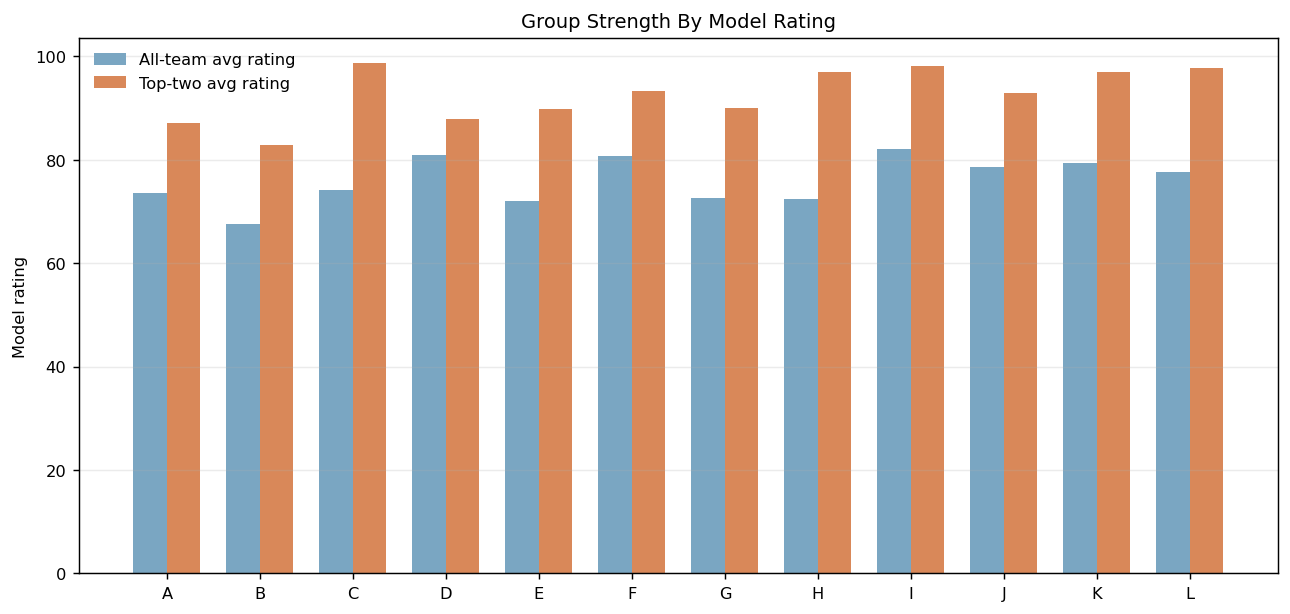

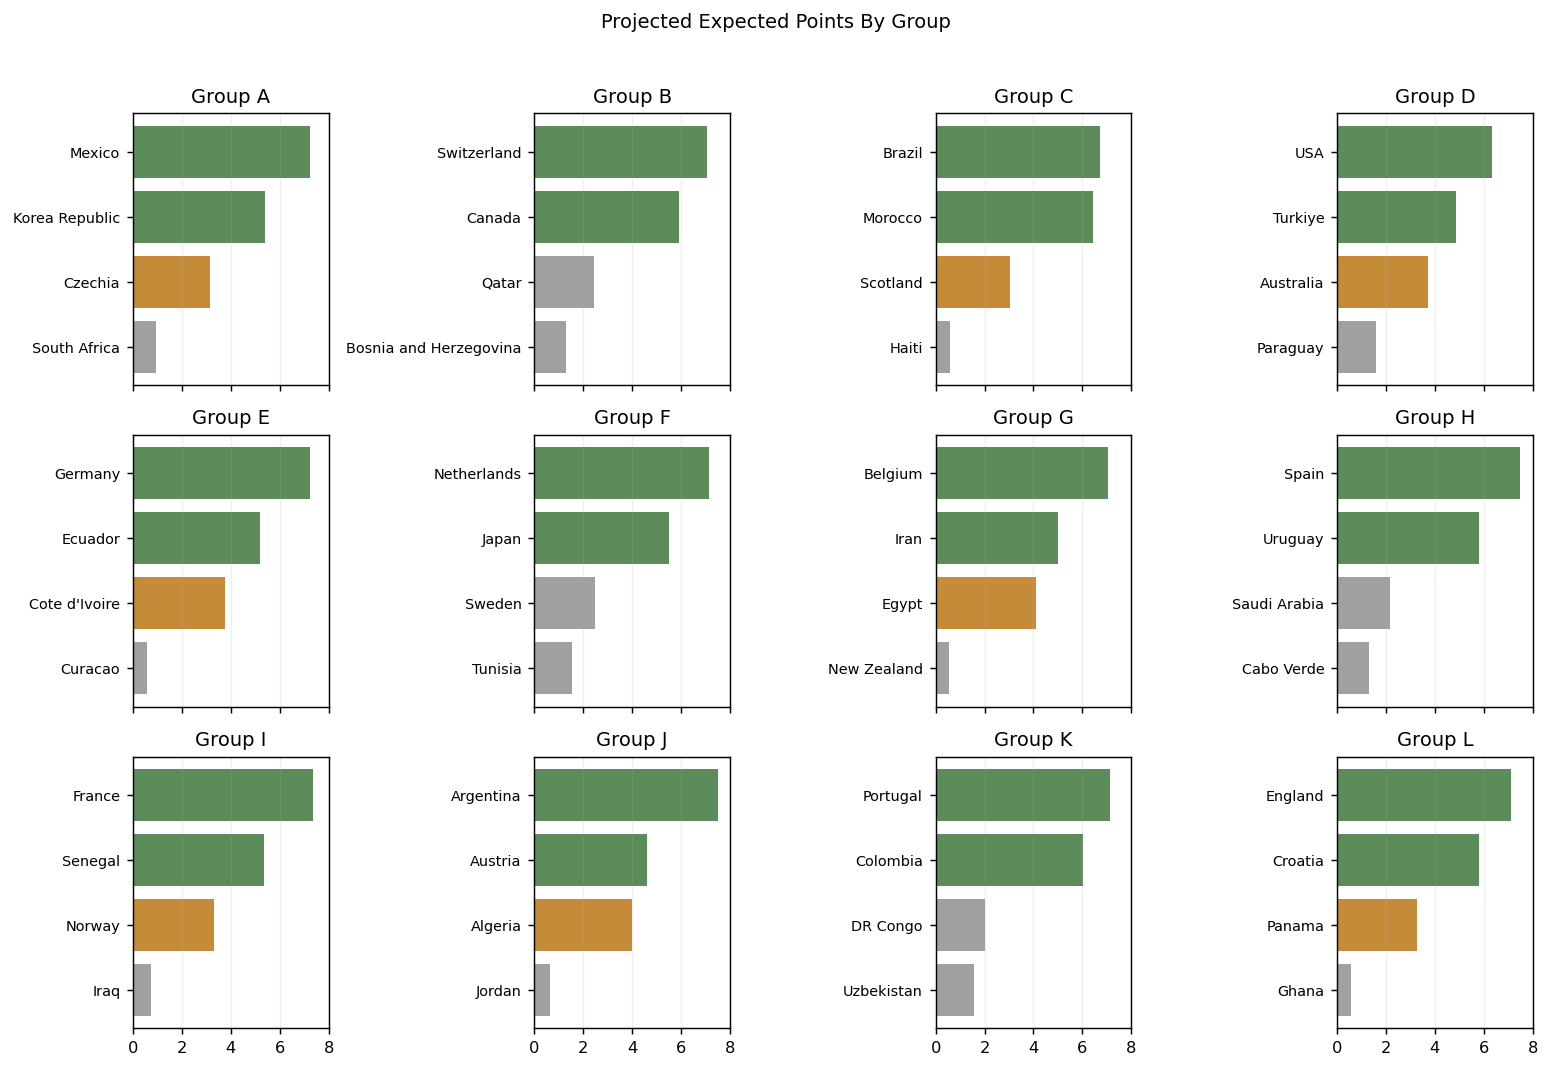

In [6]:
# Group strength visualizations.
group_strength = teams.groupby("group").agg(
    avg_rating=("rating", "mean"),
    top_two_avg=("rating", lambda s: s.sort_values(ascending=False).head(2).mean()),
    max_rating=("rating", "max")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(group_strength))
ax.bar(x - 0.18, group_strength["avg_rating"], width=0.36, label="All-team avg rating", color="#7aa6c2")
ax.bar(x + 0.18, group_strength["top_two_avg"], width=0.36, label="Top-two avg rating", color="#d98859")
ax.set_xticks(x)
ax.set_xticklabels(group_strength["group"])
ax.set_ylabel("Model rating")
ax.set_title("Group Strength By Model Rating")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharex=True)
axes = axes.ravel()
for ax, (group, sub) in zip(axes, standings.groupby("group")):
    sub = sub.sort_values("xpts")
    colors = ["#5b8c5a" if pos <= 2 else "#c58b39" if team in set(best_thirds["team"]) else "#a0a0a0" for pos, team in zip(sub["group_position"], sub["team"])]
    ax.barh(sub["team"], sub["xpts"], color=colors)
    ax.set_title(f"Group {group}")
    ax.set_xlim(0, 8)
    ax.grid(axis="x", alpha=0.2)
for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Projected Expected Points By Group", y=1.02)
plt.tight_layout()
plt.show()

## Key Players In The Predicted Advancing Pool

This joins the advancing teams to the key-player notes so it is easy to inspect which star players are driving the qualitative form modifiers.

In [7]:
advancing_pool = pd.concat([auto_qualifiers, best_thirds], ignore_index=True)
advancing_pool = advancing_pool.merge(key_players, on="team", how="left")
advancing_pool = advancing_pool.merge(teams[["team", "form_modifier", "form_note"]], on="team", how="left")
advancing_pool[["group", "group_position", "team", "fifa_rank", "rating", "xpts", "key_players", "form_modifier", "form_note"]].sort_values(["group", "group_position"]).round(2)

,group,group_position,team,fifa_rank,rating,xpts,key_players,form_modifier,form_note
0,A,1,Mexico,15,93.2,7.22,Santiago Gimenez; Edson Alvarez; Hirving Lozano,1.0,Host lift; strong home-continent conditions; Gimenez/Alvarez/Lozano core gives balance.
1,A,2,Korea Republic,25,81.2,5.39,Son Heung-min; Kim Min-jae; Lee Kang-in,0.6,Son and Kim Min-jae keep the floor high; tournament experience helps.
30,A,3,Czechia,41,67.7,3.14,Patrik Schick; Tomas Soucek; Adam Hlozek,0.3,Schick and Soucek profile well for tight games and set pieces.
2,B,1,Switzerland,19,86.8,7.06,Granit Xhaka; Manuel Akanji; Breel Embolo,0.8,Xhaka/Akanji spine and reliable tournament structure.
3,B,2,Canada,30,79.1,5.92,Alphonso Davies; Jonathan David; Tajon Buchanan,0.5,Host bonus plus Davies/David transition threat; consistency is the swing factor.
4,C,1,Brazil,6,99.7,6.74,Vinicius Junior; Rodrygo; Alisson,2.5,Vinicius/Rodrygo/Alisson-level talent; elite ceiling despite recent volatility.
5,C,2,Morocco,8,97.6,6.45,Achraf Hakimi; Yassine Bounou; Brahim Diaz,2.0,Top African side by ranking; Hakimi/Bounou/Brahim Diaz quality and 2022 pedigree.
31,C,3,Scotland,43,66.1,3.04,Andy Robertson; Scott McTominay; John McGinn,0.3,Physical midfield and set-piece threat; needs points from Haiti match.
6,D,1,USA,16,91.4,6.34,Christian Pulisic; Weston McKennie; Antonee Robinson,0.0,Host boost and high athletic ceiling; attacking consistency remains the key question.
7,D,2,Turkiye,22,84.5,4.86,Hakan Calhanoglu; Arda Guler; Kenan Yildiz,1.5,Calhanoglu/Guler/Yildiz give high technical upside.


## Knockout Bracket Construction

The official 2026 format sends each group winner/runner-up plus the best eight third-place teams into a 32-team knockout bracket.

For this model, the predicted third-place qualifiers come from groups **A, C, D, E, G, I, J, L**. The Annex C row for that combination maps third-place opponents as:

```text
1A vs 3E, 1B vs 3G, 1D vs 3J, 1E vs 3C,
1G vs 3A, 1I vs 3D, 1K vs 3L, 1L vs 3I
```

The fixed runner-up matchups are then added from the official bracket template.

In [8]:
# Build lookup dictionaries for group winners, runners-up, and third-place qualifiers.
winners = standings[standings["group_position"] == 1].set_index("group")["team"].to_dict()
runners_up = standings[standings["group_position"] == 2].set_index("group")["team"].to_dict()
third_qualifiers = best_thirds.set_index("group")["team"].to_dict()
third_groups = " ".join(sorted(third_qualifiers))
third_groups

'A C D E G I J L'

In [9]:
# Annex C row used by this scenario: A C D E G I J L.
third_mapping_for_group_winners = {
    "A": "E",
    "B": "G",
    "D": "J",
    "E": "C",
    "G": "A",
    "I": "D",
    "K": "L",
    "L": "I",
}

r32_pairs = OrderedDict([
    (73, (runners_up["A"], runners_up["B"], "2A vs 2B")),
    (74, (winners["E"], third_qualifiers[third_mapping_for_group_winners["E"]], "1E vs 3C")),
    (75, (winners["F"], runners_up["C"], "1F vs 2C")),
    (76, (winners["C"], runners_up["F"], "1C vs 2F")),
    (77, (winners["I"], third_qualifiers[third_mapping_for_group_winners["I"]], "1I vs 3D")),
    (78, (runners_up["E"], runners_up["I"], "2E vs 2I")),
    (79, (winners["A"], third_qualifiers[third_mapping_for_group_winners["A"]], "1A vs 3E")),
    (80, (winners["L"], third_qualifiers[third_mapping_for_group_winners["L"]], "1L vs 3I")),
    (81, (winners["D"], third_qualifiers[third_mapping_for_group_winners["D"]], "1D vs 3J")),
    (82, (winners["G"], third_qualifiers[third_mapping_for_group_winners["G"]], "1G vs 3A")),
    (83, (runners_up["K"], runners_up["L"], "2K vs 2L")),
    (84, (winners["H"], runners_up["J"], "1H vs 2J")),
    (85, (winners["B"], third_qualifiers[third_mapping_for_group_winners["B"]], "1B vs 3G")),
    (86, (winners["J"], runners_up["H"], "1J vs 2H")),
    (87, (winners["K"], third_qualifiers[third_mapping_for_group_winners["K"]], "1K vs 3L")),
    (88, (runners_up["D"], runners_up["G"], "2D vs 2G")),
])

ratings = teams.set_index("team")["rating"].to_dict()

def knockout_win_probability(team_a, team_b):
    return logistic((ratings[team_a] - ratings[team_b]) / 8)


def knockout_result(match, round_name, team_a, team_b, slot):
    p_a = knockout_win_probability(team_a, team_b)
    winner = team_a if p_a >= 0.5 else team_b
    loser = team_b if winner == team_a else team_a
    return {
        "match": match,
        "round": round_name,
        "slot": slot,
        "team_a": team_a,
        "team_b": team_b,
        "win_prob_team_a": p_a,
        "winner": winner,
        "loser": loser,
        "winner_probability": max(p_a, 1 - p_a),
    }

knockout = {}
for match, (a, b, slot) in r32_pairs.items():
    knockout[match] = knockout_result(match, "Round of 32", a, b, slot)

def W(match):
    return knockout[match]["winner"]

r16_pairs = OrderedDict([
    (89, (W(74), W(77), "W74 vs W77")),
    (90, (W(73), W(75), "W73 vs W75")),
    (91, (W(76), W(78), "W76 vs W78")),
    (92, (W(79), W(80), "W79 vs W80")),
    (93, (W(83), W(84), "W83 vs W84")),
    (94, (W(81), W(82), "W81 vs W82")),
    (95, (W(86), W(88), "W86 vs W88")),
    (96, (W(85), W(87), "W85 vs W87")),
])
for match, (a, b, slot) in r16_pairs.items():
    knockout[match] = knockout_result(match, "Round of 16", a, b, slot)

qf_pairs = OrderedDict([
    (97, (W(89), W(90), "W89 vs W90")),
    (98, (W(93), W(94), "W93 vs W94")),
    (99, (W(91), W(92), "W91 vs W92")),
    (100, (W(95), W(96), "W95 vs W96")),
])
for match, (a, b, slot) in qf_pairs.items():
    knockout[match] = knockout_result(match, "Quarterfinal", a, b, slot)

sf_pairs = OrderedDict([
    (101, (W(97), W(98), "W97 vs W98")),
    (102, (W(99), W(100), "W99 vs W100")),
])
for match, (a, b, slot) in sf_pairs.items():
    knockout[match] = knockout_result(match, "Semifinal", a, b, slot)

knockout[103] = knockout_result(103, "Third-place Match", knockout[101]["loser"], knockout[102]["loser"], "L101 vs L102")
knockout[104] = knockout_result(104, "Final", W(101), W(102), "W101 vs W102")

knockout_table = pd.DataFrame(knockout.values()).sort_values("match")
knockout_table["win_prob_team_a"] = knockout_table["win_prob_team_a"].round(3)
knockout_table["winner_probability"] = knockout_table["winner_probability"].round(3)
knockout_table

,match,round,slot,team_a,team_b,win_prob_team_a,winner,loser,winner_probability
0,73,Round of 32,2A vs 2B,Korea Republic,Canada,0.565,Korea Republic,Canada,0.565
1,74,Round of 32,1E vs 3C,Germany,Scotland,0.978,Germany,Scotland,0.978
2,75,Round of 32,1F vs 2C,Netherlands,Morocco,0.525,Netherlands,Morocco,0.525
3,76,Round of 32,1C vs 2F,Brazil,Japan,0.806,Brazil,Japan,0.806
4,77,Round of 32,1I vs 3D,France,Australia,0.962,France,Australia,0.962
5,78,Round of 32,2E vs 2I,Ecuador,Senegal,0.274,Senegal,Ecuador,0.726
6,79,Round of 32,1A vs 3E,Mexico,Cote d'Ivoire,0.917,Mexico,Cote d'Ivoire,0.917
7,80,Round of 32,1L vs 3I,England,Norway,0.957,England,Norway,0.957
8,81,Round of 32,1D vs 3J,USA,Algeria,0.825,USA,Algeria,0.825
9,82,Round of 32,1G vs 3A,Belgium,Czechia,0.973,Belgium,Czechia,0.973


In [10]:
# Compact round-by-round result view.
result_view = knockout_table[["round", "match", "slot", "team_a", "team_b", "winner", "winner_probability"]].copy()
result_view["winner_probability"] = (100 * result_view["winner_probability"]).round(1).astype(str) + "%"
for round_name in ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Third-place Match", "Final"]:
    print(f"\n{round_name}")
    display(result_view[result_view["round"] == round_name])


Round of 32


,round,match,slot,team_a,team_b,winner,winner_probability
0,Round of 32,73,2A vs 2B,Korea Republic,Canada,Korea Republic,56.5%
1,Round of 32,74,1E vs 3C,Germany,Scotland,Germany,97.8%
2,Round of 32,75,1F vs 2C,Netherlands,Morocco,Netherlands,52.5%
3,Round of 32,76,1C vs 2F,Brazil,Japan,Brazil,80.6%
4,Round of 32,77,1I vs 3D,France,Australia,France,96.2%
5,Round of 32,78,2E vs 2I,Ecuador,Senegal,Senegal,72.6%
6,Round of 32,79,1A vs 3E,Mexico,Cote d'Ivoire,Mexico,91.7%
7,Round of 32,80,1L vs 3I,England,Norway,England,95.7%
8,Round of 32,81,1D vs 3J,USA,Algeria,USA,82.5%
9,Round of 32,82,1G vs 3A,Belgium,Czechia,Belgium,97.3%



Round of 16


,round,match,slot,team_a,team_b,winner,winner_probability
16,Round of 16,89,W74 vs W77,Germany,France,France,74.8%
17,Round of 16,90,W73 vs W75,Korea Republic,Netherlands,Netherlands,89.6%
18,Round of 16,91,W76 vs W78,Brazil,Senegal,Brazil,74.8%
19,Round of 16,92,W79 vs W80,Mexico,England,England,75.7%
20,Round of 16,93,W83 vs W84,Croatia,Spain,Spain,79.8%
21,Round of 16,94,W81 vs W82,USA,Belgium,Belgium,64.9%
22,Round of 16,95,W86 vs W88,Argentina,Turkiye,Argentina,91.1%
23,Round of 16,96,W85 vs W87,Switzerland,Portugal,Portugal,85.5%



Quarterfinal


...

,round,match,slot,team_a,team_b,winner,winner_probability
28,Semifinal,101,W97 vs W98,France,Spain,France,52.5%
29,Semifinal,102,W99 vs W100,England,Argentina,Argentina,52.5%



Third-place Match


,round,match,slot,team_a,team_b,winner,winner_probability
30,Third-place Match,103,L101 vs L102,Spain,England,Spain,56.5%



Final


,round,match,slot,team_a,team_b,winner,winner_probability
31,Final,104,W101 vs W102,France,Argentina,France,56.5%


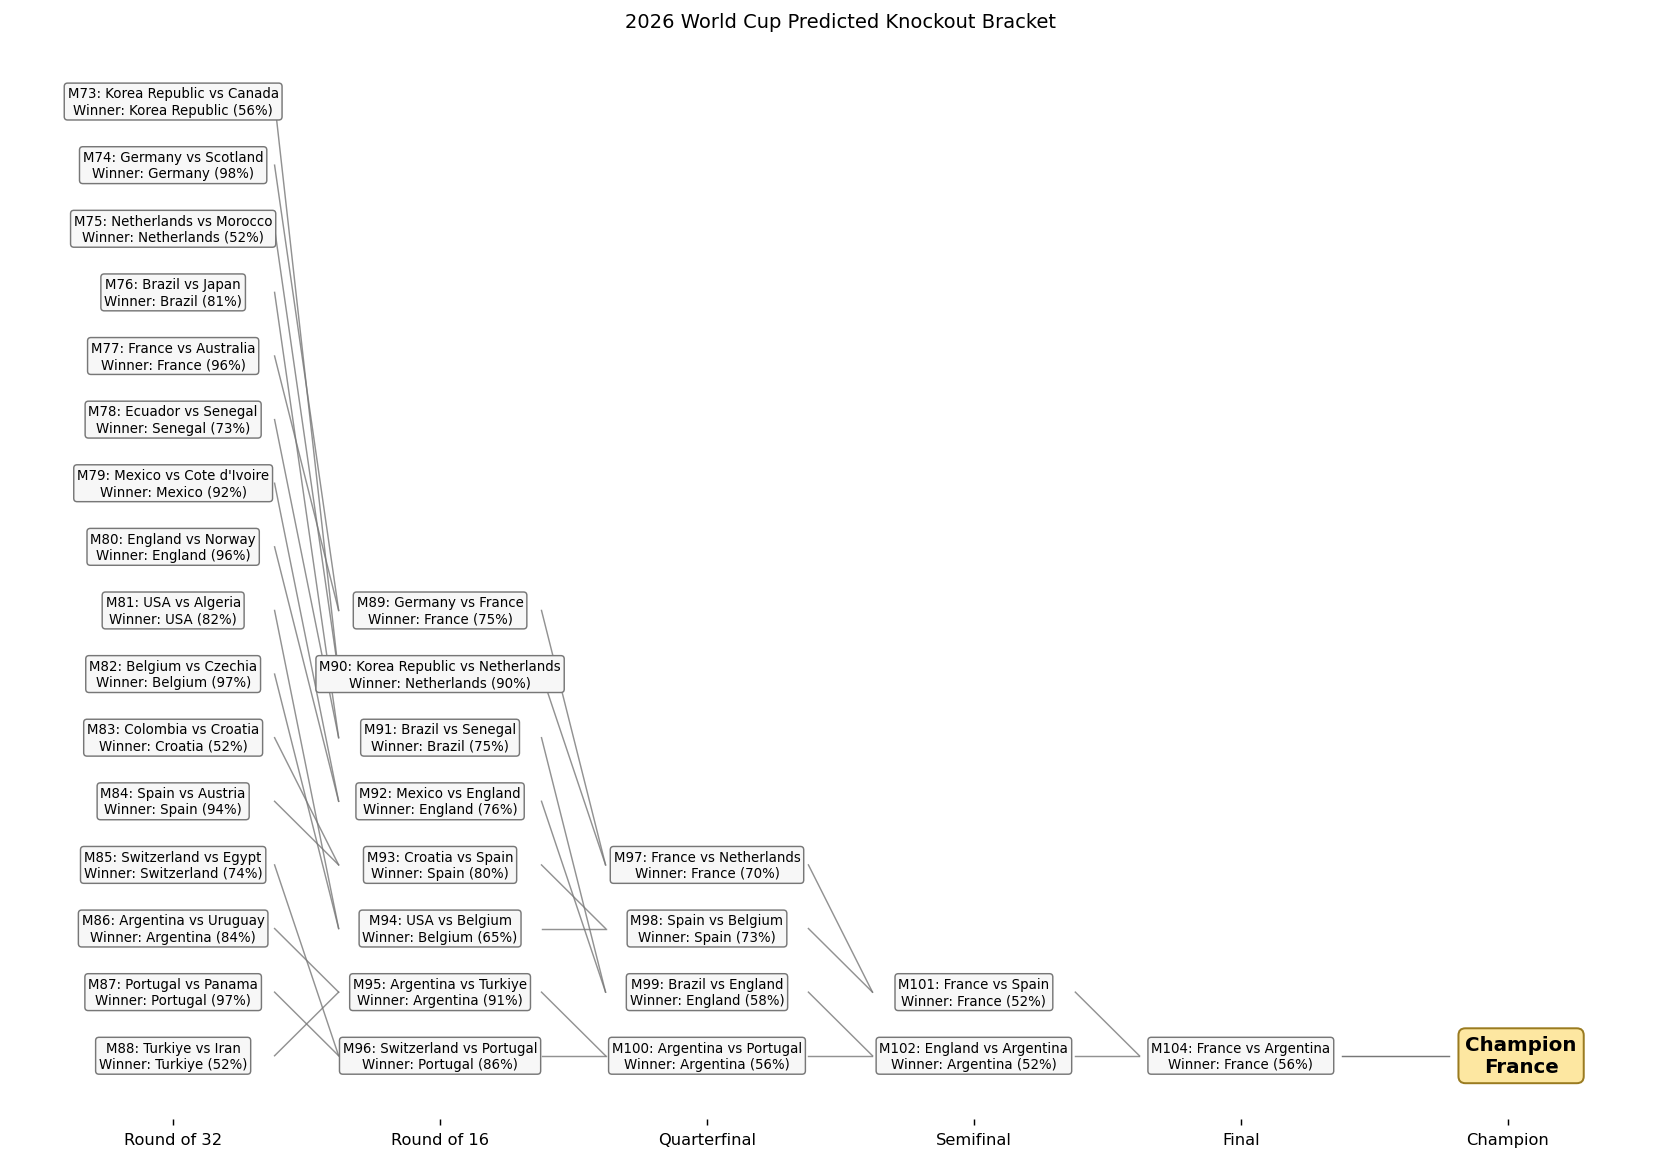

In [11]:
# Bracket visualization. This lays out the deterministic path match-by-match.
round_order = ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Final"]
round_x = {name: i for i, name in enumerate(round_order)}

# Fixed y-order follows the official match order in each round.
y_positions = {}
for round_name in round_order:
    matches = knockout_table[knockout_table["round"] == round_name]["match"].tolist()
    n = len(matches)
    for i, match in enumerate(matches):
        y_positions[match] = n - i

# Parent links for bracket tree.
parents = {
    89: [74, 77], 90: [73, 75], 91: [76, 78], 92: [79, 80],
    93: [83, 84], 94: [81, 82], 95: [86, 88], 96: [85, 87],
    97: [89, 90], 98: [93, 94], 99: [91, 92], 100: [95, 96],
    101: [97, 98], 102: [99, 100],
    104: [101, 102],
}

fig, ax = plt.subplots(figsize=(13, 9))
for _, row in knockout_table[knockout_table["round"].isin(round_order)].iterrows():
    x = round_x[row["round"]]
    y = y_positions[row["match"]]
    label = f"M{int(row['match'])}: {row['team_a']} vs {row['team_b']}\nWinner: {row['winner']} ({row['winner_probability']*100:.0f}%)"
    ax.text(x, y, label, ha="center", va="center", fontsize=7.4,
            bbox=dict(boxstyle="round,pad=0.25", fc="#f7f7f7", ec="#777777", lw=0.8))

for child, parent_matches in parents.items():
    child_row = knockout[child]
    child_x = round_x[child_row["round"]]
    child_y = y_positions[child]
    for parent in parent_matches:
        parent_row = knockout[parent]
        parent_x = round_x[parent_row["round"]]
        parent_y = y_positions[parent]
        ax.plot([parent_x + 0.38, child_x - 0.38], [parent_y, child_y], color="#777777", lw=0.8, alpha=0.8)

champion = knockout[104]["winner"]
ax.text(5.05, y_positions[104], f"Champion\n{champion}", ha="center", va="center", fontsize=11, weight="bold",
        bbox=dict(boxstyle="round,pad=0.35", fc="#fde7a1", ec="#9a7b20", lw=1.1))
ax.plot([4.38, 4.78], [y_positions[104], y_positions[104]], color="#777777", lw=0.8)

ax.set_xlim(-0.6, 5.6)
ax.set_ylim(0, 17)
ax.set_xticks(list(round_x.values()) + [5])
ax.set_xticklabels(round_order + ["Champion"])
ax.set_yticks([])
ax.set_title("2026 World Cup Predicted Knockout Bracket")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## Headline Prediction

Based on this model:

- **Champion:** France
- **Runner-up:** Argentina
- **Third place:** Spain
- **Fourth place:** England
- **Semifinals:** France over Spain; Argentina over England
- **Final:** France over Argentina

The tightest elite calls are France vs Spain and England vs Argentina. The model only slightly prefers France and Argentina there because the top national teams are clustered very closely in the April 2026 ranking and because a small player availability change could flip those fixtures.

In [12]:
summary = pd.DataFrame([
    {"result": "Champion", "team": knockout[104]["winner"]},
    {"result": "Runner-up", "team": knockout[104]["loser"]},
    {"result": "Third place", "team": knockout[103]["winner"]},
    {"result": "Fourth place", "team": knockout[103]["loser"]},
])
summary

,result,team
0,Champion,France
1,Runner-up,Argentina
2,Third place,Spain
3,Fourth place,England


## Sensitivity Notes

The most important uncertainty factors to revisit before the tournament starts:

1. **Final squads and injuries:** Rodri, Messi, Ronaldo, Mbappe, Kane, Haaland, Vinicius, and other star availability would noticeably move probabilities.
2. **June 2026 FIFA ranking update:** FIFA's next update is scheduled shortly before the tournament; the top-five order and mid-table ranks can change after late friendlies.
3. **Third-place volatility:** The eight best third-place teams are the hardest bracket input to predict. Small group-stage score swings can change the Annex C mapping and therefore alter the entire knockout route.
4. **Venue/travel/heat:** Host-continent travel and summer conditions likely help Mexico/USA/Canada more than the base rating captures.
5. **Player-form modifiers:** These are transparent subjective inputs. Updating them after late-season club finals and friendlies is the easiest way to refresh the notebook.

<!-- LIVE_UPDATE_20260617_START -->

## Live Update - July 12, 2026

This section reruns the projection using match results available to me on **July 12, 2026 at about 3:20 p.m. ET**. It preserves the original preseason model above, then applies five live inputs:

1. **June 2026 FIFA rankings** from the current group pages.
2. **Played World Cup matches** locked in as actual results.
3. **Player/match form signals** led by direct SofaScore ratings, minutes, and match statistics.
4. **Human-read tactical notes** supplied by the analyst, blended separately from the raw rating model.
5. **Current prediction-market diagnostics** from July 12 Polymarket and Kalshi outright, final-qualifier, and match-advance markets.

Sources checked for this update:

- SB Nation's current Round of 32 schedule/scores tracker, updated July 2, for completed knockout results and still-upcoming fixtures.
- Guardian match reports and live reports for France-Senegal, Iraq-Norway, Norway-Senegal, France-Iraq, Argentina-Algeria, Argentina-Austria, Portugal-DR Congo, Portugal-Uzbekistan, Colombia-DR Congo, England-Ghana, Panama-Croatia, Austria-Jordan, USA-Australia, Belgium-Iran, Japan-Tunisia, Spain-Saudi Arabia, South Africa-South Korea, Mexico-Czechia, Switzerland-Canada, Morocco-Haiti, Brazil-Scotland, Ecuador-Germany, Cote d'Ivoire-Curacao, Netherlands-Tunisia, Japan-Sweden, France-Norway, Senegal-Iraq, Spain-Uruguay, Cabo Verde-Saudi Arabia, Belgium-New Zealand, and Egypt-Iran.
- Guardian and other match reports/live blogs for Canada-South Africa, Germany-Paraguay, Netherlands-Morocco, Brazil-Japan, France-Sweden, Cote d'Ivoire-Norway, Mexico-Ecuador, England-DR Congo, England-Panama, Colombia-Portugal, DR Congo-Uzbekistan, Argentina-Jordan, Algeria-Austria, and Croatia-Ghana.
- Guardian player ratings for England 4-2 Croatia and England 0-0 Ghana.
- SB Nation/Guardian/other live reports for the completed Round of 16: Morocco-Canada, France-Paraguay, Norway-Brazil, England-Mexico, Spain-Portugal, Belgium-USA, Argentina-Egypt, and Switzerland-Colombia.
- AP, FIFA, Guardian, Opta, and other match reports for the completed quarterfinals: France 2-0 Morocco, Spain 2-1 Belgium, England 2-1 Norway after extra time, and Argentina 3-1 Switzerland after extra time.
- Direct SofaScore event endpoints for all 100 completed matches: lineups/player ratings, minutes, goals, assists, team statistics, and shot maps.
- Polymarket public Gamma API and Kalshi public market snapshots fetched on July 12 for the four semifinalists. Both venues expose complete current outright and final-qualifier rows; Kalshi also exposes complete two-team advance markets for both semifinals.
- The 2026 third-place mapping table; the updated model's actual third-place set is **B, D, E, F, I, J, K, L**, which maps as:

```text
1A vs 3E, 1B vs 3J, 1D vs 3B, 1E vs 3D,
1G vs 3I, 1I vs 3F, 1K vs 3L, 1L vs 3K
```

Human-read notes incorporated in this run:

- Harry Kane: comprehensive striker play plus decisive clutch goals against DR Congo materially lift England's late-game ceiling.
- Mexico: team cohesion, vertical running, passing, dribbling progression, and home momentum are stronger than the base model previously credited, even without a single global superstar.
- Portugal: team chance creation remains poor; Ronaldo's Uzbekistan brace is discounted as opponent/error-driven rather than proof of elite current impact, and his low-pressing/low-mobility role remains a drag.
- Belgium: the Senegal win is treated as survival in a very even game rather than a dominant signal; Belgium's psychological edge/title ferocity is downgraded, and Lukaku is treated as more useful from the bench than as a starter.
- USA: the team is upgraded for tenacity, physicality, technique, and on-field coordination, with a specific note that its collective quality looks better than player market values imply.
- France: Paraguay showed France's next-level ceiling: tenacity plus attacking talent, even in a low-score knockout.
- Argentina: Cape Verde and Egypt showed real tenacity, but the Messi-dependence and reduced running/creativity from supporting players remain worrying.
- Argentina vs Switzerland: the defense remains vulnerable and Emiliano Martinez no longer looks as dominant as in 2022, while Messi looked fatigued after repeated long matches. Offsetting that, Lisandro Martinez supplied high-value interventions, Thiago Almada added useful width, Jose Manuel Lopez created separation and linked the extra-time winner, and the full squad again showed elite tenacity and tactical depth.
- England: Mexico showed collaboration, attacking talent, and impressive 10-man defensive resilience.
- Spain: still high-performing structurally, but chance creation and finishing are not ruthless; Lamine Yamal and the midfield did not generate enough, and Oyarzabal is not a traditional No. 9.
- Switzerland: Colombia showed excellent defensive quality, while open-play attacking output remains a concern.
- Norway: Brazil showed a scary transition path: not elite in passing/dribbling overall, but Odegaard/Nusa/Haaland can punish the thinnest window.

Player-rating policy: direct SofaScore rows are the primary quantitative form source. For R32 and later, the model computes each team's match rating as a minutes-weighted average of rated players, then applies a stage-recency weight. Google lineup ratings are retained only as a per-match fallback when a SofaScore match is unavailable. Human observations remain a separate, visible layer and never masquerade as scraped ratings.

July 12 note: this update locks all results through **Argentina 3-1 Switzerland after extra time in Match 100**. The semifinal pairings are now France-Spain (M101) and England-Argentina (M102).

In [13]:
# Live data and modelling utilities for the July 12 update.
import math
import itertools
import json
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 140)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
GOOGLE_DATA_DIR = DATA_DIR / "google"
SOFASCORE_DATA_DIR = DATA_DIR / "sofascore"
MARKET_DATA_DIR = DATA_DIR / "markets"

def logistic(x):
    return 1 / (1 + math.exp(-x))

def _safe_logit(p):
    p = min(max(float(p), 0.001), 0.999)
    return math.log(p / (1 - p))

def depth_modifier(rank):
    if rank <= 10:
        return 2.0
    if rank <= 20:
        return 1.2
    if rank <= 30:
        return 0.6
    if rank <= 45:
        return 0.2
    return 0.0

def group_match_probabilities(rating_a, rating_b):
    diff = rating_a - rating_b
    draw = max(0.18, min(0.30, 0.30 - abs(diff) * 0.004))
    p_a_non_draw = logistic(diff / 8)
    p_a_win = (1 - draw) * p_a_non_draw
    p_b_win = (1 - draw) * (1 - p_a_non_draw)
    return p_a_win, draw, p_b_win

teams_live_data = [
    # group, team, June 2026 FIFA rank, host bonus, base/pre-tournament form modifier
    ("A", "Mexico", 14, 3, 1.0), ("A", "South Africa", 60, 0, 0.0), ("A", "Korea Republic", 25, 0, 0.6), ("A", "Czechia", 40, 0, 0.3),
    ("B", "Canada", 30, 2, 0.5), ("B", "Bosnia and Herzegovina", 64, 0, 0.2), ("B", "Qatar", 56, 0, 0.0), ("B", "Switzerland", 19, 0, 0.8),
    ("C", "Brazil", 6, 0, 2.5), ("C", "Morocco", 7, 0, 2.0), ("C", "Haiti", 83, 0, 0.0), ("C", "Scotland", 42, 0, 0.3),
    ("D", "USA", 16, 3, 0.0), ("D", "Paraguay", 41, 0, 0.5), ("D", "Australia", 27, 0, 0.4), ("D", "Turkiye", 22, 0, 1.5),
    ("E", "Germany", 10, 0, 2.5), ("E", "Curacao", 82, 0, 0.0), ("E", "Cote d'Ivoire", 33, 0, 1.0), ("E", "Ecuador", 23, 0, 1.0),
    ("F", "Netherlands", 8, 0, 2.0), ("F", "Japan", 18, 0, 1.5), ("F", "Sweden", 38, 0, 1.2), ("F", "Tunisia", 45, 0, 0.1),
    ("G", "Belgium", 9, 0, 1.5), ("G", "Egypt", 29, 0, 1.0), ("G", "Iran", 20, 0, 0.1), ("G", "New Zealand", 85, 0, 0.0),
    ("H", "Spain", 2, 0, 4.0), ("H", "Cabo Verde", 67, 0, 0.0), ("H", "Saudi Arabia", 61, 0, 0.0), ("H", "Uruguay", 16, 0, 2.0),
    ("I", "France", 3, 0, 4.0), ("I", "Senegal", 15, 0, 1.0), ("I", "Iraq", 57, 0, 0.2), ("I", "Norway", 31, 0, 2.0),
    ("J", "Argentina", 1, 0, 3.5), ("J", "Algeria", 28, 0, 0.8), ("J", "Austria", 24, 0, 1.5), ("J", "Jordan", 63, 0, 0.0),
    ("K", "Portugal", 5, 0, 3.0), ("K", "DR Congo", 46, 0, 0.2), ("K", "Uzbekistan", 50, 0, 0.1), ("K", "Colombia", 13, 0, 2.0),
    ("L", "England", 4, 0, 3.5), ("L", "Croatia", 11, 0, 1.0), ("L", "Ghana", 73, 0, 0.2), ("L", "Panama", 34, 0, 0.2),
]

teams_live = pd.DataFrame(teams_live_data, columns=["group", "team", "fifa_rank_june", "host_bonus", "base_form_modifier"])
teams_live["depth_modifier"] = teams_live["fifa_rank_june"].map(depth_modifier)
teams_live["base_rating_june"] = (
    100
    - 0.8 * teams_live["fifa_rank_june"]
    + teams_live["host_bonus"]
    + teams_live["base_form_modifier"]
    + teams_live["depth_modifier"]
)

played_results_data = [
    ("A", "Mexico", "South Africa", 2, 0, "2026-06-11"),
    ("A", "Korea Republic", "Czechia", 2, 1, "2026-06-11"),
    ("B", "Canada", "Bosnia and Herzegovina", 1, 1, "2026-06-12"),
    ("B", "Qatar", "Switzerland", 1, 1, "2026-06-13"),
    ("C", "Brazil", "Morocco", 1, 1, "2026-06-13"),
    ("C", "Haiti", "Scotland", 0, 1, "2026-06-13"),
    ("D", "USA", "Paraguay", 4, 1, "2026-06-12"),
    ("D", "Australia", "Turkiye", 2, 0, "2026-06-13"),
    ("E", "Germany", "Curacao", 7, 1, "2026-06-14"),
    ("E", "Cote d'Ivoire", "Ecuador", 1, 0, "2026-06-14"),
    ("F", "Netherlands", "Japan", 2, 2, "2026-06-14"),
    ("F", "Sweden", "Tunisia", 5, 1, "2026-06-14"),
    ("G", "Belgium", "Egypt", 1, 1, "2026-06-15"),
    ("G", "Iran", "New Zealand", 2, 2, "2026-06-15"),
    ("H", "Spain", "Cabo Verde", 0, 0, "2026-06-15"),
    ("H", "Saudi Arabia", "Uruguay", 1, 1, "2026-06-15"),
    ("I", "France", "Senegal", 3, 1, "2026-06-16"),
    ("I", "Iraq", "Norway", 1, 4, "2026-06-16"),
    ("J", "Argentina", "Algeria", 3, 0, "2026-06-16"),
    ("J", "Austria", "Jordan", 3, 1, "2026-06-17"),
    ("K", "Portugal", "DR Congo", 1, 1, "2026-06-17"),
    ("K", "Colombia", "Uzbekistan", 3, 1, "2026-06-17"),
    ("K", "Portugal", "Uzbekistan", 5, 0, "2026-06-23"),
    ("K", "Colombia", "DR Congo", 1, 0, "2026-06-23"),
    ("L", "England", "Croatia", 4, 2, "2026-06-17"),
    ("L", "Ghana", "Panama", 1, 0, "2026-06-17"),
    ("L", "England", "Ghana", 0, 0, "2026-06-23"),
    ("L", "Panama", "Croatia", 0, 1, "2026-06-23"),
    ("A", "Czechia", "South Africa", 1, 1, "2026-06-18"),
    ("A", "Mexico", "Korea Republic", 1, 0, "2026-06-18"),
    ("B", "Switzerland", "Bosnia and Herzegovina", 4, 1, "2026-06-18"),
    ("B", "Canada", "Qatar", 6, 0, "2026-06-18"),
    ("C", "Morocco", "Scotland", 1, 0, "2026-06-19"),
    ("C", "Brazil", "Haiti", 3, 0, "2026-06-19"),
    ("D", "USA", "Australia", 2, 0, "2026-06-19"),
    ("D", "Paraguay", "Turkiye", 1, 0, "2026-06-19"),
    ("E", "Germany", "Cote d'Ivoire", 2, 1, "2026-06-20"),
    ("E", "Ecuador", "Curacao", 0, 0, "2026-06-20"),
    ("F", "Netherlands", "Sweden", 5, 1, "2026-06-20"),
    ("F", "Tunisia", "Japan", 0, 4, "2026-06-21"),
    ("G", "Belgium", "Iran", 0, 0, "2026-06-21"),
    ("H", "Spain", "Saudi Arabia", 4, 0, "2026-06-21"),
    ("H", "Uruguay", "Cabo Verde", 2, 2, "2026-06-21"),
    ("I", "Norway", "Senegal", 3, 2, "2026-06-22"),
    ("G", "New Zealand", "Egypt", 1, 3, "2026-06-21"),
    ("I", "France", "Iraq", 3, 0, "2026-06-22"),
    ("J", "Argentina", "Austria", 2, 0, "2026-06-22"),
    ("J", "Jordan", "Algeria", 1, 2, "2026-06-22"),
    ("B", "Switzerland", "Canada", 2, 1, "2026-06-24"),
    ("B", "Bosnia and Herzegovina", "Qatar", 3, 1, "2026-06-24"),
    ("C", "Morocco", "Haiti", 4, 2, "2026-06-24"),
    ("C", "Brazil", "Scotland", 3, 0, "2026-06-24"),
    ("A", "South Africa", "Korea Republic", 1, 0, "2026-06-24"),
    ("A", "Mexico", "Czechia", 3, 0, "2026-06-24"),
    ("E", "Cote d'Ivoire", "Curacao", 2, 0, "2026-06-25"),
    ("E", "Ecuador", "Germany", 2, 1, "2026-06-25"),
    ("F", "Netherlands", "Tunisia", 3, 1, "2026-06-25"),
    ("F", "Japan", "Sweden", 1, 1, "2026-06-25"),
    ("D", "Turkiye", "USA", 3, 2, "2026-06-25"),
    ("D", "Paraguay", "Australia", 0, 0, "2026-06-25"),
    ("I", "France", "Norway", 4, 1, "2026-06-26"),
    ("I", "Senegal", "Iraq", 5, 0, "2026-06-26"),
    ("H", "Cabo Verde", "Saudi Arabia", 0, 0, "2026-06-26"),
    ("H", "Spain", "Uruguay", 1, 0, "2026-06-26"),
    ("G", "Belgium", "New Zealand", 5, 1, "2026-06-26"),
    ("G", "Egypt", "Iran", 1, 1, "2026-06-26"),
    ("J", "Algeria", "Austria", 3, 3, "2026-06-27"),
    ("J", "Jordan", "Argentina", 1, 3, "2026-06-27"),
    ("K", "Colombia", "Portugal", 0, 0, "2026-06-27"),
    ("K", "DR Congo", "Uzbekistan", 3, 1, "2026-06-27"),
    ("L", "Panama", "England", 0, 2, "2026-06-27"),
    ("L", "Croatia", "Ghana", 2, 1, "2026-06-27"),
]
played_results = pd.DataFrame(played_results_data, columns=["group", "team_a", "team_b", "goals_a", "goals_b", "date"])

# Market snapshot initially fetched from public Kalshi markets on 2026-06-23.
# The old group-stage Kalshi rows are now historical diagnostics because all group-stage matches are locked.
# The July 12 cross-venue snapshot is parsed later and lightly applied to the four semifinalists.
market_weight_default = 0.10
market_group_priors_data = [
    # team_a, team_b, market_outcome, market_prob, market_weight, source, ticker, quality_note
    ("England", "Ghana", "England", 0.83, market_weight_default, "Kalshi", "KXWCGAME-26JUN23ENGGHA-ENG", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Portugal", "Uzbekistan", "Portugal", 0.86, market_weight_default, "Kalshi", "KXWCGAME-26JUN23PORUZB-POR", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Portugal", "Uzbekistan", "Draw", 0.11, market_weight_default, "Kalshi", "KXWCGAME-26JUN23PORUZB-TIE", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Colombia", "DR Congo", "Colombia", 0.64, market_weight_default, "Kalshi", "KXWCGAME-26JUN23COLCOD-COL", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Panama", "Croatia", "Croatia", 0.67, market_weight_default, "Kalshi", "KXWCGAME-26JUN23PANCRO-CRO", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Panama", "Croatia", "Panama", 0.13, market_weight_default, "Kalshi", "KXWCGAME-26JUN23PANCRO-PAN", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Panama", "Croatia", "Draw", 0.24, market_weight_default, "Kalshi", "KXWCGAME-26JUN23PANCRO-TIE", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Czechia", "Mexico", "Mexico", 0.52, market_weight_default, "Kalshi", "KXWCGAME-26JUN24CZEMEX-MEX", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Switzerland", "Canada", "Canada", 0.29, market_weight_default, "Kalshi", "KXWCGAME-26JUN24SUICAN-CAN", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Switzerland", "Canada", "Switzerland", 0.42, market_weight_default, "Kalshi", "KXWCGAME-26JUN24SUICAN-SUI", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Morocco", "Haiti", "Morocco", 0.83, market_weight_default, "Kalshi", "KXWCGAME-26JUN24MARHTI-MAR", "last_price only; no bid/ask/liquidity in fetched response"),
    ("South Africa", "Korea Republic", "Korea Republic", 0.59, market_weight_default, "Kalshi", "KXWCGAME-26JUN24RSAKOR-KOR", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Scotland", "Brazil", "Brazil", 0.72, market_weight_default, "Kalshi", "KXWCGAME-26JUN24SCOBRA-BRA", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Bosnia and Herzegovina", "Qatar", "Bosnia and Herzegovina", 0.70, market_weight_default, "Kalshi", "KXWCGAME-26JUN24BIHQAT-BIH", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Ecuador", "Germany", "Germany", 0.53, market_weight_default, "Kalshi", "KXWCGAME-26JUN25ECUGER-GER", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Tunisia", "Netherlands", "Netherlands", 0.88, market_weight_default, "Kalshi", "KXWCGAME-26JUN25TUNNED-NED", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Turkiye", "USA", "USA", 0.52, market_weight_default, "Kalshi", "KXWCGAME-26JUN25TURUSA-USA", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Japan", "Sweden", "Japan", 0.52, market_weight_default, "Kalshi", "KXWCGAME-26JUN25JPNSWE-JPN", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Japan", "Sweden", "Sweden", 0.22, market_weight_default, "Kalshi", "KXWCGAME-26JUN25JPNSWE-SWE", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Japan", "Sweden", "Draw", 0.28, market_weight_default, "Kalshi", "KXWCGAME-26JUN25JPNSWE-TIE", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Curacao", "Cote d'Ivoire", "Cote d'Ivoire", 0.85, market_weight_default, "Kalshi", "KXWCGAME-26JUN25CUWCIV-CIV", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Paraguay", "Australia", "Paraguay", 0.33, market_weight_default, "Kalshi", "KXWCGAME-26JUN25PARAUS-PAR", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Paraguay", "Australia", "Draw", 0.44, market_weight_default, "Kalshi", "KXWCGAME-26JUN25PARAUS-TIE", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Norway", "France", "France", 0.60, market_weight_default, "Kalshi", "KXWCGAME-26JUN26NORFRA-FRA", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Senegal", "Iraq", "Senegal", 0.79, market_weight_default, "Kalshi", "KXWCGAME-26JUN26SENIRQ-SEN", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Cabo Verde", "Saudi Arabia", "Cabo Verde", 0.42, market_weight_default, "Kalshi", "KXWCGAME-26JUN26CPVKSA-CPV", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Egypt", "Iran", "Egypt", 0.40, market_weight_default, "Kalshi", "KXWCGAME-26JUN26EGYIRI-EGY", "last_price only; no bid/ask/liquidity in fetched response"),
    ("New Zealand", "Belgium", "Belgium", 0.81, market_weight_default, "Kalshi", "KXWCGAME-26JUN26NZLBEL-BEL", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Uruguay", "Spain", "Spain", 0.66, market_weight_default, "Kalshi", "KXWCGAME-26JUN26URUESP-ESP", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Jordan", "Argentina", "Argentina", 0.83, market_weight_default, "Kalshi", "KXWCGAME-26JUN27JORARG-ARG", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Panama", "England", "England", 0.82, market_weight_default, "Kalshi", "KXWCGAME-26JUN27PANENG-ENG", "last_price only; no bid/ask/liquidity in fetched response"),
    ("DR Congo", "Uzbekistan", "DR Congo", 0.48, market_weight_default, "Kalshi", "KXWCGAME-26JUN27CODUZB-COD", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Colombia", "Portugal", "Portugal", 0.47, market_weight_default, "Kalshi", "KXWCGAME-26JUN27COLPOR-POR", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Croatia", "Ghana", "Croatia", 0.58, market_weight_default, "Kalshi", "KXWCGAME-26JUN27CROGHA-CRO", "last_price only; no bid/ask/liquidity in fetched response"),
    ("Algeria", "Austria", "Austria", 0.36, market_weight_default, "Kalshi", "KXWCGAME-26JUN27DZAAUT-AUT", "last_price only; no bid/ask/liquidity in fetched response"),
]
market_group_priors = pd.DataFrame(
    market_group_priors_data,
    columns=["team_a", "team_b", "market_outcome", "market_prob", "market_weight", "source", "ticker", "quality_note"],
)

def _market_match_key(row):
    return " vs ".join(sorted([row["team_a"], row["team_b"]]))

played_market_keys = set(played_results.apply(_market_match_key, axis=1))
market_group_priors_raw = market_group_priors.copy()
market_group_priors_raw["match_key"] = market_group_priors_raw.apply(_market_match_key, axis=1)

coverage_records = []
for match_key, sub in market_group_priors_raw.groupby("match_key", sort=True):
    teams = sorted(pd.unique(sub[["team_a", "team_b"]].values.ravel()))
    required_outcomes = set(teams + ["Draw"])
    observed_outcomes = set(sub["market_outcome"])
    missing_outcomes = sorted(required_outcomes - observed_outcomes)
    extra_outcomes = sorted(observed_outcomes - required_outcomes)
    coverage_records.append({
        "match_key": match_key,
        "teams": " / ".join(teams),
        "raw_rows": len(sub),
        "observed_outcomes": ", ".join(sorted(observed_outcomes)),
        "missing_outcomes": ", ".join(missing_outcomes),
        "extra_outcomes": ", ".join(extra_outcomes),
        "is_full_distribution": len(missing_outcomes) == 0 and len(extra_outcomes) == 0,
        "is_played_result": match_key in played_market_keys,
    })

market_group_prior_coverage = pd.DataFrame(coverage_records)
market_group_prior_coverage["is_forecast_applied"] = (
    market_group_prior_coverage["is_full_distribution"]
    & ~market_group_prior_coverage["is_played_result"]
)
applied_market_keys = set(
    market_group_prior_coverage.loc[market_group_prior_coverage["is_forecast_applied"], "match_key"]
)

market_group_priors_applied = (
    market_group_priors_raw.loc[market_group_priors_raw["match_key"].isin(applied_market_keys)]
    .drop(columns=["match_key"])
    .copy()
)
market_group_priors_excluded = (
    market_group_priors_raw.loc[~market_group_priors_raw["match_key"].isin(applied_market_keys)]
    .merge(
        market_group_prior_coverage[[
            "match_key", "missing_outcomes", "is_full_distribution", "is_played_result"
        ]],
        on="match_key",
        how="left",
    )
    .copy()
)
if not market_group_priors_excluded.empty:
    def _market_exclusion_reason(row):
        reasons = []
        if bool(row["is_played_result"]):
            reasons.append("played result already locked")
        if not bool(row["is_full_distribution"]):
            missing = row["missing_outcomes"] or "one or more outcomes"
            reasons.append(f"partial outcome set: missing {missing}")
        return "; ".join(reasons)

    market_group_priors_excluded["exclusion_reason"] = market_group_priors_excluded.apply(
        _market_exclusion_reason,
        axis=1,
    )
else:
    market_group_priors_excluded["exclusion_reason"] = []

# Only complete, unplayed W-D-L distributions should affect forecasts.
market_group_priors = market_group_priors_applied.copy()

market_fetch_summary = pd.DataFrame([
    {"source": "Polymarket July 12", "fetched_rows": 8, "raw_rows_loaded": 8, "applied_rows": 8, "excluded_rows": 0, "note": "Four complete outright rows feed the team-rating prior; four complete final-qualifier rows feed semifinal matchup priors."},
    {"source": "Kalshi July 12", "fetched_rows": 12, "raw_rows_loaded": 12, "applied_rows": 12, "excluded_rows": 0, "note": "Four complete outright rows plus complete final-qualifier and direct match-advance rows for both semifinals."},
    {"source": "Kalshi June 23 group-stage snapshot", "fetched_rows": 35, "raw_rows_loaded": len(market_group_priors_raw), "applied_rows": len(market_group_priors), "excluded_rows": len(market_group_priors_excluded), "note": "These historical group-stage rows are not applied now because all group-stage results are locked."},
])

def _blend_binary_probability(model_prob, market_prob, weight):
    return logistic((1 - weight) * _safe_logit(model_prob) + weight * _safe_logit(market_prob))

def apply_group_market_prior(team_a, team_b, p_aw, p_draw, p_bw):
    base = {team_a: float(p_aw), "Draw": float(p_draw), team_b: float(p_bw)}
    rows = market_group_priors[
        ((market_group_priors["team_a"] == team_a) & (market_group_priors["team_b"] == team_b))
        | ((market_group_priors["team_a"] == team_b) & (market_group_priors["team_b"] == team_a))
    ].copy()
    if rows.empty:
        return p_aw, p_draw, p_bw, ""

    outcomes = [team_a, "Draw", team_b]
    market_probs = rows.groupby("market_outcome")["market_prob"].mean().to_dict()
    if not all(o in market_probs for o in outcomes):
        return p_aw, p_draw, p_bw, "Market rows excluded because W-D-L distribution is incomplete."
    w = float(rows["market_weight"].max())
    market_total = sum(max(market_probs[o], 0.001) for o in outcomes)
    market_probs = {o: max(market_probs[o], 0.001) / market_total for o in outcomes}
    pooled = {
        o: math.exp((1 - w) * math.log(max(base[o], 0.001)) + w * math.log(max(market_probs[o], 0.001)))
        for o in outcomes
    }
    total = sum(pooled.values())
    adjusted = {o: pooled[o] / total for o in outcomes}

    note = "; ".join(f"{r.market_outcome}={r.market_prob:.2f} ({r.source})" for _, r in rows.iterrows())
    return adjusted[team_a], adjusted["Draw"], adjusted[team_b], note

display(market_fetch_summary)
display(market_group_prior_coverage.sort_values(["is_forecast_applied", "match_key"], ascending=[False, True]))
display(market_group_priors)
played_results

,source,fetched_rows,raw_rows_loaded,applied_rows,excluded_rows,note
0,Polymarket July 12,8,8,8,0,Four complete outright rows feed the team-rating prior; four complete final-qualifier rows feed semifinal matchup priors.
1,Kalshi July 12,12,12,12,0,Four complete outright rows plus complete final-qualifier and direct match-advance rows for both semifinals.
2,Kalshi June 23 group-stage snapshot,35,35,0,35,These historical group-stage rows are not applied now because all group-stage results are locked.


,match_key,teams,raw_rows,observed_outcomes,missing_outcomes,extra_outcomes,is_full_distribution,is_played_result,is_forecast_applied
0,Algeria vs Austria,Algeria / Austria,1,Austria,"Algeria, Draw",,False,True,False
1,Argentina vs Jordan,Argentina / Jordan,1,Argentina,"Draw, Jordan",,False,True,False
2,Australia vs Paraguay,Australia / Paraguay,2,"Draw, Paraguay",Australia,,False,True,False
3,Belgium vs New Zealand,Belgium / New Zealand,1,Belgium,"Draw, New Zealand",,False,True,False
4,Bosnia and Herzegovina vs Qatar,Bosnia and Herzegovina / Qatar,1,Bosnia and Herzegovina,"Draw, Qatar",,False,True,False
5,Brazil vs Scotland,Brazil / Scotland,1,Brazil,"Draw, Scotland",,False,True,False
6,Cabo Verde vs Saudi Arabia,Cabo Verde / Saudi Arabia,1,Cabo Verde,"Draw, Saudi Arabia",,False,True,False
7,Canada vs Switzerland,Canada / Switzerland,2,"Canada, Switzerland",Draw,,False,True,False
8,Colombia vs DR Congo,Colombia / DR Congo,1,Colombia,"DR Congo, Draw",,False,True,False
9,Colombia vs Portugal,Colombia / Portugal,1,Portugal,"Colombia, Draw",,False,True,False


,team_a,team_b,market_outcome,market_prob,market_weight,source,ticker,quality_note


,group,team_a,team_b,goals_a,goals_b,date
0,A,Mexico,South Africa,2,0,2026-06-11
1,A,Korea Republic,Czechia,2,1,2026-06-11
2,B,Canada,Bosnia and Herzegovina,1,1,2026-06-12
3,B,Qatar,Switzerland,1,1,2026-06-13
4,C,Brazil,Morocco,1,1,2026-06-13
5,C,Haiti,Scotland,0,1,2026-06-13
6,D,USA,Paraguay,4,1,2026-06-12
7,D,Australia,Turkiye,2,0,2026-06-13
8,E,Germany,Curacao,7,1,2026-06-14
9,E,Cote d'Ivoire,Ecuador,1,0,2026-06-14


## Direct Player Form And Match Data

The quantitative player-form layer uses direct post-match ratings for **Round of 32 and later**. SofaScore is primary; Google is used only when a completed match has no SofaScore rating rows.

For team `t` in knockout match `m`:

```text
team_match_rating(t, m) = sum(player_rating * minutes_played) / sum(minutes_played)
```

If minutes are unavailable for every rated player in a fallback match, the code uses a simple player average. Team-match signals then receive stage weights of `0.55` (R32), `0.75` (R16), `1.00` (quarterfinal), `1.15` (semifinal), and `1.25` (final). When both direct data and human/event observations exist, the player-form component is **80% direct and 20% human/event**. Human tactical priors remain separately labeled and auditable.

In [14]:
# Player/match form signals.
# The hand-entered rating_proxy values are transparent event and tactical estimates.
# Direct SofaScore lineup ratings are imported below; Google is a per-match fallback only.
player_form_signals_data = [
    # match, team, player, rating_proxy, importance_weight, source_type, note
    ("England 4-2 Croatia", "England", "Harry Kane", 9.0, 1.00, "Guardian player rating", "Guardian rated Kane 9 after goal and excellent all-round performance."),
    ("England 4-2 Croatia", "England", "Elliot Anderson", 8.0, 0.55, "Guardian player rating", "Guardian rated Anderson 8; assisted Bellingham goal."),
    ("England 4-2 Croatia", "England", "Noni Madueke", 8.0, 0.45, "Guardian player rating", "Guardian rated Madueke 8; won penalty and carried threat."),
    ("England 4-2 Croatia", "Croatia", "Dominik Livakovic", 9.0, 0.75, "Guardian player rating", "Guardian rated Livakovic 9 despite defeat."),
    ("England 4-2 Croatia", "Croatia", "Luka Modric", 7.0, 0.55, "Guardian player rating", "Guardian rated Modric 7."),
    ("England 4-2 Croatia", "Croatia", "Martin Baturina", 7.0, 0.45, "Guardian player rating", "Guardian rated Baturina 7 after goal."),
    ("France 3-1 Senegal", "France", "Kylian Mbappe", 8.8, 1.00, "event proxy", "Two goals; became France all-time top scorer."),
    ("France 3-1 Senegal", "France", "Michael Olise", 7.4, 0.55, "event proxy", "Assisted Mbappe opener and central role improved attack."),
    ("France 3-1 Senegal", "Senegal", "Ibrahim Mbaye", 7.1, 0.30, "event proxy", "Late goal from tight angle."),
    ("France 3-0 Iraq", "France", "Kylian Mbappe", 8.9, 1.00, "event proxy", "Two more goals on 100th cap; France clinched knockout place."),
    ("France 3-0 Iraq", "France", "Ousmane Dembele", 7.9, 0.70, "event proxy", "Scored first major-tournament goal before being rested."),
    ("France 3-0 Iraq", "France", "Michael Olise", 7.5, 0.55, "event proxy", "Provided another assist and remains a creative lever."),
    ("France 3-0 Iraq", "Iraq", "Ali al-Hamadi", 6.9, 0.45, "event proxy", "Positive substitute moments, but Iraq did not score."),
    ("Iraq 1-4 Norway", "Norway", "Erling Haaland", 8.7, 1.00, "event proxy", "Two goals on World Cup debut."),
    ("Iraq 1-4 Norway", "Norway", "Martin Odegaard", 7.5, 0.70, "event proxy", "Assisted Norway's third goal."),
    ("Norway 3-2 Senegal", "Norway", "Erling Haaland", 9.0, 1.00, "event proxy", "Second consecutive brace; Norway clinched first knockout appearance since 1998."),
    ("Norway 3-2 Senegal", "Norway", "Martin Odegaard", 7.8, 0.75, "event proxy", "Assisted Haaland opener and drove buildup."),
    ("Norway 3-2 Senegal", "Senegal", "Ismaila Sarr", 8.0, 0.70, "event proxy", "Two late goals kept Senegal alive."),
    ("Norway 3-2 Senegal", "Senegal", "Kalidou Koulibaly", 5.2, 0.65, "injury/availability proxy", "Left/was lost as captain; Senegal defensive cohesion suffered."),
    ("Argentina 3-0 Algeria", "Argentina", "Lionel Messi", 9.4, 1.00, "event proxy", "Hat-trick in Argentina opener."),
    ("Argentina 2-0 Austria", "Argentina", "Lionel Messi", 9.0, 1.00, "event proxy", "Two goals and all-time World Cup scoring record, offset slightly by missed penalty."),
    ("Argentina 2-0 Austria", "Argentina", "Argentina defense", 7.8, 0.65, "event proxy", "Clean sheet against Austria's press."),
    ("Argentina 2-0 Austria", "Austria", "Austria press", 6.9, 0.45, "event proxy", "Kept match tight and disrupted Argentina despite defeat."),
    ("Jordan 1-2 Algeria", "Algeria", "Algeria attack", 7.4, 0.60, "event proxy", "Win keeps Algeria alive in Group J."),
    ("Jordan 1-2 Algeria", "Jordan", "Jordan resilience", 6.6, 0.35, "event proxy", "Competitive but still beaten."),
    ("Germany 7-1 Curacao", "Germany", "Kai Havertz", 8.6, 0.70, "event proxy", "Two goals in 7-1 win."),
    ("Germany 7-1 Curacao", "Germany", "Jamal Musiala", 7.8, 0.75, "event proxy", "Goal in heavy win."),
    ("Germany 2-1 Cote d'Ivoire", "Germany", "Deniz Undav", 8.4, 0.65, "event proxy", "Brace to clinch progression against Cote d'Ivoire."),
    ("Germany 2-1 Cote d'Ivoire", "Cote d'Ivoire", "Wilfried Singo", 7.4, 0.55, "event proxy", "Named among tournament standouts for defensive and ball-carrying impact."),
    ("Portugal 1-1 DR Congo", "DR Congo", "Yoane Wissa", 7.8, 0.70, "event proxy", "Equalizer in historic draw."),
    ("Portugal 1-1 DR Congo", "Portugal", "Cristiano Ronaldo", 4.5, 0.85, "event proxy + tactical critique", "Poor finishing, little front-line facilitation, limited pressing/running impact; treated as a structural attacking drag."),
    ("Portugal 5-0 Uzbekistan", "Portugal", "Cristiano Ronaldo", 6.8, 0.85, "event proxy + human tactical discount", "Brace discounted as opponent/error-driven; continued low pressing, low mobility, and chance-hogging concerns reduce the signal."),
    ("Portugal 5-0 Uzbekistan", "Portugal", "Nuno Mendes", 8.2, 0.60, "event proxy", "Goal and strong wide progression in improved Portugal performance."),
    ("Portugal 5-0 Uzbekistan", "Portugal", "Rafael Leao", 7.8, 0.55, "event proxy", "Scored and gave Portugal more direct running behind the defense."),
    ("Portugal 5-0 Uzbekistan", "Portugal", "Portugal team play", 6.4, 0.70, "event proxy + human tactical discount", "Scoreline flattered Portugal; still not creating enough repeatable high-quality chances as a team."),
    ("Colombia 1-0 DR Congo", "Colombia", "Daniel Munoz", 8.4, 0.70, "event proxy", "Scored the 76th-minute winner; second goal of the tournament from right-back/right wing-back role."),
    ("Colombia 1-0 DR Congo", "Colombia", "Luis Diaz", 7.6, 0.65, "event proxy", "Influential in Colombia's 20-shot, nine-on-target attacking volume, though final touch was missing."),
    ("Colombia 1-0 DR Congo", "Colombia", "Colombia control", 7.8, 0.55, "event proxy", "Dominated territory and chance volume; three goals were disallowed before the breakthrough."),
    ("Colombia 1-0 DR Congo", "DR Congo", "Lionel Mpasi", 8.8, 0.75, "event proxy", "Repeated key saves kept DR Congo level until late despite Colombia pressure."),
    ("Colombia 1-0 DR Congo", "DR Congo", "DR Congo attack", 5.2, 0.55, "event proxy", "Struggled to create attacking momentum and now must beat Uzbekistan to keep progression hopes alive."),
    ("England 0-0 Ghana", "England", "Declan Rice", 7.0, 0.60, "Guardian player rating", "England's standout early performer in a flat 0-0 draw."),
    ("England 0-0 Ghana", "England", "Bukayo Saka", 7.0, 0.55, "Guardian player rating", "Substitute impact added urgency after England struggled to break Ghana down."),
    ("England 0-0 Ghana", "England", "Anthony Gordon", 4.0, 0.45, "Guardian player rating", "Low-impact attacking display in a match where England lacked incision."),
    ("England 0-0 Ghana", "Ghana", "Jerome Opoku", 8.0, 0.65, "Guardian player rating", "Top-rated defensive display in Ghana's organized clean sheet."),
    ("England 0-0 Ghana", "Ghana", "Jonas Adjetey", 8.0, 0.65, "Guardian player rating", "Top-rated defensive display alongside Opoku."),
    ("England 0-0 Ghana", "Ghana", "Thomas Partey", 7.6, 0.60, "event proxy", "Helped screen Harry Kane and stabilize Ghana's midfield block."),
    ("Panama 0-1 Croatia", "Croatia", "Ante Budimir", 8.1, 0.65, "event proxy", "Half-time substitute scored the decisive 54th-minute goal."),
    ("Panama 0-1 Croatia", "Croatia", "Josip Stanisic", 7.7, 0.55, "event proxy", "Delivered the cross for Budimir's winner and improved Croatia's right-sided progression."),
    ("Panama 0-1 Croatia", "Croatia", "Dominik Livakovic", 8.2, 0.70, "event proxy", "Made key saves, including a first-half header tipped onto the bar."),
    ("Panama 0-1 Croatia", "Croatia", "Luka Modric", 7.3, 0.55, "event proxy", "Reached 200 international caps and helped Croatia manage the second half before being subbed off."),
    ("Panama 0-1 Croatia", "Panama", "Panama attack", 5.0, 0.60, "event proxy", "Remained scoreless and were eliminated despite a disciplined defensive plan."),
    ("Panama 0-1 Croatia", "Panama", "Amir Murillo", 7.0, 0.45, "event proxy", "Carried threat down the flank and created Panama's best first-half moment."),
    ("Spain 0-0 Cabo Verde", "Spain", "Pedri", 6.2, 0.60, "event proxy", "Spain held scoreless by heavy underdog."),
    ("Spain 0-0 Cabo Verde", "Cabo Verde", "Diney", 7.1, 0.45, "event proxy", "Late chance and resilient clean-sheet context."),
    ("Spain 4-0 Saudi Arabia", "Spain", "Mikel Oyarzabal", 9.1, 0.80, "event proxy", "Two goals and one assist inside the first 25 minutes."),
    ("Spain 4-0 Saudi Arabia", "Spain", "Lamine Yamal", 8.3, 0.75, "event proxy", "Scored on first World Cup start and stretched the Saudi defense."),
    ("Spain 4-0 Saudi Arabia", "Spain", "Rodri", 7.7, 0.65, "event proxy", "Praised for restoring Spain's structure and control."),
    ("Uruguay 2-2 Cabo Verde", "Cabo Verde", "Kevin Pina", 8.2, 0.60, "event proxy", "Brilliant free-kick goal and strong midfield presence in second straight draw."),
    ("Uruguay 2-2 Cabo Verde", "Cabo Verde", "Helio Varela", 8.0, 0.60, "event proxy", "Equalizer after Uruguay goalkeeper error; reinforced Cabo Verde's knockout case."),
    ("Uruguay 2-2 Cabo Verde", "Cabo Verde", "Vozinha", 7.4, 0.50, "event proxy", "Veteran keeper and defensive organization remain central to the underdog run."),
    ("Uruguay 2-2 Cabo Verde", "Uruguay", "Uruguay finishing", 5.6, 0.70, "event proxy", "Dominance and attacking chances did not convert into control; Bielsa side under pressure."),
    ("USA 4-1 Paraguay", "USA", "Folarin Balogun", 8.4, 0.65, "event proxy", "Brace in 4-1 win."),
    ("USA 2-0 Australia", "USA", "Alex Freeman", 8.1, 0.45, "event proxy", "Scored second goal in qualification-clinching win."),
    ("USA 2-0 Australia", "USA", "Christian Pulisic", 5.7, 0.55, "injury proxy", "Sidelined/injury concern reduces live attacking certainty."),
    ("Sweden 5-1 Tunisia", "Sweden", "Sweden attack", 8.0, 0.80, "event proxy", "Five-goal opening win."),
    ("Netherlands 5-1 Sweden", "Netherlands", "Netherlands attack", 8.5, 0.80, "event proxy", "Five-goal response against Sweden."),
    ("Netherlands 5-1 Sweden", "Sweden", "Sweden defense", 4.9, 0.60, "event proxy", "Heavy 5-1 defeat after strong opener."),
    ("Tunisia 0-4 Japan", "Japan", "Ayase Ueda", 8.8, 0.70, "event proxy", "Two goals in a dominant 4-0 win."),
    ("Tunisia 0-4 Japan", "Japan", "Japan system", 8.1, 0.75, "event proxy", "High-energy 3-4-3 and defensive discipline noted in report."),
    ("Australia 2-0 Turkiye", "Australia", "Australia defense", 7.8, 0.65, "event proxy", "Clean-sheet win over higher-rated Turkiye."),
    ("Paraguay 1-0 Turkiye", "Paraguay", "Paraguay defense", 7.6, 0.65, "event proxy", "Kept qualification hopes alive with clean-sheet win."),
    ("Paraguay 1-0 Turkiye", "Turkiye", "Turkiye attack", 5.2, 0.55, "event proxy", "Second straight scoreless defeat."),
    ("Canada 6-0 Qatar", "Canada", "Canada attack", 8.7, 0.80, "event proxy", "Six-goal win, first World Cup win, top of Group B."),
    ("Canada 6-0 Qatar", "Canada", "Ismael Kone", 5.5, 0.45, "injury proxy", "Serious leg injury tempers Canada's midfield outlook."),
    ("Switzerland 4-1 Bosnia and Herzegovina", "Switzerland", "Switzerland attack", 8.2, 0.70, "event proxy", "Four-goal win keeps pressure on Canada."),
    ("Mexico 1-0 Korea Republic", "Mexico", "Julian Quinones", 7.9, 0.55, "event proxy", "Named as one of the tournament's notable non-superstar performers."),
    ("Morocco 1-0 Scotland", "Morocco", "Ayyoub Bouaddi", 8.0, 0.55, "event proxy", "Guardian standout; Morocco controlled Brazil and Scotland matchups."),
    ("Brazil 3-0 Haiti", "Brazil", "Brazil attack", 7.8, 0.70, "event proxy", "Routine 3-0 win restored group position after Morocco draw."),
    ("Ecuador 0-0 Curacao", "Curacao", "Eloy Room", 9.0, 0.75, "event proxy", "Record-setting 15 saves in historic draw."),
    ("Belgium 0-0 Iran", "Iran", "Alireza Beiranvand", 8.2, 0.65, "event proxy", "Crucial saves in Iran's disciplined 0-0 draw."),
    ("Belgium 0-0 Iran", "Belgium", "Belgium attack", 5.5, 0.70, "event proxy", "De Bruyne/Lukaku largely neutralized; Ngoy red card turned the game."),
    ("New Zealand 1-3 Egypt", "Egypt", "Mohamed Salah", 8.4, 0.85, "event proxy", "Scored in Egypt's first World Cup win in 92 years."),
    ("New Zealand 1-3 Egypt", "Egypt", "Mostafa Zico", 7.7, 0.55, "event proxy", "Equalized after New Zealand's early goal."),
    ("New Zealand 1-3 Egypt", "Egypt", "Trezeguet", 7.7, 0.55, "event proxy", "Scored to seal the win."),
    ("New Zealand 1-3 Egypt", "New Zealand", "Finn Surman", 7.0, 0.45, "event proxy", "Early goal gave New Zealand the lead before Egypt's comeback."),
    ("Colombia 3-1 Uzbekistan", "Colombia", "Colombia attack", 7.9, 0.70, "event proxy", "Three-goal opening win."),
    ("Ghana 1-0 Panama", "Ghana", "Ghana defense", 7.4, 0.60, "event proxy", "Clean-sheet opening win."),
    ("South Africa 1-0 Korea Republic", "South Africa", "Thapelo Maseko", 8.1, 0.70, "event proxy", "Scored the decisive 63rd-minute goal to lift South Africa into second place."),
    ("South Africa 1-0 Korea Republic", "South Africa", "Ronwen Williams", 7.8, 0.65, "event proxy", "Captain/keeper clean-sheet context in a must-win match."),
    ("South Africa 1-0 Korea Republic", "Korea Republic", "Korea attack", 5.2, 0.65, "event proxy", "Failed to turn group-position advantage into a result and dropped out of automatic qualification."),
    ("Mexico 3-0 Czechia", "Mexico", "Mexico control", 8.2, 0.75, "event proxy", "Three wins from three and a 3-0 closeout of Group A."),
    ("Mexico 3-0 Czechia", "Czechia", "Czechia attack", 5.0, 0.60, "event proxy", "Eliminated after a flat final match and only two goals in three games."),
    ("Switzerland 2-1 Canada", "Switzerland", "Ruben Vargas", 8.1, 0.60, "event proxy", "Opened the scoring shortly after halftime as Switzerland won Group B."),
    ("Switzerland 2-1 Canada", "Switzerland", "Johan Manzambi", 8.0, 0.60, "event proxy", "Second-half goal gave Switzerland the margin needed to top the group."),
    ("Switzerland 2-1 Canada", "Canada", "Promise David", 7.4, 0.45, "event proxy", "Scored Canada's late goal, but Canada could not complete the comeback."),
    ("Bosnia and Herzegovina 3-1 Qatar", "Bosnia and Herzegovina", "Bosnia attack", 7.7, 0.70, "event proxy", "Three-goal win over Qatar secured a strong third-place case and then a confirmed knockout berth."),
    ("Bosnia and Herzegovina 3-1 Qatar", "Qatar", "Qatar defense", 5.0, 0.60, "event proxy", "Conceded three and finished bottom of Group B."),
    ("Morocco 4-2 Haiti", "Morocco", "Achraf Hakimi", 8.7, 0.75, "event proxy", "Named Man of the Match in reports after a goal and assist."),
    ("Morocco 4-2 Haiti", "Morocco", "Ismael Saibari", 8.4, 0.70, "event proxy", "Scored in all three group games and remains one of Morocco's clearest form risers."),
    ("Morocco 4-2 Haiti", "Haiti", "Wilson Isidor", 7.6, 0.45, "event proxy", "Scored a memorable tournament goal in Haiti's exit."),
    ("Brazil 3-0 Scotland", "Brazil", "Vinicius Junior", 9.2, 0.90, "event proxy", "Two first-half goals settled the group and lifted Brazil's attacking confidence."),
    ("Brazil 3-0 Scotland", "Brazil", "Matheus Cunha", 8.1, 0.60, "event proxy", "Added the third goal after improved Brazil balance."),
    ("Brazil 3-0 Scotland", "Scotland", "Scotland attack", 4.8, 0.65, "event proxy", "Only one shot on target against Brazil and a poor attacking tournament profile."),
    ("Cote d'Ivoire 2-0 Curacao", "Cote d'Ivoire", "Nicolas Pepe", 8.7, 0.80, "event proxy", "Brace sent Cote d'Ivoire to their first World Cup knockout stage."),
    ("Cote d'Ivoire 2-0 Curacao", "Cote d'Ivoire", "Ivory Coast defense", 7.5, 0.60, "event proxy", "Clean sheet and mature game management in a qualification-clinching win."),
    ("Cote d'Ivoire 2-0 Curacao", "Curacao", "Curacao attack", 5.1, 0.55, "event proxy", "Spirited campaign ended without enough final-third threat."),
    ("Ecuador 2-1 Germany", "Ecuador", "Gonzalo Plata", 8.6, 0.75, "event proxy", "77th-minute winner secured Ecuador's best-third qualification."),
    ("Ecuador 2-1 Germany", "Ecuador", "Moises Caicedo", 8.0, 0.70, "event proxy", "Commanding midfield intensity helped Ecuador unsettle Germany."),
    ("Ecuador 2-1 Germany", "Germany", "Germany errors", 5.6, 0.65, "event proxy", "Error-prone and disrupted despite already topping the group."),
    ("Netherlands 3-1 Tunisia", "Netherlands", "Frenkie de Jong", 8.1, 0.65, "event proxy", "Ran the game again as the Netherlands topped Group F."),
    ("Netherlands 3-1 Tunisia", "Netherlands", "Brian Brobbey", 8.0, 0.55, "event proxy", "Scored in a comfortable win over Tunisia."),
    ("Netherlands 3-1 Tunisia", "Tunisia", "Tunisia defense", 4.7, 0.60, "event proxy", "Exited with a minus-10 goal difference after another multi-goal defeat."),
    ("Japan 1-1 Sweden", "Japan", "Daizen Maeda", 7.9, 0.60, "event proxy", "Scored Japan's second-half team goal to secure runner-up position."),
    ("Japan 1-1 Sweden", "Japan", "Zion Suzuki", 7.8, 0.55, "event proxy", "Late fingertip save onto the bar preserved the draw."),
    ("Japan 1-1 Sweden", "Sweden", "Anthony Elanga", 8.2, 0.65, "event proxy", "Equalized with a long-range strike and was Sweden's main threat."),
    ("Turkiye 3-2 USA", "Turkiye", "Turkiye response", 7.7, 0.70, "event proxy", "Beat a rotated USA side despite prior elimination."),
    ("Turkiye 3-2 USA", "USA", "Sebastian Berhalter", 8.0, 0.55, "event proxy", "Goal-and-assist standout in a rotated, losing US lineup."),
    ("Turkiye 3-2 USA", "USA", "USA defensive rotation", 5.8, 0.60, "event proxy", "Final group loss adds mild depth/defensive uncertainty despite winning Group D."),
    ("Paraguay 0-0 Australia", "Australia", "Australia defense", 7.4, 0.65, "event proxy", "Clean-sheet draw clinched second place in Group D."),
    ("Paraguay 0-0 Australia", "Paraguay", "Paraguay attack", 5.8, 0.55, "event proxy", "Could not score in the match that would have delivered automatic qualification."),
    ("France 4-1 Norway", "France", "Ousmane Dembele", 9.6, 0.90, "event proxy", "First-half hat-trick in 25 minutes to win Group I."),
    ("France 4-1 Norway", "France", "Kylian Mbappe", 8.0, 0.75, "event proxy", "Incisive passing and attacking gravity even without being the headline scorer."),
    ("France 4-1 Norway", "Norway", "Norway rotation", 5.4, 0.70, "event proxy", "Rested Haaland and exposed defensive depth concerns against elite pace."),
    ("France 4-1 Norway", "Norway", "Thelo Aasgaard", 7.2, 0.35, "event proxy", "Brief equalizer was a positive in an otherwise lopsided defeat."),
    ("Senegal 5-0 Iraq", "Senegal", "Pape Gueye", 8.8, 0.75, "event proxy", "Two impressive goals in a historic five-goal African World Cup win."),
    ("Senegal 5-0 Iraq", "Senegal", "Iliman Ndiaye", 8.3, 0.60, "event proxy", "Long-range fifth capped the rout."),
    ("Senegal 5-0 Iraq", "Iraq", "Iraq red-card collapse", 4.6, 0.70, "event proxy", "Early red card and second-half fatigue led to a heavy defeat."),
    ("Cabo Verde 0-0 Saudi Arabia", "Cabo Verde", "Vozinha", 8.2, 0.70, "event proxy", "Veteran goalkeeper and defensive organization helped seal a historic knockout berth."),
    ("Cabo Verde 0-0 Saudi Arabia", "Cabo Verde", "Ryan Mendes", 7.6, 0.55, "event proxy", "Leadership and composure in the result that sent Cabo Verde through."),
    ("Cabo Verde 0-0 Saudi Arabia", "Saudi Arabia", "Saudi attack", 5.0, 0.65, "event proxy", "Needed a win but produced too little urgency or creativity."),
    ("Spain 1-0 Uruguay", "Spain", "Alex Baena", 8.0, 0.65, "event proxy", "Scored the decisive goal as Spain won Group H."),
    ("Spain 1-0 Uruguay", "Spain", "Spain chance creation", 6.7, 0.60, "event proxy", "Controlled enough to win but created little and carries injury concerns."),
    ("Spain 1-0 Uruguay", "Uruguay", "Uruguay dysfunction", 4.8, 0.75, "event proxy", "Winless exit, one shot on target, late red card, and reported dressing-room dysfunction."),
    ("Belgium 5-1 New Zealand", "Belgium", "Leandro Trossard", 8.8, 0.75, "event proxy", "Brace in the win that clinched Group G."),
    ("Belgium 5-1 New Zealand", "Belgium", "Kevin De Bruyne", 8.2, 0.70, "event proxy", "Scored and helped Belgium finally unlock their attack."),
    ("Belgium 5-1 New Zealand", "New Zealand", "New Zealand defense", 4.7, 0.65, "event proxy", "Conceded five and finished bottom of Group G."),
    ("Egypt 1-1 Iran", "Egypt", "Mostafa Shobeir", 8.3, 0.65, "event proxy", "Several crucial saves and late interventions helped Egypt secure second place."),
    ("Egypt 1-1 Iran", "Egypt", "Mohamed Salah", 6.7, 0.65, "injury/availability proxy", "Requested substitution and iced his leg, though the coach played down the injury."),
    ("Egypt 1-1 Iran", "Iran", "Ramin Rezaeian", 7.8, 0.55, "event proxy", "Equalized after Taremi's missed penalty."),
    ("Egypt 1-1 Iran", "Iran", "Iran late pressure", 7.2, 0.55, "event proxy", "Disallowed stoppage-time winner and late crossbar chance leave them waiting on third-place outcomes."),
    ("Algeria 3-3 Austria", "Algeria", "Algeria attack", 7.8, 0.65, "event proxy", "High-event draw secured a third-place knockout berth."),
    ("Algeria 3-3 Austria", "Austria", "Austria attack", 7.6, 0.65, "event proxy", "Three-goal draw protected runner-up status but exposed defensive openness."),
    ("Jordan 1-3 Argentina", "Argentina", "Lionel Messi", 7.8, 0.45, "event proxy", "Scored off the bench as Argentina finished the group stage perfect."),
    ("Jordan 1-3 Argentina", "Argentina", "Argentina depth", 8.0, 0.65, "event proxy", "Reserve-heavy lineup still controlled Jordan and protected top seed momentum."),
    ("Colombia 0-0 Portugal", "Colombia", "Colombia control", 7.4, 0.60, "event proxy", "Protected first place in Group K and had a goal narrowly disallowed."),
    ("Colombia 0-0 Portugal", "Portugal", "Portugal chance creation", 5.4, 0.85, "human tactical read", "Another low-output team chance-creation match; Portugal remain less than the sum of their names."),
    ("DR Congo 3-1 Uzbekistan", "DR Congo", "Yoane Wissa", 8.7, 0.75, "event proxy", "Equalized from the spot and later sealed a historic comeback win."),
    ("DR Congo 3-1 Uzbekistan", "DR Congo", "Fiston Mayele", 8.0, 0.60, "event proxy", "Scored the go-ahead goal in DR Congo's first World Cup win."),
    ("Panama 0-2 England", "England", "Jude Bellingham", 8.2, 0.75, "event proxy", "Broke open the match and set up Kane as England topped Group L."),
    ("Panama 0-2 England", "England", "Harry Kane", 7.8, 0.70, "event proxy", "Header set a national World Cup scoring record, though England's team display stayed uneven."),
    ("Croatia 2-1 Ghana", "Croatia", "Nikola Vlasic", 8.1, 0.65, "event proxy", "Late winner secured second place in Group L."),
    ("Croatia 2-1 Ghana", "Ghana", "Ghana resilience", 7.0, 0.55, "event proxy", "Equalized and still advanced as a third-place team despite defeat."),
    ("South Africa 0-1 Canada", "Canada", "Stephen Eustaquio", 8.8, 0.75, "event proxy", "Stoppage-time winner sent Canada to their first World Cup last 16."),
    ("South Africa 0-1 Canada", "Canada", "Alphonso Davies", 7.2, 0.40, "availability proxy", "Returned from injury for a late cameo, improving upside but still not full-load certainty."),
    ("Germany 1-1 Paraguay", "Paraguay", "Orlando Gill", 9.0, 0.80, "event proxy", "Penalty-shootout saves delivered a historic upset over Germany."),
    ("Germany 1-1 Paraguay", "Paraguay", "Paraguay defensive block", 8.5, 0.80, "event proxy", "Absorbed German possession and executed a disciplined knockout plan."),
    ("Germany 1-1 Paraguay", "Germany", "Germany sterile possession", 4.8, 0.75, "event proxy", "Dominated possession but lacked penetration before penalty-shootout elimination."),
    ("Netherlands 1-1 Morocco", "Morocco", "Yassine Bounou", 9.0, 0.80, "event proxy", "Penalty-shootout hero again as Morocco advanced."),
    ("Netherlands 1-1 Morocco", "Morocco", "Issa Diop", 8.2, 0.60, "event proxy", "Stoppage-time equalizer forced extra time and penalties."),
    ("Netherlands 1-1 Morocco", "Netherlands", "Netherlands conservatism", 5.0, 0.65, "event proxy", "Defensive setup and penalty misses ended a strong group-stage attack."),
    ("Brazil 2-1 Japan", "Brazil", "Gabriel Martinelli", 8.6, 0.70, "event proxy", "Stoppage-time winner rescued Brazil after a sluggish first half."),
    ("Brazil 2-1 Japan", "Brazil", "Casemiro", 8.0, 0.60, "event proxy", "Headed equalizer after halftime tactical adjustment."),
    ("Brazil 2-1 Japan", "Japan", "Japan system", 7.7, 0.70, "event proxy", "Compact, quick, and organized enough to push Brazil to stoppage time."),
    ("France 3-0 Sweden", "France", "Kylian Mbappe", 9.2, 0.90, "event proxy", "Two goals in a dominant Round of 32 win."),
    ("France 3-0 Sweden", "France", "Michael Olise", 8.7, 0.75, "event proxy", "Creative engine with a sublime pass and constant pressure."),
    ("France 3-0 Sweden", "France", "Bradley Barcola", 8.1, 0.55, "event proxy", "Added the second goal as France's attacking depth looked title-level."),
    ("France 3-0 Sweden", "Sweden", "Sweden attack", 5.0, 0.60, "event proxy", "Could not convert early moments and were overwhelmed by French pace."),
    ("Cote d'Ivoire 1-2 Norway", "Norway", "Erling Haaland", 8.9, 1.00, "event proxy", "Late winner reinforced Norway's slim-chance, elite-finisher path."),
    ("Cote d'Ivoire 1-2 Norway", "Norway", "Antonio Nusa", 8.4, 0.70, "event proxy", "Solo opener gave Norway a transition outlet beyond Haaland."),
    ("Cote d'Ivoire 1-2 Norway", "Cote d'Ivoire", "Amad Diallo", 8.5, 0.70, "event proxy", "Solo equalizer and defensive clearance stood out in defeat."),
    ("Mexico 2-0 Ecuador", "Mexico", "Mexico team cohesion", 9.0, 0.95, "human tactical read", "Runs, passing combinations, dribbling, and forward ball progression looked near-Argentina-like as a collective."),
    ("Mexico 2-0 Ecuador", "Mexico", "Gilberto Mora", 8.7, 0.75, "event proxy", "17-year-old midfield creativity helped ignite Mexico's first-half control."),
    ("Mexico 2-0 Ecuador", "Mexico", "Julian Quinones", 8.2, 0.65, "event proxy", "Opened the scoring after a quick breakaway."),
    ("Mexico 2-0 Ecuador", "Ecuador", "Ecuador disruption", 5.0, 0.65, "event proxy", "Could not match Mexico's intensity and ended with a late red card."),
    ("England 2-1 DR Congo", "England", "Harry Kane", 9.4, 1.00, "human tactical read + event proxy", "Comprehensive striker play plus two late clutch goals to determine the match as a superstar."),
    ("England 2-1 DR Congo", "England", "Anthony Gordon", 7.6, 0.55, "event proxy", "Substitute cross set up Kane's equalizer and changed the tempo."),
    ("England 2-1 DR Congo", "England", "England defensive frailty", 5.5, 0.70, "event proxy", "Slow start and defensive vulnerability temper the Kane-driven upside."),
    ("England 2-1 DR Congo", "DR Congo", "Lionel Mpasi", 8.4, 0.70, "event proxy", "Repeated saves kept DR Congo ahead deep into the match."),
    ("England 2-1 DR Congo", "DR Congo", "Brian Cipenga", 7.8, 0.55, "event proxy", "Early goal briefly put England under major pressure."),
    ("USA 2-0 Bosnia and Herzegovina", "USA", "Malik Tillman", 8.0, 0.75, "Google rating + event proxy", "Top Google-rated USA player and second-goal scorer in a composed Round of 32 win."),
    ("USA 2-0 Bosnia and Herzegovina", "USA", "USA ten-man resilience", 7.7, 0.70, "event proxy", "Protected the knockout win after Balogun's red card, lifting defensive/stress-test confidence."),
    ("USA 2-0 Bosnia and Herzegovina", "USA", "USA collective quality", 8.5, 0.90, "human tactical read", "Tenacious, physical, technically cleaner than reputation, and coordinated enough to rate above their player-market-value signal."),
    ("USA 2-0 Bosnia and Herzegovina", "USA", "Folarin Balogun suspension risk", 5.4, 0.80, "availability proxy", "Scored the opener but the red card creates a next-round availability drag."),
    ("Belgium 3-2 Senegal", "Belgium", "Youri Tielemans", 7.8, 0.75, "Google rating + event proxy", "Highest Google-rated Belgium player in the comeback win."),
    ("Belgium 3-2 Senegal", "Belgium", "Belgium comeback survival", 6.2, 0.55, "event proxy + human tactical read", "Overturned a two-goal deficit, but the match is treated as a narrow/lucky survival rather than proof of dominant knockout level."),
    ("Belgium 3-2 Senegal", "Belgium", "Belgium defensive volatility", 5.4, 0.65, "event proxy", "Conceding twice to Senegal keeps Belgium below their historical reputation despite advancing."),
    ("Belgium 3-2 Senegal", "Belgium", "Belgium title ferocity concern", 4.9, 0.75, "human tactical read", "Does not yet display the psychological ferociousness or reliable match-control profile of a likely champion."),
    ("Belgium 3-2 Senegal", "Belgium", "Romelu Lukaku role fit", 5.4, 0.60, "human tactical read", "Looks more useful as an off-bench impact option than as a starter who must coordinate the whole attack."),
    ("Portugal 2-1 Croatia", "Portugal", "Portugal late survival", 6.9, 0.55, "event proxy", "Narrow Round of 32 escape; good enough to advance, but still below top-tier repeatable dominance."),
    ("Spain 3-0 Austria", "Spain", "Spain R32 control", 8.0, 0.60, "event proxy", "Comfortable Round of 32 win gives Spain a positive knockout baseline before the Portugal test."),
    ("Switzerland 2-0 Algeria", "Switzerland", "Swiss defensive control", 7.9, 0.60, "event proxy", "Clean-sheet Round of 32 win reinforced Switzerland's low-error defensive path."),
    ("Argentina 3-2 Cabo Verde", "Argentina", "Argentina knockout tenacity", 7.5, 0.65, "event proxy + human tactical read", "Survived Cabo Verde in extra time, showing resilience but also vulnerability."),
    ("Argentina 3-2 Cabo Verde", "Argentina", "Argentina Messi-dependence concern", 5.3, 0.70, "human tactical read", "Cabo Verde exposed concern that Argentina still lean too heavily on Messi for decisive creativity."),
    ("Colombia 1-0 Ghana", "Colombia", "Colombia controlled win", 7.1, 0.55, "event proxy", "Arias goal and low-margin control advanced Colombia, but without a major attacking upgrade."),
    ("Australia 1-1 Egypt", "Egypt", "Egypt penalty resilience", 7.6, 0.65, "event proxy", "Penalty shootout win after a 1-1 draw adds resilience credit, with Salah/Shobeir leadership still central."),
    ("France 1-0 Paraguay", "France", "France next-level knockout play", 8.8, 0.90, "human tactical read + event proxy", "Paraguay match showed title-level tenacity and attacking talent even in a low-score knockout."),
    ("France 1-0 Paraguay", "France", "France defensive control", 7.8, 0.55, "event proxy", "Clean-sheet Round of 16 result keeps France's floor very high."),
    ("Morocco 3-0 Canada", "Morocco", "Morocco R16 dominance", 8.4, 0.75, "event proxy", "Commanding 3-0 Round of 16 win confirms Morocco's balanced knockout level."),
    ("Brazil 1-2 Norway", "Norway", "Erling Haaland", 9.2, 0.95, "event proxy", "Two goals against Brazil, including the late winner, reinforce Norway's elite-finisher upset route."),
    ("Brazil 1-2 Norway", "Norway", "Norway transition threat", 8.6, 0.85, "human tactical read", "Norway are not elite in sustained passing or dribbling, but Odegaard/Nusa/Haaland can punish tiny transition windows."),
    ("Brazil 1-2 Norway", "Norway", "Norway possession limitation", 6.0, 0.45, "human tactical read", "Open-play build-up remains less polished than the top possession teams, so the boost stays tactical rather than universal."),
    ("Mexico 2-3 England", "England", "England 10-man resilience", 8.6, 0.85, "human tactical read + event proxy", "England showed collaboration, attacking talent, and strong defensive structure after going down to 10 men."),
    ("Mexico 2-3 England", "England", "England attacking collaboration", 8.3, 0.75, "human tactical read", "Against Mexico, England's attack looked more collective and talented than earlier uneven matches suggested."),
    ("Portugal 0-1 Spain", "Spain", "Spain structural control", 7.6, 0.65, "event proxy", "Spain's Round of 16 win over Portugal confirms their control profile against a talented opponent."),
    ("Portugal 0-1 Spain", "Spain", "Spain finishing concern", 5.7, 0.75, "human tactical read", "Spain still lack a ruthless classic No. 9 profile; Oyarzabal is not a David Villa-style finisher."),
    ("Portugal 0-1 Spain", "Spain", "Lamine/midfield chance creation", 5.9, 0.55, "human tactical read", "Lamine Yamal and the midfield did not create enough high-quality chances, tempering Spain's attacking ceiling."),
    ("USA 1-4 Belgium", "Belgium", "Charles De Ketelaere", 8.8, 0.75, "event proxy", "Brace in decisive Round of 16 win over the USA adds a real positive Belgium attacking signal."),
    ("USA 1-4 Belgium", "Belgium", "Belgium R16 conversion", 8.0, 0.60, "event proxy", "A 4-1 knockout win demands some positive correction despite earlier title-ferocity concerns."),
    ("Argentina 3-2 Egypt", "Argentina", "Argentina late tenacity", 8.2, 0.85, "event proxy + human tactical read", "Came back from 2-0 down with late goals, showing champion-level refusal to exit."),
    ("Argentina 3-2 Egypt", "Argentina", "Lionel Messi", 9.0, 0.85, "event proxy", "Goal/assist-centered comeback kept Argentina alive and highlights Messi's continued decisive value."),
    ("Argentina 3-2 Egypt", "Argentina", "Argentina Messi overreliance", 5.0, 0.90, "human tactical read", "Worrying dependence on Messi; several supporting players look less dynamic and creative than past Argentina peaks."),
    ("Switzerland 0-0 Colombia", "Switzerland", "Swiss defensive wall", 8.7, 0.85, "human tactical read + event proxy", "Advanced on penalties after a 0-0 through extra time, with excellent defensive concentration."),
    ("Switzerland 0-0 Colombia", "Switzerland", "Swiss open-play attack concern", 5.6, 0.70, "human tactical read", "Limited open-play offense and chance creation remain the main concern despite advancing."),
    ("Argentina 3-1 Switzerland", "Argentina", "Argentina knockout tenacity", 8.7, 0.85, "human tactical read", "The whole squad again showed elite resolve and found multiple tactical routes through a difficult extra-time match."),
    ("Argentina 3-1 Switzerland", "Argentina", "Argentina defensive vulnerability", 5.4, 0.75, "human tactical read", "Switzerland created several strong chances; Argentina's defensive control remains below its 2022 title level."),
    ("Argentina 3-1 Switzerland", "Argentina", "Emiliano Martinez", 5.8, 0.65, "human tactical read", "Still made important saves, but no longer looks as consistently dominant as at the 2022 World Cup."),
    ("Argentina 3-1 Switzerland", "Argentina", "Lisandro Martinez", 8.0, 0.55, "human tactical read", "High-value interventions helped keep Switzerland from converting more of its best openings."),
    ("Argentina 3-1 Switzerland", "Argentina", "Thiago Almada", 7.8, 0.45, "human tactical read", "Provided valuable strategic width and another route around the Swiss block from the wing."),
    ("Argentina 3-1 Switzerland", "Argentina", "Jose Manuel Lopez", 7.6, 0.45, "human tactical read + event", "Created separation, linked the left-side move, and laid the ball off for Alvarez's extra-time winner."),
    ("Argentina 3-1 Switzerland", "Argentina", "Lionel Messi fatigue", 5.6, 0.70, "human tactical read", "Messi looked tired after repeated long knockout matches, reducing confidence in sustained off-ball and late-game output."),
]
player_form_signals = pd.DataFrame(
    player_form_signals_data,
    columns=["match", "team", "player", "rating_proxy", "importance_weight", "source_type", "note"],
)

knockout_rating_stages = {
    "Round of 32",
    "Round of 16",
    "Quarterfinal",
    "Semifinal",
    "Third-place Match",
    "Final",
}
stage_recency_weight = {
    "Round of 32": 0.55,
    "Round of 16": 0.75,
    "Quarterfinal": 1.00,
    "Semifinal": 1.15,
    "Third-place Match": 1.15,
    "Final": 1.25,
}

# Direct rating policy:
# 1. Use SofaScore for a match when it has any rated rows.
# 2. Use Google only for a match without SofaScore ratings.
# 3. For each team/match, weight player ratings by minutes when minutes are available.
# 4. Weight later knockout rounds more heavily when creating the current-form signal.
direct_rating_frames = []
sofascore_rating_path = SOFASCORE_DATA_DIR / "sofascore_player_ratings.csv"
sofascore_map_path = SOFASCORE_DATA_DIR / "sofascore_match_map.csv"
sofascore_match_ids = set()
if sofascore_rating_path.exists():
    sofascore_ratings_for_model = pd.read_csv(sofascore_rating_path)
    sofascore_ratings_for_model["rating"] = pd.to_numeric(
        sofascore_ratings_for_model["rating"], errors="coerce"
    )
    sofascore_ratings_for_model["minutes_played"] = pd.to_numeric(
        sofascore_ratings_for_model["minutes_played"], errors="coerce"
    )
    sofascore_ratings_for_model = sofascore_ratings_for_model[
        sofascore_ratings_for_model["rating"].notna()
    ].copy()
    if sofascore_map_path.exists():
        sofa_labels = pd.read_csv(sofascore_map_path)[["match_id", "label"]].drop_duplicates("match_id")
        sofascore_ratings_for_model = sofascore_ratings_for_model.merge(
            sofa_labels, on="match_id", how="left"
        )
    sofascore_ratings_for_model["match"] = sofascore_ratings_for_model.get(
        "label", sofascore_ratings_for_model["match_id"]
    ).fillna(sofascore_ratings_for_model["match_id"])
    sofascore_ratings_for_model["player_display"] = sofascore_ratings_for_model["player"]
    sofascore_ratings_for_model["rating_source"] = "SofaScore"
    sofascore_match_ids = set(sofascore_ratings_for_model["match_id"].astype(str))
    direct_rating_frames.append(sofascore_ratings_for_model)

google_all_rating_path = GOOGLE_DATA_DIR / "google_worldcup_all_player_ratings.csv"
google_all_ratings_for_model = pd.DataFrame()
if google_all_rating_path.exists():
    google_all_ratings_for_model = pd.read_csv(google_all_rating_path)
    required_google_cols = {"stage", "match", "team", "player_display", "rating", "match_id"}
    missing_google_cols = sorted(required_google_cols - set(google_all_ratings_for_model.columns))
    if missing_google_cols:
        print(f"Google all-player rating fallback skipped; missing columns: {missing_google_cols}")
        google_all_ratings_for_model = pd.DataFrame()
    else:
        google_all_ratings_for_model["rating"] = pd.to_numeric(
            google_all_ratings_for_model["rating"], errors="coerce"
        )
        google_all_ratings_for_model["minutes_played"] = pd.to_numeric(
            google_all_ratings_for_model.get("minutes_played"), errors="coerce"
        )
        google_all_ratings_for_model = google_all_ratings_for_model[
            google_all_ratings_for_model["rating"].notna()
            & ~google_all_ratings_for_model["match_id"].astype(str).isin(sofascore_match_ids)
        ].copy()
        google_all_ratings_for_model["rating_source"] = "Google fallback"
        direct_rating_frames.append(google_all_ratings_for_model)

direct_knockout_player_ratings = pd.DataFrame()
direct_knockout_team_signals = pd.DataFrame()
if direct_rating_frames:
    direct_player_ratings = pd.concat(direct_rating_frames, ignore_index=True, sort=False)
    direct_player_ratings = direct_player_ratings[
        direct_player_ratings["stage"].isin(knockout_rating_stages)
    ].copy()

    def summarize_direct_team_match(group):
        ratings = pd.to_numeric(group["rating"], errors="coerce")
        minutes = pd.to_numeric(group["minutes_played"], errors="coerce")
        valid_minutes = ratings.notna() & minutes.notna() & minutes.gt(0)
        if valid_minutes.any():
            rating_proxy = np.average(ratings[valid_minutes], weights=minutes[valid_minutes])
            method = "minutes-weighted"
        else:
            rating_proxy = ratings.mean()
            method = "simple average"
        return pd.Series({
            "rating_proxy": rating_proxy,
            "players_rated": group["player_display"].nunique(),
            "rated_minutes": minutes[valid_minutes].sum(),
            "rating_method": method,
            "rating_source": "+".join(sorted(group["rating_source"].dropna().unique())),
        })

    direct_knockout_player_ratings = direct_player_ratings.copy()
    direct_knockout_team_signals = (
        direct_player_ratings
        .groupby(["stage", "match_id", "match", "team"], as_index=False)
        .apply(summarize_direct_team_match)
        .reset_index(drop=True)
    )
    coverage_factor = np.clip(direct_knockout_team_signals["players_rated"] / 16, 0.55, 1.00)
    direct_knockout_team_signals["importance_weight"] = (
        direct_knockout_team_signals["stage"].map(stage_recency_weight).fillna(0.50)
        * coverage_factor
    )
    direct_model_signals = direct_knockout_team_signals.assign(
        player=lambda d: d["rating_source"] + " team average",
        source_type=lambda d: d["rating_source"] + " direct lineup rating (R32+)",
        note=lambda d: (
            d["stage"].astype(str)
            + "; "
            + d["rating_method"].astype(str)
            + " average from "
            + d["players_rated"].astype(int).astype(str)
            + " rated players; recency weight="
            + d["stage"].map(stage_recency_weight).fillna(0.50).round(2).astype(str)
        ),
    )[["match", "team", "player", "rating_proxy", "importance_weight", "source_type", "note"]]
    print(
        f"Loaded {len(direct_knockout_player_ratings)} direct R32+ player-rating rows "
        f"across {direct_knockout_player_ratings['match_id'].nunique()} matches."
    )
    display(
        direct_knockout_team_signals
        .sort_values(["stage", "match_id", "rating_proxy"], ascending=[True, True, False])
        .round(3)
    )
else:
    direct_model_signals = pd.DataFrame(columns=player_form_signals.columns)
    print("No direct player-rating source was available for prediction-side form updates.")

def aggregate_form_adjustments(signals, prefix):
    if signals.empty:
        return pd.DataFrame(columns=[
            "team", f"{prefix}_weighted_rating", f"{prefix}_delta", f"{prefix}_signals"
        ])
    working = signals.copy()
    working["weighted_component"] = (
        (working["rating_proxy"] - 6.5) / 2.5
    ) * working["importance_weight"]
    return (
        working.groupby("team")
        .apply(lambda d: pd.Series({
            f"{prefix}_weighted_rating": np.average(
                d["rating_proxy"], weights=d["importance_weight"]
            ),
            f"{prefix}_delta": float(np.clip(
                0.75 * d["weighted_component"].sum() / d["importance_weight"].sum(),
                -0.9,
                0.9,
            )),
            f"{prefix}_signals": "; ".join(d["player"].astype(str).tolist()),
        }))
        .reset_index()
    )

human_player_adjustments = aggregate_form_adjustments(player_form_signals, "human")
direct_player_adjustments = aggregate_form_adjustments(direct_model_signals, "direct")
player_adjustments = human_player_adjustments.merge(
    direct_player_adjustments, on="team", how="outer"
)
has_human = player_adjustments["human_delta"].notna()
has_direct = player_adjustments["direct_delta"].notna()
player_adjustments["player_rating_delta"] = np.select(
    [has_human & has_direct, has_direct],
    [
        0.20 * player_adjustments["human_delta"] + 0.80 * player_adjustments["direct_delta"],
        player_adjustments["direct_delta"],
    ],
    default=player_adjustments["human_delta"].fillna(0.0),
)
player_adjustments["weighted_rating_proxy"] = np.select(
    [has_human & has_direct, has_direct],
    [
        0.20 * player_adjustments["human_weighted_rating"]
        + 0.80 * player_adjustments["direct_weighted_rating"],
        player_adjustments["direct_weighted_rating"],
    ],
    default=player_adjustments["human_weighted_rating"].fillna(6.5),
)
player_adjustments["signals_used"] = (
    "Direct: " + player_adjustments["direct_signals"].fillna("none")
    + " | Human: " + player_adjustments["human_signals"].fillna("none")
)
print("Player-form blend: 80% direct R32+ ratings, 20% transparent human/event signals when both exist.")
display(player_adjustments.sort_values("player_rating_delta", ascending=False).round(3))

Loaded 865 direct R32+ player-rating rows across 28 matches.


,stage,match_id,match,team,rating_proxy,players_rated,rated_minutes,rating_method,rating_source,importance_weight
0,Quarterfinal,M100,Argentina 3-1 Switzerland,Argentina,7.254,17,1320.0,minutes-weighted,SofaScore,1.000
1,Quarterfinal,M100,Argentina 3-1 Switzerland,Switzerland,6.492,17,1276.0,minutes-weighted,SofaScore,1.000
2,Quarterfinal,M97,France 2-0 Morocco,France,7.326,15,997.0,minutes-weighted,SofaScore,0.938
3,Quarterfinal,M97,France 2-0 Morocco,Morocco,6.526,16,997.0,minutes-weighted,SofaScore,1.000
5,Quarterfinal,M98,Spain 2-1 Belgium,Spain,6.916,15,998.0,minutes-weighted,SofaScore,0.938
4,Quarterfinal,M98,Spain 2-1 Belgium,Belgium,6.787,16,998.0,minutes-weighted,SofaScore,1.000
6,Quarterfinal,M99,Norway 1-2 England,England,6.902,17,1320.0,minutes-weighted,SofaScore,1.000
7,Quarterfinal,M99,Norway 1-2 England,Norway,6.748,17,1320.0,minutes-weighted,SofaScore,1.000
8,Round of 16,M89,Paraguay 0-1 France,France,6.984,13,1001.0,minutes-weighted,SofaScore,0.609
9,Round of 16,M89,Paraguay 0-1 France,Paraguay,6.606,15,990.0,minutes-weighted,SofaScore,0.703


Player-form blend: 80% direct R32+ ratings, 20% transparent human/event signals when both exist.


,team,human_weighted_rating,human_delta,human_signals,direct_weighted_rating,direct_delta,direct_signals,player_rating_delta,weighted_rating_proxy,signals_used
22,Iran,7.760,0.378,Alireza Beiranvand; Ramin Rezaeian; Iran late pressure,NaN,NaN,NaN,0.378,7.760,Direct: none | Human: Alireza Beiranvand; Ramin Rezaeian; Iran late pressure
21,Haiti,7.600,0.330,Wilson Isidor,NaN,NaN,NaN,0.330,7.600,Direct: none | Human: Wilson Isidor
18,France,8.520,0.606,Kylian Mbappe; Michael Olise; Kylian Mbappe; Ousmane Dembele; Michael Olise; Ousmane Dembele; Kylian Mbappe; Kylian Mbappe; Michael Olis...,7.305,0.241,SofaScore team average; SofaScore team average; SofaScore team average,0.314,7.548,Direct: SofaScore team average; SofaScore team average; SofaScore team average | Human: Kylian Mbappe; Michael Olise; Kylian Mbappe; Ous...
12,Curacao,7.350,0.255,Eloy Room; Curacao attack,NaN,NaN,NaN,0.255,7.350,Direct: none | Human: Eloy Room; Curacao attack
1,Argentina,7.467,0.290,Lionel Messi; Lionel Messi; Argentina defense; Lionel Messi; Argentina depth; Argentina knockout tenacity; Argentina Messi-dependence co...,7.254,0.226,SofaScore team average; SofaScore team average; SofaScore team average,0.239,7.296,Direct: SofaScore team average; SofaScore team average; SofaScore team average | Human: Lionel Messi; Lionel Messi; Argentina defense; L...
27,Mexico,8.466,0.590,Julian Quinones; Mexico control; Mexico team cohesion; Gilberto Mora; Julian Quinones,6.955,0.137,SofaScore team average; SofaScore team average,0.227,7.257,Direct: SofaScore team average; SofaScore team average | Human: Julian Quinones; Mexico control; Mexico team cohesion; Gilberto Mora; Ju...
6,Brazil,8.406,0.572,Brazil attack; Vinicius Junior; Matheus Cunha; Gabriel Martinelli; Casemiro,6.905,0.122,SofaScore team average; SofaScore team average,0.212,7.205,Direct: SofaScore team average; SofaScore team average | Human: Brazil attack; Vinicius Junior; Matheus Cunha; Gabriel Martinelli; Casemiro
28,Morocco,8.488,0.596,Ayyoub Bouaddi; Achraf Hakimi; Ismael Saibari; Yassine Bounou; Issa Diop; Morocco R16 dominance,6.863,0.109,SofaScore team average; SofaScore team average; SofaScore team average,0.206,7.188,Direct: SofaScore team average; SofaScore team average; SofaScore team average | Human: Ayyoub Bouaddi; Achraf Hakimi; Ismael Saibari; Y...
31,Norway,8.122,0.487,Erling Haaland; Martin Odegaard; Erling Haaland; Martin Odegaard; Norway rotation; Thelo Aasgaard; Erling Haaland; Antonio Nusa; Erling ...,6.933,0.130,SofaScore team average; SofaScore team average; SofaScore team average,0.201,7.171,Direct: SofaScore team average; SofaScore team average; SofaScore team average | Human: Erling Haaland; Martin Odegaard; Erling Haaland;...
39,South Africa,7.956,0.437,Thapelo Maseko; Ronwen Williams,6.971,0.141,SofaScore team average,0.200,7.168,Direct: SofaScore team average | Human: Thapelo Maseko; Ronwen Williams


### Latest Quarterfinal Ratings And Team Statistics

This audit table shows the direct inputs behind the semifinal update. Player rows include minutes, ratings, goals, assists, xG, and xA. Team rows use SofaScore's full-match values for xG, shots on target, goalkeeper saves, tackles, and possession. No proxy values are inserted when a direct field is absent.

In [15]:
latest_completed_match_numbers = {97, 98, 99, 100}

if not direct_knockout_player_ratings.empty:
    latest_player_rows = direct_knockout_player_ratings[
        pd.to_numeric(direct_knockout_player_ratings["match_no"], errors="coerce")
        .isin(latest_completed_match_numbers)
    ].copy()
    latest_player_rows["rating"] = pd.to_numeric(latest_player_rows["rating"], errors="coerce")
    latest_player_rows = (
        latest_player_rows
        .sort_values(["match_no", "team", "rating"], ascending=[True, True, False])
        .groupby(["match_no", "team"], as_index=False)
        .head(5)
    )
    latest_player_columns = [
        "match_no", "match", "team", "player_display", "minutes_played", "rating",
        "goals", "assists", "expected_goals", "expected_assists", "rating_source",
    ]
    display(latest_player_rows.reindex(columns=latest_player_columns).round(3))

sofascore_stats_path = SOFASCORE_DATA_DIR / "sofascore_team_match_stats.csv"
latest_team_stats = pd.DataFrame()
if sofascore_stats_path.exists() and sofascore_map_path.exists():
    raw_team_stats = pd.read_csv(sofascore_stats_path)
    match_orientation = pd.read_csv(sofascore_map_path)[
        ["match_id", "match_no", "team_a", "team_b", "orientation", "label"]
    ].drop_duplicates("match_id")
    raw_team_stats = raw_team_stats.merge(
        match_orientation,
        on="match_id",
        how="left",
        suffixes=("", "_map"),
    )
    metric_labels = {
        "expectedGoals": "xg",
        "shotsOnGoal": "shots_on_target",
        "goalkeeperSaves": "saves",
        "totalTackle": "tackles",
        "ballPossession": "possession_pct",
    }
    stat_records = []
    for _, stat in raw_team_stats[
        raw_team_stats["period"].eq("ALL")
        & raw_team_stats["stat_key"].isin(metric_labels)
        & pd.to_numeric(raw_team_stats["match_no_map"], errors="coerce").isin(latest_completed_match_numbers)
    ].iterrows():
        team_a = stat.get("team_a_map") or stat.get("team_a")
        team_b = stat.get("team_b_map") or stat.get("team_b")
        values = [stat.get("home_value"), stat.get("away_value")]
        if stat.get("orientation") == "reversed":
            values = values[::-1]
        for team, value in zip([team_a, team_b], values):
            stat_records.append({
                "match_no": int(stat["match_no_map"]),
                "match": stat["label"],
                "team": team,
                "metric": metric_labels[stat["stat_key"]],
                "value": pd.to_numeric(value, errors="coerce"),
            })
    if stat_records:
        latest_team_stats = (
            pd.DataFrame(stat_records)
            .pivot_table(
                index=["match_no", "match", "team"],
                columns="metric",
                values="value",
                aggfunc="first",
            )
            .reset_index()
            .sort_values(["match_no", "team"])
        )
        latest_team_stats.columns.name = None
        display(latest_team_stats.round(3))

sofa_summary_path = SOFASCORE_DATA_DIR / "sofascore_fetch_summary.csv"
sofa_shotmap_path = SOFASCORE_DATA_DIR / "sofascore_shotmap.csv"
if sofa_summary_path.exists():
    sofa_fetch_summary = pd.read_csv(sofa_summary_path)
    rated_matches = direct_knockout_player_ratings["match_id"].nunique() if not direct_knockout_player_ratings.empty else 0
    shot_matches = pd.read_csv(sofa_shotmap_path)["match_id"].nunique() if sofa_shotmap_path.exists() else 0
    data_quality_summary = pd.DataFrame([{
        "completed_matches": sofa_fetch_summary["match_id"].nunique(),
        "successful_fetches": int(sofa_fetch_summary["fetch_status"].eq("ok").sum()),
        "all_player_rows": int(sofa_fetch_summary["lineups_rows"].sum()),
        "rated_knockout_matches": int(rated_matches),
        "team_stat_rows": int(sofa_fetch_summary["stat_rows"].sum()),
        "shotmap_rows": int(sofa_fetch_summary["shot_rows"].sum()),
        "shotmap_matches": int(shot_matches),
    }])
    display(data_quality_summary)

,match_no,match,team,player_display,minutes_played,rating,goals,assists,expected_goals,expected_assists,rating_source
2968,97.0,France 2-0 Morocco,France,Ousmane Dembélé,90.0,9.0,1.0,0.0,0.247,0.731,SofaScore
2971,97.0,France 2-0 Morocco,France,Kylian Mbappé,77.0,7.7,1.0,1.0,1.338,0.046,SofaScore
2969,97.0,France 2-0 Morocco,France,Michael Olise,90.0,7.6,NaN,0.0,0.173,0.126,SofaScore
2966,97.0,France 2-0 Morocco,France,Manu Koné,71.0,7.3,NaN,0.0,0.042,0.032,SofaScore
2963,97.0,France 2-0 Morocco,France,Dayot Upamecano,90.0,7.2,NaN,0.0,0.444,0.026,SofaScore
2976,97.0,France 2-0 Morocco,Morocco,Yassine Bounou,90.0,8.0,NaN,0.0,NaN,0.000,SofaScore
2986,97.0,France 2-0 Morocco,Morocco,Bilal El Khannouss,62.0,6.7,NaN,0.0,NaN,0.012,SofaScore
2987,97.0,France 2-0 Morocco,Morocco,Sofyan Amrabat,28.0,6.7,NaN,0.0,NaN,0.008,SofaScore
2989,97.0,France 2-0 Morocco,Morocco,Zakaria El Ouahdi,16.0,6.7,NaN,0.0,NaN,0.002,SofaScore
2982,97.0,France 2-0 Morocco,Morocco,Neil El Aynaoui,90.0,6.6,NaN,0.0,0.030,0.009,SofaScore


,match_no,match,team,saves,shots_on_target,tackles,xg
0,97,France 2-0 Morocco,France,1.0,8.0,11.0,3.69
1,97,France 2-0 Morocco,Morocco,6.0,1.0,16.0,0.14
2,98,Spain 2-1 Belgium,Belgium,6.0,2.0,10.0,0.34
3,98,Spain 2-1 Belgium,Spain,1.0,8.0,11.0,1.96
4,99,Norway 1-2 England,England,3.0,8.0,15.0,1.04
5,99,Norway 1-2 England,Norway,6.0,4.0,24.0,0.68
6,100,Argentina 3-1 Switzerland,Argentina,4.0,7.0,17.0,1.94
7,100,Argentina 3-1 Switzerland,Switzerland,4.0,5.0,11.0,0.47


,completed_matches,successful_fetches,all_player_rows,rated_knockout_matches,team_stat_rows,shotmap_rows,shotmap_matches
0,100,100,5117,28,13246,2551,100


In [16]:
def expected_actual_delta(teams_df, results_df):
    """Estimate how much each team's played results exceeded or trailed the pre-match model."""
    base_rating = teams_df.set_index("team")["base_rating_june"].to_dict()
    rows = []
    for _, r in results_df.iterrows():
        a, b = r["team_a"], r["team_b"]
        ga, gb = int(r["goals_a"]), int(r["goals_b"])
        p_aw, p_draw, p_bw = group_match_probabilities(base_rating[a], base_rating[b])
        exp_pts_a = 3 * p_aw + p_draw
        exp_pts_b = 3 * p_bw + p_draw
        act_pts_a = 3 if ga > gb else 1 if ga == gb else 0
        act_pts_b = 3 if gb > ga else 1 if ga == gb else 0
        exp_gd_a = 2 * (base_rating[a] - base_rating[b]) / 30
        exp_gd_b = -exp_gd_a
        rows.extend([
            {"team": a, "actual_points": act_pts_a, "expected_points": exp_pts_a, "actual_gd": ga - gb, "expected_gd": exp_gd_a},
            {"team": b, "actual_points": act_pts_b, "expected_points": exp_pts_b, "actual_gd": gb - ga, "expected_gd": exp_gd_b},
        ])
    deltas = pd.DataFrame(rows)
    deltas = (
        deltas
        .assign(
            points_delta=lambda d: d["actual_points"] - d["expected_points"],
            gd_delta=lambda d: d["actual_gd"] - d["expected_gd"],
        )
        .groupby("team")
        .agg(
            played=("team", "size"),
            points_delta=("points_delta", "sum"),
            gd_delta=("gd_delta", "sum"),
        )
        .reset_index()
    )
    deltas["result_delta"] = np.clip(0.35 * deltas["points_delta"] + 0.08 * deltas["gd_delta"], -1.2, 1.2)
    return deltas

result_adjustments = expected_actual_delta(teams_live, played_results)

teams_live_adjusted = (
    teams_live
    .merge(result_adjustments[["team", "played", "result_delta"]], on="team", how="left")
    .merge(player_adjustments[["team", "player_rating_delta", "signals_used"]], on="team", how="left")
)
teams_live_adjusted[["played", "result_delta", "player_rating_delta"]] = teams_live_adjusted[["played", "result_delta", "player_rating_delta"]].fillna(0)
teams_live_adjusted["signals_used"] = teams_live_adjusted["signals_used"].fillna("")

# Blend result shock and player form into a modest live form adjustment.
teams_live_adjusted["live_form_delta"] = np.clip(
    0.65 * teams_live_adjusted["result_delta"] + 0.35 * teams_live_adjusted["player_rating_delta"],
    -1.35,
    1.35,
)
team_tactical_penalties = {
    "Mexico": 0.35,    # Human read: collective running, passing, dribbling, and vertical progression have exceeded the base model.
    "England": 0.40,   # Mexico R16 showed collaboration, attacking talent, and 10-man defensive resilience.
    "France": 0.35,    # Paraguay R16 reinforced title-level tenacity and attacking ceiling.
    "Norway": 0.30,    # Brazil R16 showed a real transition-upset path through Odegaard/Nusa/Haaland.
    "Switzerland": 0.15, # Colombia R16 reinforced defensive reliability, offset by limited open-play attack.
    "Argentina": -0.05, # Depth/tenacity and Almada/Lopez options offset most, but not all, defense and Messi-fatigue concern.
    "Spain": -0.15,    # Structure is elite, but chance creation/finishing concerns cap the attacking bump.
    "Belgium": 0.05,   # USA R16 conversion partly offsets earlier title-ferocity and Lukaku-role concerns.
    "Portugal": -0.60, # Human read: Ronaldo/Portugal scoreline versus Uzbekistan was flattering; chance creation remains structurally poor.
}
teams_live_adjusted["tactical_delta"] = teams_live_adjusted["team"].map(team_tactical_penalties).fillna(0.0)
teams_live_adjusted["live_form_delta"] = np.clip(
    teams_live_adjusted["live_form_delta"] + teams_live_adjusted["tactical_delta"],
    -1.75,
    1.35,
)
teams_live_adjusted["updated_form_modifier"] = teams_live_adjusted["base_form_modifier"] + teams_live_adjusted["live_form_delta"]
teams_live_adjusted["updated_rating"] = (
    100
    - 0.8 * teams_live_adjusted["fifa_rank_june"]
    + teams_live_adjusted["host_bonus"]
    + teams_live_adjusted["updated_form_modifier"]
    + teams_live_adjusted["depth_modifier"]
)

teams_live_adjusted["pre_market_updated_rating"] = teams_live_adjusted["updated_rating"]
outright_market_weight = 0.10
current_knockout_survivors = {"France", "Spain", "England", "Argentina"}
prediction_market_path = MARKET_DATA_DIR / "prediction_market_snapshot_20260712.csv"
if not prediction_market_path.exists():
    raise FileNotFoundError(
        f"Missing current market snapshot: {prediction_market_path}. "
        "Run scripts/fetch_prediction_market_data.py --as-of 20260712 first."
    )

market_snapshot = pd.read_csv(prediction_market_path)
for column in [
    "probability", "normalized_probability", "yes_bid", "yes_ask", "last_price",
    "liquidity", "volume",
]:
    market_snapshot[column] = pd.to_numeric(market_snapshot[column], errors="coerce")
market_snapshot["is_complete_distribution"] = (
    market_snapshot["is_complete_distribution"].astype(str).str.lower().eq("true")
)

outright_market_rows = market_snapshot[
    market_snapshot["market_type"].eq("winner")
    & market_snapshot["team"].isin(current_knockout_survivors)
    & market_snapshot["is_complete_distribution"]
].copy()
outright_market_priors = pd.DataFrame(columns=[
    "team", "market_title_prob", "normalized_survivor_prob",
    "source_count", "sources",
])
if not outright_market_rows.empty:
    outright_market_priors = (
        outright_market_rows.groupby("team", as_index=False)
        .agg(
            market_title_prob=("probability", "mean"),
            normalized_survivor_prob=("normalized_probability", "mean"),
            source_count=("source", "nunique"),
            sources=("source", lambda values: "+".join(sorted(set(values)))),
        )
        .sort_values("normalized_survivor_prob", ascending=False)
    )

semifinal_market_rows = market_snapshot[
    market_snapshot["market_type"].isin(["final_qualifier", "match_advance"])
    & market_snapshot["team"].isin(current_knockout_survivors)
    & market_snapshot["is_complete_distribution"]
].copy()
semifinal_market_priors = (
    semifinal_market_rows.groupby(["matchup", "team"], as_index=False)
    .agg(
        market_advance_prob=("normalized_probability", "mean"),
        source_count=("source", "nunique"),
        sources=("source", lambda values: "+".join(sorted(set(values)))),
        min_bid=("yes_bid", "min"),
        max_ask=("yes_ask", "max"),
    )
)

if not outright_market_priors.empty:
    survivor_model = teams_live_adjusted[
        teams_live_adjusted["team"].isin(current_knockout_survivors)
    ][["team", "updated_rating"]].copy()
    survivor_model["model_strength"] = np.exp(
        (survivor_model["updated_rating"] - survivor_model["updated_rating"].max()) / 8
    )
    survivor_model["model_survivor_title_proxy"] = (
        survivor_model["model_strength"] / survivor_model["model_strength"].sum()
    )
    market_blend = survivor_model.merge(outright_market_priors, on="team", how="left")
    market_blend["normalized_survivor_prob"] = market_blend["normalized_survivor_prob"].fillna(
        market_blend["model_survivor_title_proxy"]
    )
    market_blend["model_logit"] = market_blend["model_survivor_title_proxy"].map(_safe_logit)
    market_blend["market_logit"] = market_blend["normalized_survivor_prob"].map(_safe_logit)
    for col in ["model_logit", "market_logit"]:
        std = market_blend[col].std(ddof=0)
        market_blend[col + "_z"] = 0.0 if std == 0 else (market_blend[col] - market_blend[col].mean()) / std
    rating_std = survivor_model["updated_rating"].std(ddof=0)
    if not np.isfinite(rating_std) or rating_std == 0:
        rating_std = 1.0
    market_blend["outright_market_rating_delta"] = np.clip(
        (market_blend["market_logit_z"] - market_blend["model_logit_z"])
        * rating_std
        * outright_market_weight,
        -1.25,
        1.25,
    )
    teams_live_adjusted = teams_live_adjusted.merge(
        market_blend[[
            "team", "market_title_prob", "normalized_survivor_prob",
            "outright_market_rating_delta",
        ]].rename(columns={
            "normalized_survivor_prob": "market_normalized_survivor_prob",
        }),
        on="team",
        how="left",
    )
    teams_live_adjusted["outright_market_rating_delta"] = teams_live_adjusted[
        "outright_market_rating_delta"
    ].fillna(0.0)
    teams_live_adjusted["updated_rating"] = (
        teams_live_adjusted["updated_rating"] + teams_live_adjusted["outright_market_rating_delta"]
    )
else:
    teams_live_adjusted["market_title_prob"] = np.nan
    teams_live_adjusted["market_normalized_survivor_prob"] = np.nan
    teams_live_adjusted["outright_market_rating_delta"] = 0.0

print("Current cross-venue outright priors, applied with market_weight =", outright_market_weight)
display(outright_market_priors.round(4))
print("Current semifinal advance priors (Polymarket final qualifier + Kalshi final qualifier/advance):")
display(semifinal_market_priors.round(4))

form_update_view = teams_live_adjusted.sort_values("live_form_delta", ascending=False)[
    ["group", "team", "base_form_modifier", "result_delta", "player_rating_delta", "tactical_delta", "live_form_delta", "updated_form_modifier", "base_rating_june", "pre_market_updated_rating", "market_title_prob", "market_normalized_survivor_prob", "outright_market_rating_delta", "updated_rating", "signals_used"]
].copy()
form_update_view.round(3)

Current cross-venue outright priors, applied with market_weight = 0.1


,team,market_title_prob,normalized_survivor_prob,source_count,sources
2,France,0.3925,0.3959,2,Kalshi+Polymarket
1,England,0.2130,0.2148,2,Kalshi+Polymarket
3,Spain,0.2035,0.2052,2,Kalshi+Polymarket
0,Argentina,0.1825,0.1841,2,Kalshi+Polymarket


Current semifinal advance priors (Polymarket final qualifier + Kalshi final qualifier/advance):


,matchup,team,market_advance_prob,source_count,sources,min_bid,max_ask
0,England vs Argentina,Argentina,0.4547,2,Kalshi+Polymarket,0.45,0.46
1,England vs Argentina,England,0.5453,2,Kalshi+Polymarket,0.54,0.55
2,France vs Spain,France,0.5970,2,Kalshi+Polymarket,0.58,0.60
3,France vs Spain,Spain,0.4030,2,Kalshi+Polymarket,0.39,0.41


,group,team,base_form_modifier,result_delta,player_rating_delta,tactical_delta,live_form_delta,updated_form_modifier,base_rating_june,pre_market_updated_rating,market_title_prob,market_normalized_survivor_prob,outright_market_rating_delta,updated_rating,signals_used
35,I,Norway,2.0,1.089,0.201,0.30,1.078,3.078,77.4,78.478,NaN,NaN,0.000,78.478,Direct: SofaScore team average; SofaScore team average; SofaScore team average | Human: Erling Haaland; Martin Odegaard; Erling Haaland;...
32,I,France,4.0,0.760,0.314,0.35,0.954,4.954,103.6,104.554,0.392,0.396,0.109,104.663,Direct: SofaScore team average; SofaScore team average; SofaScore team average | Human: Kylian Mbappe; Michael Olise; Kylian Mbappe; Ous...
0,A,Mexico,1.0,0.661,0.227,0.35,0.859,1.859,94.0,94.859,NaN,NaN,0.000,94.859,Direct: SofaScore team average; SofaScore team average | Human: Julian Quinones; Mexico control; Mexico team cohesion; Gilberto Mora; Ju...
1,A,South Africa,0.0,1.200,0.200,0.00,0.850,0.850,52.0,52.850,NaN,NaN,0.000,52.850,Direct: SofaScore team average | Human: Thapelo Maseko; Ronwen Williams
46,L,Ghana,0.2,1.200,0.146,0.00,0.831,1.031,41.8,42.631,NaN,NaN,0.000,42.631,Direct: SofaScore team average | Human: Jerome Opoku; Jonas Adjetey; Thomas Partey; Ghana defense; Ghana resilience
29,H,Cabo Verde,0.0,1.124,0.165,0.00,0.788,0.788,46.4,47.188,NaN,NaN,0.000,47.188,Direct: SofaScore team average | Human: Diney; Kevin Pina; Helio Varela; Vozinha; Vozinha; Ryan Mendes
5,B,Bosnia and Herzegovina,0.2,1.200,0.018,0.00,0.786,0.986,49.0,49.786,NaN,NaN,0.000,49.786,Direct: SofaScore team average | Human: Bosnia attack
41,K,DR Congo,0.2,1.113,0.172,0.00,0.784,0.984,63.4,64.184,NaN,NaN,0.000,64.184,Direct: SofaScore team average | Human: Yoane Wissa; Lionel Mpasi; DR Congo attack; Yoane Wissa; Fiston Mayele; Lionel Mpasi; Brian Cipenga
13,D,Paraguay,0.5,0.990,0.180,0.00,0.707,1.207,67.9,68.607,NaN,NaN,0.000,68.607,Direct: SofaScore team average; SofaScore team average | Human: Paraguay defense; Paraguay attack; Orlando Gill; Paraguay defensive block
18,E,Cote d'Ivoire,1.0,0.868,0.194,0.00,0.632,1.632,74.8,75.432,NaN,NaN,0.000,75.432,Direct: SofaScore team average | Human: Wilfried Singo; Nicolas Pepe; Ivory Coast defense; Amad Diallo


In [17]:
def live_projected_standings(teams_df, results_df, use_market_priors=True):
    rows = []
    played_pairs = set()
    for group, sub in teams_df.groupby("group", sort=True):
        stats = {
            team: {
                "actual_pts": 0.0, "actual_gf": 0.0, "actual_ga": 0.0,
                "remaining_xpts": 0.0, "remaining_xgf": 0.0, "remaining_xga": 0.0,
                "played": 0,
            }
            for team in sub["team"]
        }
        for _, r in results_df[results_df["group"] == group].iterrows():
            a, b = r["team_a"], r["team_b"]
            ga, gb = int(r["goals_a"]), int(r["goals_b"])
            played_pairs.add(tuple(sorted([a, b])))
            stats[a]["played"] += 1
            stats[b]["played"] += 1
            stats[a]["actual_gf"] += ga
            stats[a]["actual_ga"] += gb
            stats[b]["actual_gf"] += gb
            stats[b]["actual_ga"] += ga
            stats[a]["actual_pts"] += 3 if ga > gb else 1 if ga == gb else 0
            stats[b]["actual_pts"] += 3 if gb > ga else 1 if ga == gb else 0

        recs = sub.to_dict("records")
        for a, b in itertools.combinations(recs, 2):
            if tuple(sorted([a["team"], b["team"]])) in played_pairs:
                continue
            p_aw, p_draw, p_bw = group_match_probabilities(a["updated_rating"], b["updated_rating"])
            if use_market_priors:
                p_aw, p_draw, p_bw, market_note = apply_group_market_prior(a["team"], b["team"], p_aw, p_draw, p_bw)
            else:
                market_note = ""
            stats[a["team"]]["remaining_xpts"] += 3 * p_aw + p_draw
            stats[b["team"]]["remaining_xpts"] += 3 * p_bw + p_draw
            stats[a["team"]]["remaining_xgf"] += 1.15 + (a["updated_rating"] - b["updated_rating"]) / 30
            stats[a["team"]]["remaining_xga"] += 1.15 + (b["updated_rating"] - a["updated_rating"]) / 30
            stats[b["team"]]["remaining_xgf"] += 1.15 + (b["updated_rating"] - a["updated_rating"]) / 30
            stats[b["team"]]["remaining_xga"] += 1.15 + (a["updated_rating"] - b["updated_rating"]) / 30

        for team, stat in stats.items():
            base = teams_df.loc[teams_df["team"] == team].iloc[0]
            total_pts = stat["actual_pts"] + stat["remaining_xpts"]
            total_gf = stat["actual_gf"] + stat["remaining_xgf"]
            total_ga = stat["actual_ga"] + stat["remaining_xga"]
            rows.append({
                "group": group,
                "team": team,
                "fifa_rank_june": int(base["fifa_rank_june"]),
                "updated_rating": base["updated_rating"],
                "played": stat["played"],
                "actual_pts": stat["actual_pts"],
                "actual_gd": stat["actual_gf"] - stat["actual_ga"],
                "projected_total_pts": total_pts,
                "projected_total_gd": total_gf - total_ga,
                "projected_total_gf": total_gf,
            })
    out = pd.DataFrame(rows).sort_values(
        ["group", "projected_total_pts", "projected_total_gd", "updated_rating"],
        ascending=[True, False, False, False],
    )
    out["projected_group_position"] = out.groupby("group").cumcount() + 1
    return out

live_standings_no_market = live_projected_standings(teams_live_adjusted, played_results, use_market_priors=False)
live_standings = live_projected_standings(teams_live_adjusted, played_results, use_market_priors=True)
live_auto_qualifiers = live_standings[live_standings["projected_group_position"] <= 2].copy()
live_best_thirds = (
    live_standings[live_standings["projected_group_position"] == 3]
    .sort_values(["projected_total_pts", "projected_total_gd", "updated_rating"], ascending=False)
    .head(8)
    .copy()
)
live_best_thirds["third_rank"] = range(1, len(live_best_thirds) + 1)

print("Played results locked into the live update:")
display(played_results)

print("Updated projected standings after played results plus expected remaining matches:")
display(live_standings[[
    "group", "projected_group_position", "team", "played", "actual_pts", "actual_gd",
    "projected_total_pts", "projected_total_gd", "updated_rating"
]].round(2))

print("Projected best third-place qualifiers:")
display(live_best_thirds[["third_rank", "group", "team", "projected_total_pts", "projected_total_gd", "updated_rating"]].round(2))

Played results locked into the live update:


,group,team_a,team_b,goals_a,goals_b,date
0,A,Mexico,South Africa,2,0,2026-06-11
1,A,Korea Republic,Czechia,2,1,2026-06-11
2,B,Canada,Bosnia and Herzegovina,1,1,2026-06-12
3,B,Qatar,Switzerland,1,1,2026-06-13
4,C,Brazil,Morocco,1,1,2026-06-13
5,C,Haiti,Scotland,0,1,2026-06-13
6,D,USA,Paraguay,4,1,2026-06-12
7,D,Australia,Turkiye,2,0,2026-06-13
8,E,Germany,Curacao,7,1,2026-06-14
9,E,Cote d'Ivoire,Ecuador,1,0,2026-06-14


Updated projected standings after played results plus expected remaining matches:


,group,projected_group_position,team,played,actual_pts,actual_gd,projected_total_pts,projected_total_gd,updated_rating
0,A,1,Mexico,3,9.0,6.0,9.0,6.0,94.86
1,A,2,South Africa,3,4.0,-1.0,4.0,-1.0,52.85
2,A,3,Korea Republic,3,3.0,-1.0,3.0,-1.0,80.38
3,A,4,Czechia,3,1.0,-4.0,1.0,-4.0,67.71
7,B,1,Switzerland,3,7.0,4.0,7.0,4.0,86.94
4,B,2,Canada,3,4.0,5.0,4.0,5.0,78.80
5,B,3,Bosnia and Herzegovina,3,4.0,-1.0,4.0,-1.0,49.79
6,B,4,Qatar,3,1.0,-8.0,1.0,-8.0,54.50
8,C,1,Brazil,3,7.0,6.0,7.0,6.0,99.81
9,C,2,Morocco,3,7.0,3.0,7.0,3.0,98.41


Projected best third-place qualifiers:


,third_rank,group,team,projected_total_pts,projected_total_gd,updated_rating
41,1,K,DR Congo,4.0,1.0,64.18
19,2,E,Ecuador,4.0,0.0,82.81
22,3,F,Sweden,4.0,0.0,71.47
46,4,L,Ghana,4.0,0.0,42.63
5,5,B,Bosnia and Herzegovina,4.0,-1.0,49.79
37,6,J,Algeria,4.0,-2.0,78.93
13,7,D,Paraguay,4.0,-2.0,68.61
33,8,I,Senegal,3.0,2.0,89.69


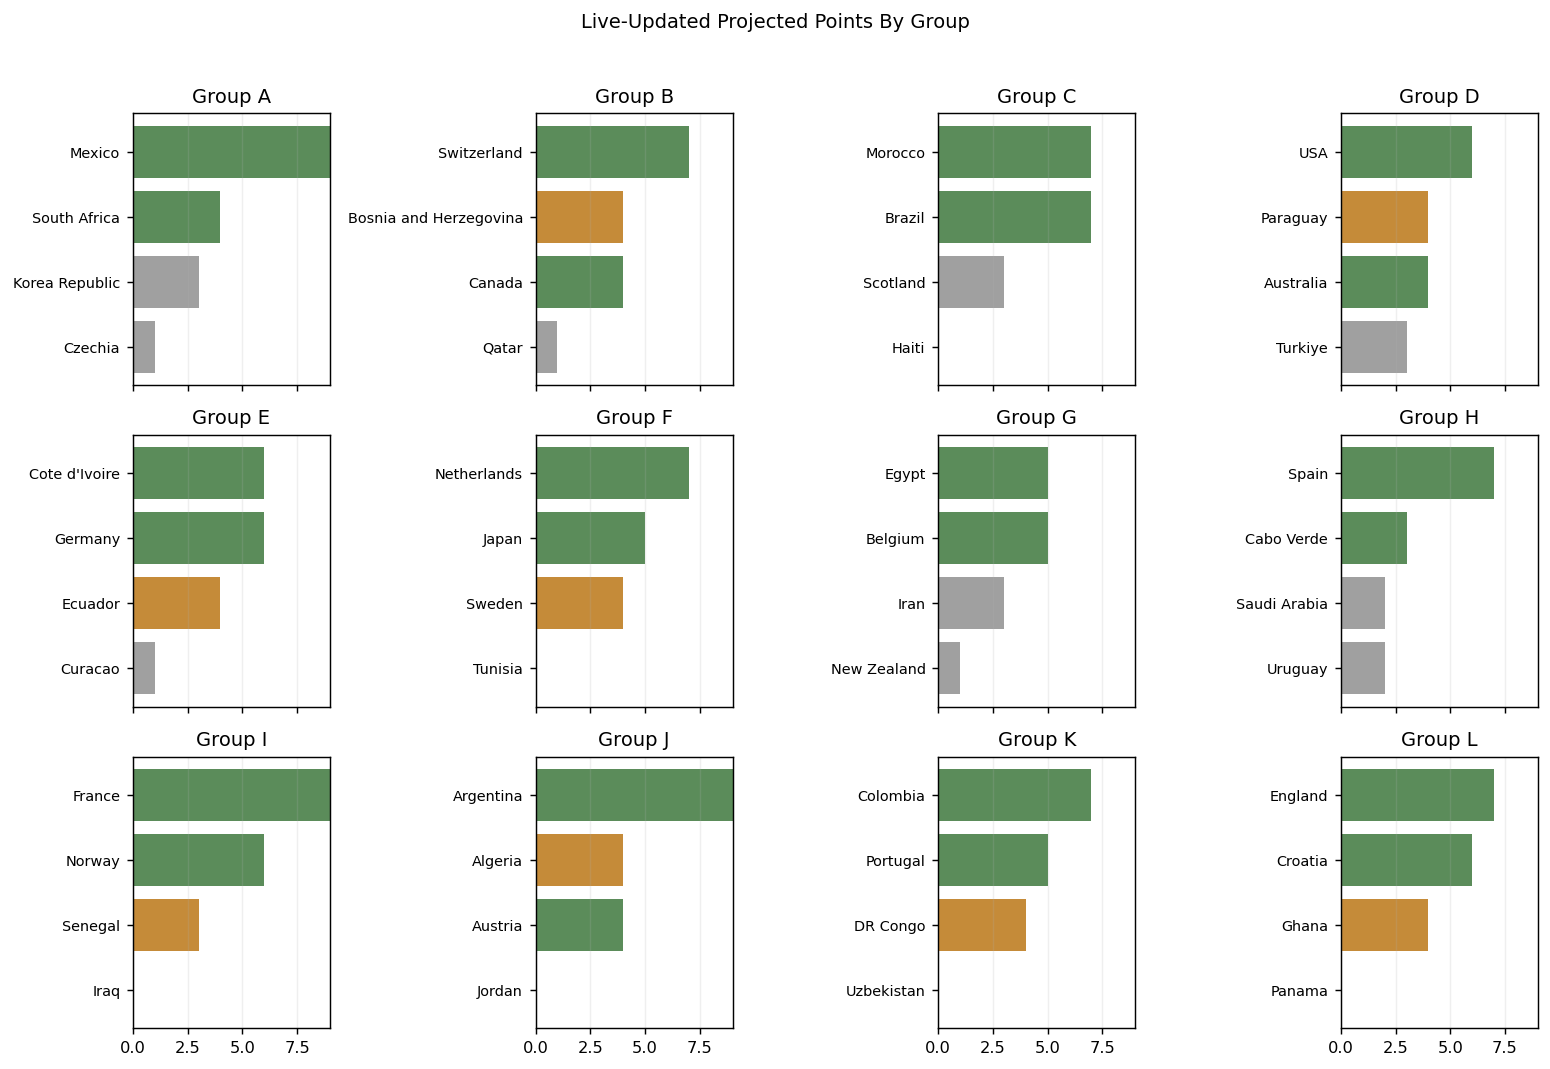

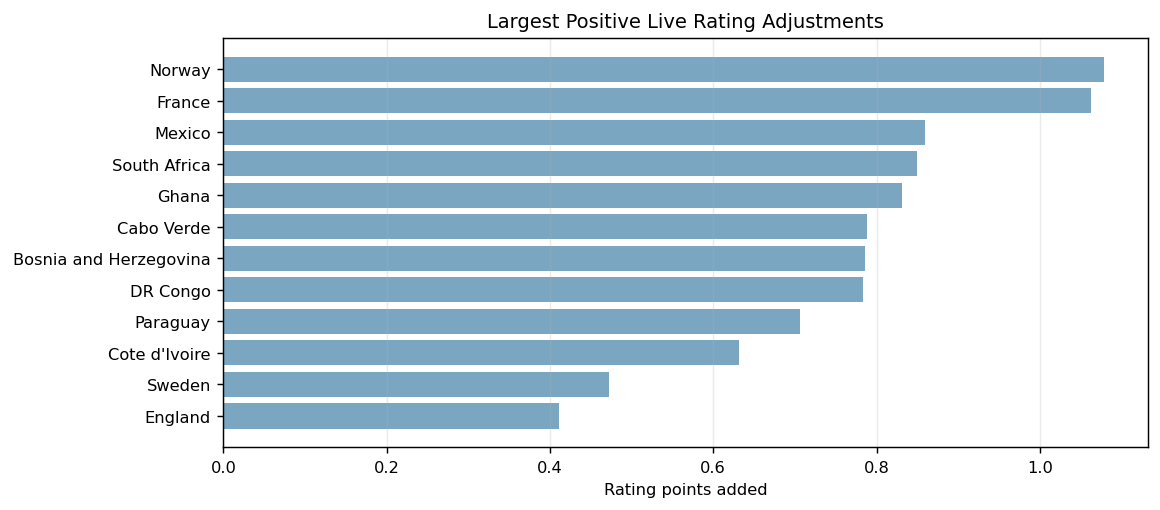

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8), sharex=True)
axes = axes.ravel()
third_set = set(live_best_thirds["team"])
for ax, (group, sub) in zip(axes, live_standings.groupby("group")):
    sub = sub.sort_values("projected_total_pts")
    colors = [
        "#5b8c5a" if pos <= 2 else "#c58b39" if team in third_set else "#a0a0a0"
        for pos, team in zip(sub["projected_group_position"], sub["team"])
    ]
    ax.barh(sub["team"], sub["projected_total_pts"], color=colors)
    ax.set_title(f"Group {group}")
    ax.set_xlim(0, 9)
    ax.grid(axis="x", alpha=0.2)
for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Live-Updated Projected Points By Group", y=1.02)
plt.tight_layout()
plt.show()

top_movers = teams_live_adjusted.assign(rating_change=lambda d: d["updated_rating"] - d["base_rating_june"]).sort_values("rating_change", ascending=False).head(12)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_movers.sort_values("rating_change")["team"], top_movers.sort_values("rating_change")["rating_change"], color="#7aa6c2")
ax.set_title("Largest Positive Live Rating Adjustments")
ax.set_xlabel("Rating points added")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [19]:
# Rebuild knockout bracket using the live-updated projected group table.
live_winners = live_standings[live_standings["projected_group_position"] == 1].set_index("group")["team"].to_dict()
live_runners_up = live_standings[live_standings["projected_group_position"] == 2].set_index("group")["team"].to_dict()
live_third_qualifiers = live_best_thirds.set_index("group")["team"].to_dict()
live_third_groups = "".join(sorted(live_third_qualifiers))

# Official Annex C rows for plausible/current projected third-place group sets.
third_mapping_lookup = {
    "BDEFIJKL": {"A": "E", "B": "J", "D": "B", "E": "D", "G": "I", "I": "F", "K": "L", "L": "K"},
    "BDEFGIJL": {"A": "E", "B": "G", "D": "B", "E": "D", "G": "J", "I": "F", "K": "L", "L": "I"},
    "CDEFGIJL": {"A": "C", "B": "G", "D": "E", "E": "D", "G": "J", "I": "F", "K": "L", "L": "I"},
    "CDFGIJKL": {"A": "C", "B": "G", "D": "I", "E": "D", "G": "J", "I": "F", "K": "L", "L": "K"},
    "BCDFGJKL": {"A": "C", "B": "G", "D": "B", "E": "D", "G": "J", "I": "F", "K": "L", "L": "K"},
    "BCDFGHJL": {"A": "C", "B": "G", "D": "B", "E": "D", "G": "H", "I": "F", "K": "L", "L": "J"},
    # Original preseason notebook row, kept as a fallback if assumptions are reverted.
    "ACDEGIJL": {"A": "E", "B": "G", "D": "J", "E": "C", "G": "A", "I": "D", "K": "L", "L": "I"},
}
if live_third_groups not in third_mapping_lookup:
    raise ValueError(f"No embedded Annex C mapping for projected third-place set {live_third_groups}. Add the row before building the bracket.")
third_map_live = third_mapping_lookup[live_third_groups]

ratings_live = teams_live_adjusted.set_index("team")["updated_rating"].to_dict()

completed_knockout_results_data = [
    # match, team_a, team_b, goals_a, goals_b, winner, result_note, source_note
    (73, "South Africa", "Canada", 0, 1, "Canada", "Canada 1-0 South Africa", "Locked actual Round of 32 result."),
    (74, "Germany", "Paraguay", 1, 1, "Paraguay", "1-1; Paraguay 4-3 pens", "Locked actual Round of 32 result."),
    (75, "Netherlands", "Morocco", 1, 1, "Morocco", "1-1; Morocco 3-2 pens", "Locked actual Round of 32 result."),
    (76, "Brazil", "Japan", 2, 1, "Brazil", "Brazil 2-1 Japan", "Locked actual Round of 32 result."),
    (77, "France", "Sweden", 3, 0, "France", "France 3-0 Sweden", "Locked actual Round of 32 result."),
    (78, "Cote d'Ivoire", "Norway", 1, 2, "Norway", "Norway 2-1 Cote d'Ivoire", "Locked actual Round of 32 result."),
    (79, "Mexico", "Ecuador", 2, 0, "Mexico", "Mexico 2-0 Ecuador", "Locked actual Round of 32 result."),
    (80, "England", "DR Congo", 2, 1, "England", "England 2-1 DR Congo", "Locked actual Round of 32 result."),
    (81, "USA", "Bosnia and Herzegovina", 2, 0, "USA", "USA 2-0 Bosnia and Herzegovina", "Locked actual Round of 32 result."),
    (82, "Belgium", "Senegal", 3, 2, "Belgium", "Belgium 3-2 Senegal", "Locked actual Round of 32 result."),
    (83, "Portugal", "Croatia", 2, 1, "Portugal", "Portugal 2-1 Croatia", "Locked actual Round of 32 result."),
    (84, "Spain", "Austria", 3, 0, "Spain", "Spain 3-0 Austria", "Locked actual Round of 32 result."),
    (85, "Switzerland", "Algeria", 2, 0, "Switzerland", "Switzerland 2-0 Algeria", "Locked actual Round of 32 result."),
    (86, "Argentina", "Cabo Verde", 3, 2, "Argentina", "Argentina 3-2 Cabo Verde (aet)", "Locked actual Round of 32 result."),
    (87, "Colombia", "Ghana", 1, 0, "Colombia", "Colombia 1-0 Ghana", "Locked actual Round of 32 result."),
    (88, "Australia", "Egypt", 1, 1, "Egypt", "1-1; Egypt 4-2 pens", "Locked actual Round of 32 result."),
    (89, "Paraguay", "France", 0, 1, "France", "France 1-0 Paraguay", "Locked actual Round of 16 result."),
    (90, "Canada", "Morocco", 0, 3, "Morocco", "Morocco 3-0 Canada", "Locked actual Round of 16 result."),
    (91, "Brazil", "Norway", 1, 2, "Norway", "Norway 2-1 Brazil", "Locked actual Round of 16 result."),
    (92, "Mexico", "England", 2, 3, "England", "England 3-2 Mexico", "Locked actual Round of 16 result."),
    (93, "Portugal", "Spain", 0, 1, "Spain", "Spain 1-0 Portugal", "Locked actual Round of 16 result."),
    (94, "USA", "Belgium", 1, 4, "Belgium", "Belgium 4-1 USA", "Locked actual Round of 16 result."),
    (95, "Argentina", "Egypt", 3, 2, "Argentina", "Argentina 3-2 Egypt", "Locked actual Round of 16 result."),
    (96, "Switzerland", "Colombia", 0, 0, "Switzerland", "0-0; Switzerland 4-3 pens", "Locked actual Round of 16 result."),
    (97, "France", "Morocco", 2, 0, "France", "France 2-0 Morocco", "Locked actual quarterfinal result."),
    (98, "Spain", "Belgium", 2, 1, "Spain", "Spain 2-1 Belgium", "Locked actual quarterfinal result."),
    (99, "Norway", "England", 1, 2, "England", "Norway 1-2 England (aet)", "Locked actual quarterfinal result."),
    (100, "Argentina", "Switzerland", 3, 1, "Argentina", "Argentina 3-1 Switzerland (aet)", "Locked actual quarterfinal result."),
]
completed_knockout_results = pd.DataFrame(
    completed_knockout_results_data,
    columns=["match", "actual_team_a", "actual_team_b", "actual_goals_a", "actual_goals_b", "actual_winner", "result_note", "source_note"],
)
completed_knockout_by_match = completed_knockout_results.set_index("match").to_dict("index")

# Analyst tactical priors are matchup-specific and intentionally separate from team ratings.
# They blend into knockout probabilities on the log-odds scale with a light 0.20 weight.
# This keeps the base model auditable while allowing tactical observations to matter.
analyst_prior_weight_default = 0.20
analyst_priors_data = [
    {
        "team_a": "Korea Republic",
        "team_b": "Canada",
        "favored_team": "Korea Republic",
        "analyst_favored_win_prob": 0.55,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Korea lineup quality; Son aging curve; Canada Qatar result tempered",
        "notes": "Canada's 6-0 Qatar win helps, but Korea still judged slightly stronger overall.",
    },
    {
        "team_a": "Morocco",
        "team_b": "Japan",
        "favored_team": "Morocco",
        "analyst_favored_win_prob": 0.65,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Japan cohesion; Morocco elite ceiling; AFCON/2022 pedigree",
        "notes": "Japan drew Netherlands and beat Tunisia 4-0; this compresses the gap versus the base model.",
    },
    {
        "team_a": "Portugal",
        "team_b": "Croatia",
        "favored_team": "Croatia",
        "analyst_favored_win_prob": 0.55,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Portugal chance creation poor; Ronaldo low-mobility drag; Croatia control",
        "notes": "Portugal's Uzbekistan scoreline is discounted; the Colombia draw and continued low repeatable chance creation move the human prior toward Croatia.",
    },
    {
        "team_a": "Morocco",
        "team_b": "Norway",
        "favored_team": "Morocco",
        "analyst_favored_win_prob": 0.75,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Morocco strength; Haaland transition threat; low-possession upset risk",
        "notes": "Morocco clearly stronger, but Haaland's counterattacking chance conversion lowers certainty.",
    },
    {
        "team_a": "Mexico",
        "team_b": "England",
        "favored_team": "England",
        "analyst_favored_win_prob": 0.62,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Mexico collective progression; home/Azteca edge; Kane clutch ceiling",
        "notes": "Mexico's team cohesion and vertical ball progression sharply compress the gap, but Kane's late-game superstar finishing keeps England a slight favorite.",
    },
    {
        "team_a": "Portugal",
        "team_b": "Spain",
        "favored_team": "Spain",
        "analyst_favored_win_prob": 0.75,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Spain control; Portugal structural chance-creation concern; Ronaldo role tradeoff",
        "notes": "If Portugal get there, Spain's structure rates substantially better against Portugal's current low-chance attacking profile.",
    },
    {
        "team_a": "Argentina",
        "team_b": "Belgium",
        "favored_team": "Argentina",
        "analyst_favored_win_prob": 0.85,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "Belgium decline; Lukaku role fit; Senegal survival luck; Argentina finishing",
        "notes": "Belgium are treated as below their historic reputation after consecutive draws, a very even Senegal escape, and a Lukaku profile that looks better off the bench than starting.",
    },
    {
        "team_a": "USA",
        "team_b": "Belgium",
        "favored_team": "USA",
        "analyst_favored_win_prob": 0.58,
        "analyst_weight": analyst_prior_weight_default,
        "rationale_tags": "USA tenacity; physicality; coordination; Belgium psychological edge concern",
        "notes": "USA are upgraded as a coordinated, physical, technically solid team that appears better than player market values imply; Belgium's Senegal win is discounted as a lucky/even-game escape.",
    },
]
analyst_priors = pd.DataFrame(analyst_priors_data)

def _safe_logit(p):
    p = min(max(float(p), 0.001), 0.999)
    return math.log(p / (1 - p))

def blended_with_analyst_prior(team_a, team_b, model_prob_team_a):
    rows = analyst_priors[
        ((analyst_priors["team_a"] == team_a) & (analyst_priors["team_b"] == team_b))
        | ((analyst_priors["team_a"] == team_b) & (analyst_priors["team_b"] == team_a))
    ]
    if rows.empty:
        return model_prob_team_a, None
    prior = rows.iloc[0]
    analyst_prob_team_a = (
        prior["analyst_favored_win_prob"]
        if prior["favored_team"] == team_a
        else 1 - prior["analyst_favored_win_prob"]
    )
    w = float(prior["analyst_weight"])
    blended = logistic((1 - w) * _safe_logit(model_prob_team_a) + w * _safe_logit(analyst_prob_team_a))
    return blended, {
        "analyst_prob_team_a": analyst_prob_team_a,
        "analyst_weight": w,
        "rationale_tags": prior["rationale_tags"],
        "analyst_notes": prior["notes"],
    }

match_market_weight = 0.10

def blended_with_match_market(team_a, team_b, prior_prob_team_a):
    if semifinal_market_priors.empty:
        return prior_prob_team_a, None
    matchup_name = ""
    for candidate, candidate_rows in semifinal_market_priors.groupby("matchup"):
        if set(candidate_rows["team"]) == {team_a, team_b}:
            matchup_name = candidate
            break
    if not matchup_name:
        return prior_prob_team_a, None
    rows = semifinal_market_priors[semifinal_market_priors["matchup"].eq(matchup_name)]
    team_row = rows[rows["team"].eq(team_a)]
    if team_row.empty:
        return prior_prob_team_a, None
    market_prob_team_a = float(team_row.iloc[0]["market_advance_prob"])
    blended = logistic(
        (1 - match_market_weight) * _safe_logit(prior_prob_team_a)
        + match_market_weight * _safe_logit(market_prob_team_a)
    )
    return blended, {
        "market_prob_team_a": market_prob_team_a,
        "match_market_weight": match_market_weight,
        "match_market_sources": team_row.iloc[0]["sources"],
        "market_matchup": matchup_name,
    }

def knockout_win_probability_live(team_a, team_b):
    return logistic((ratings_live[team_a] - ratings_live[team_b]) / 8)

def knockout_result_live(match, round_name, team_a, team_b, slot):
    model_p_a = knockout_win_probability_live(team_a, team_b)
    analyst_p_a, analyst_meta = blended_with_analyst_prior(team_a, team_b, model_p_a)
    p_a, market_meta = blended_with_match_market(team_a, team_b, analyst_p_a)
    actual = completed_knockout_by_match.get(match)
    status = "projected"
    result_note = ""
    if actual is not None:
        expected = {team_a, team_b}
        observed = {actual["actual_team_a"], actual["actual_team_b"]}
        if expected != observed:
            raise ValueError(f"Completed match {match} has teams {observed}, but bracket built {expected}.")
        winner = actual["actual_winner"]
        status = "actual"
        result_note = actual["result_note"]
    else:
        winner = team_a if p_a >= 0.5 else team_b
    loser = team_b if winner == team_a else team_a
    winner_probability = p_a if winner == team_a else 1 - p_a
    out = {
        "match": match,
        "round": round_name,
        "slot": slot,
        "team_a": team_a,
        "team_b": team_b,
        "status": status,
        "result_note": result_note,
        "model_win_prob_team_a": model_p_a,
        "win_prob_team_a": p_a,
        "winner": winner,
        "loser": loser,
        "winner_probability": winner_probability,
    }
    if analyst_meta:
        out.update(analyst_meta)
    else:
        out.update({
            "analyst_prob_team_a": np.nan,
            "analyst_weight": 0.0,
            "rationale_tags": "",
            "analyst_notes": "",
        })
    if market_meta:
        out.update(market_meta)
    else:
        out.update({
            "market_prob_team_a": np.nan,
            "match_market_weight": 0.0,
            "match_market_sources": "",
            "market_matchup": "",
        })
    return out

live_r32_pairs = OrderedDict([
    (73, (live_runners_up["A"], live_runners_up["B"], "2A vs 2B")),
    (74, (live_winners["E"], live_third_qualifiers[third_map_live["E"]], f"1E vs 3{third_map_live['E']}")),
    (75, (live_winners["F"], live_runners_up["C"], "1F vs 2C")),
    (76, (live_winners["C"], live_runners_up["F"], "1C vs 2F")),
    (77, (live_winners["I"], live_third_qualifiers[third_map_live["I"]], f"1I vs 3{third_map_live['I']}")),
    (78, (live_runners_up["E"], live_runners_up["I"], "2E vs 2I")),
    (79, (live_winners["A"], live_third_qualifiers[third_map_live["A"]], f"1A vs 3{third_map_live['A']}")),
    (80, (live_winners["L"], live_third_qualifiers[third_map_live["L"]], f"1L vs 3{third_map_live['L']}")),
    (81, (live_winners["D"], live_third_qualifiers[third_map_live["D"]], f"1D vs 3{third_map_live['D']}")),
    (82, (live_winners["G"], live_third_qualifiers[third_map_live["G"]], f"1G vs 3{third_map_live['G']}")),
    (83, (live_runners_up["K"], live_runners_up["L"], "2K vs 2L")),
    (84, (live_winners["H"], live_runners_up["J"], "1H vs 2J")),
    (85, (live_winners["B"], live_third_qualifiers[third_map_live["B"]], f"1B vs 3{third_map_live['B']}")),
    (86, (live_winners["J"], live_runners_up["H"], "1J vs 2H")),
    (87, (live_winners["K"], live_third_qualifiers[third_map_live["K"]], f"1K vs 3{third_map_live['K']}")),
    (88, (live_runners_up["D"], live_runners_up["G"], "2D vs 2G")),
])

live_knockout = {}
for match, (a, b, slot) in live_r32_pairs.items():
    live_knockout[match] = knockout_result_live(match, "Round of 32", a, b, slot)

def LW(match):
    return live_knockout[match]["winner"]

for match, (a, b, slot) in OrderedDict([
    (89, (LW(74), LW(77), "W74 vs W77")),
    (90, (LW(73), LW(75), "W73 vs W75")),
    (91, (LW(76), LW(78), "W76 vs W78")),
    (92, (LW(79), LW(80), "W79 vs W80")),
    (93, (LW(83), LW(84), "W83 vs W84")),
    (94, (LW(81), LW(82), "W81 vs W82")),
    (95, (LW(86), LW(88), "W86 vs W88")),
    (96, (LW(85), LW(87), "W85 vs W87")),
]).items():
    live_knockout[match] = knockout_result_live(match, "Round of 16", a, b, slot)

for match, (a, b, slot) in OrderedDict([
    (97, (LW(89), LW(90), "W89 vs W90")),
    (98, (LW(93), LW(94), "W93 vs W94")),
    (99, (LW(91), LW(92), "W91 vs W92")),
    (100, (LW(95), LW(96), "W95 vs W96")),
]).items():
    live_knockout[match] = knockout_result_live(match, "Quarterfinal", a, b, slot)

for match, (a, b, slot) in OrderedDict([
    (101, (LW(97), LW(98), "W97 vs W98")),
    (102, (LW(99), LW(100), "W99 vs W100")),
]).items():
    live_knockout[match] = knockout_result_live(match, "Semifinal", a, b, slot)

live_knockout[103] = knockout_result_live(103, "Third-place Match", live_knockout[101]["loser"], live_knockout[102]["loser"], "L101 vs L102")
live_knockout[104] = knockout_result_live(104, "Final", LW(101), LW(102), "W101 vs W102")

knockout_schedule = pd.DataFrame([
    {"match": 73, "date": "2026-06-28", "local_time": "12:00 p.m.", "utc_offset": "UTC-7", "stadium": "SoFi Stadium", "city": "Inglewood, CA"},
    {"match": 74, "date": "2026-06-29", "local_time": "4:30 p.m.", "utc_offset": "UTC-4", "stadium": "Gillette Stadium", "city": "Foxborough, MA"},
    {"match": 75, "date": "2026-06-29", "local_time": "7:00 p.m.", "utc_offset": "UTC-6", "stadium": "Estadio BBVA", "city": "Guadalupe, NL"},
    {"match": 76, "date": "2026-06-29", "local_time": "12:00 p.m.", "utc_offset": "UTC-5", "stadium": "NRG Stadium", "city": "Houston, TX"},
    {"match": 77, "date": "2026-06-30", "local_time": "5:00 p.m.", "utc_offset": "UTC-4", "stadium": "MetLife Stadium", "city": "East Rutherford, NJ"},
    {"match": 78, "date": "2026-06-30", "local_time": "12:00 p.m.", "utc_offset": "UTC-5", "stadium": "AT&T Stadium", "city": "Arlington, TX"},
    {"match": 79, "date": "2026-06-30", "local_time": "7:00 p.m.", "utc_offset": "UTC-6", "stadium": "Estadio Azteca", "city": "Mexico City, MX"},
    {"match": 80, "date": "2026-07-01", "local_time": "12:00 p.m.", "utc_offset": "UTC-4", "stadium": "Mercedes-Benz Stadium", "city": "Atlanta, GA"},
    {"match": 81, "date": "2026-07-01", "local_time": "5:00 p.m.", "utc_offset": "UTC-7", "stadium": "Levi's Stadium", "city": "Santa Clara, CA"},
    {"match": 82, "date": "2026-07-01", "local_time": "1:00 p.m.", "utc_offset": "UTC-7", "stadium": "Lumen Field", "city": "Seattle, WA"},
    {"match": 83, "date": "2026-07-02", "local_time": "7:00 p.m.", "utc_offset": "UTC-4", "stadium": "BMO Field", "city": "Toronto, ON"},
    {"match": 84, "date": "2026-07-02", "local_time": "12:00 p.m.", "utc_offset": "UTC-7", "stadium": "SoFi Stadium", "city": "Inglewood, CA"},
    {"match": 85, "date": "2026-07-02", "local_time": "8:00 p.m.", "utc_offset": "UTC-7", "stadium": "BC Place", "city": "Vancouver, BC"},
    {"match": 86, "date": "2026-07-03", "local_time": "6:00 p.m.", "utc_offset": "UTC-4", "stadium": "Hard Rock Stadium", "city": "Miami Gardens, FL"},
    {"match": 87, "date": "2026-07-03", "local_time": "8:30 p.m.", "utc_offset": "UTC-5", "stadium": "Arrowhead Stadium", "city": "Kansas City, MO"},
    {"match": 88, "date": "2026-07-03", "local_time": "1:00 p.m.", "utc_offset": "UTC-5", "stadium": "AT&T Stadium", "city": "Arlington, TX"},
    {"match": 89, "date": "2026-07-04", "local_time": "5:00 p.m.", "utc_offset": "UTC-4", "stadium": "Lincoln Financial Field", "city": "Philadelphia, PA"},
    {"match": 90, "date": "2026-07-04", "local_time": "12:00 p.m.", "utc_offset": "UTC-5", "stadium": "NRG Stadium", "city": "Houston, TX"},
    {"match": 91, "date": "2026-07-05", "local_time": "4:00 p.m.", "utc_offset": "UTC-4", "stadium": "MetLife Stadium", "city": "East Rutherford, NJ"},
    {"match": 92, "date": "2026-07-05", "local_time": "6:00 p.m.", "utc_offset": "UTC-6", "stadium": "Estadio Azteca", "city": "Mexico City, MX"},
    {"match": 93, "date": "2026-07-06", "local_time": "2:00 p.m.", "utc_offset": "UTC-5", "stadium": "AT&T Stadium", "city": "Arlington, TX"},
    {"match": 94, "date": "2026-07-06", "local_time": "5:00 p.m.", "utc_offset": "UTC-7", "stadium": "Lumen Field", "city": "Seattle, WA"},
    {"match": 95, "date": "2026-07-07", "local_time": "12:00 p.m.", "utc_offset": "UTC-4", "stadium": "Mercedes-Benz Stadium", "city": "Atlanta, GA"},
    {"match": 96, "date": "2026-07-07", "local_time": "1:00 p.m.", "utc_offset": "UTC-7", "stadium": "BC Place", "city": "Vancouver, BC"},
    {"match": 97, "date": "2026-07-09", "local_time": "4:00 p.m.", "utc_offset": "UTC-4", "stadium": "Gillette Stadium", "city": "Foxborough, MA"},
    {"match": 98, "date": "2026-07-10", "local_time": "12:00 p.m.", "utc_offset": "UTC-7", "stadium": "SoFi Stadium", "city": "Inglewood, CA"},
    {"match": 99, "date": "2026-07-11", "local_time": "5:00 p.m.", "utc_offset": "UTC-4", "stadium": "Hard Rock Stadium", "city": "Miami Gardens, FL"},
    {"match": 100, "date": "2026-07-11", "local_time": "8:00 p.m.", "utc_offset": "UTC-5", "stadium": "Arrowhead Stadium", "city": "Kansas City, MO"},
    {"match": 101, "date": "2026-07-14", "local_time": "2:00 p.m.", "utc_offset": "UTC-5", "stadium": "AT&T Stadium", "city": "Arlington, TX"},
    {"match": 102, "date": "2026-07-15", "local_time": "3:00 p.m.", "utc_offset": "UTC-4", "stadium": "Mercedes-Benz Stadium", "city": "Atlanta, GA"},
    {"match": 103, "date": "2026-07-18", "local_time": "5:00 p.m.", "utc_offset": "UTC-4", "stadium": "Hard Rock Stadium", "city": "Miami Gardens, FL"},
    {"match": 104, "date": "2026-07-19", "local_time": "3:00 p.m.", "utc_offset": "UTC-4", "stadium": "MetLife Stadium", "city": "East Rutherford, NJ"},
])
knockout_schedule["weekday"] = pd.to_datetime(knockout_schedule["date"]).dt.day_name()
knockout_schedule["local_kickoff"] = knockout_schedule["local_time"] + " " + knockout_schedule["utc_offset"]
knockout_schedule["location"] = knockout_schedule["stadium"] + ", " + knockout_schedule["city"]

live_knockout_table = (
    pd.DataFrame(live_knockout.values())
    .sort_values("match")
    .merge(knockout_schedule, on="match", how="left")
)
live_result_view = live_knockout_table[[
    "round", "match", "date", "weekday", "local_kickoff", "location",
    "slot", "team_a", "team_b", "status", "result_note", "winner", "winner_probability"
]].copy()
live_result_view["winner_probability"] = (100 * live_result_view["winner_probability"]).round(1).astype(str) + "%"

analyst_prior_effects = live_knockout_table[live_knockout_table["analyst_weight"] > 0][[
    "round", "match", "team_a", "team_b", "model_win_prob_team_a", "analyst_prob_team_a",
    "win_prob_team_a", "winner", "winner_probability", "rationale_tags", "analyst_notes"
]].copy()
for col in ["model_win_prob_team_a", "analyst_prob_team_a", "win_prob_team_a", "winner_probability"]:
    analyst_prior_effects[col] = (100 * analyst_prior_effects[col]).round(1).astype(str) + "%"

market_prior_effects = live_knockout_table[live_knockout_table["match_market_weight"] > 0][[
    "round", "match", "team_a", "team_b", "model_win_prob_team_a",
    "market_prob_team_a", "match_market_weight", "win_prob_team_a", "winner",
    "winner_probability", "match_market_sources",
]].copy()
for col in ["model_win_prob_team_a", "market_prob_team_a", "win_prob_team_a", "winner_probability"]:
    market_prior_effects[col] = (100 * market_prior_effects[col]).round(1).astype(str) + "%"

print("Analyst tactical priors applied with weight", analyst_prior_weight_default)
display(analyst_priors)
print("Knockout probabilities after analyst-prior blending:")
display(analyst_prior_effects)
print("Semifinal probabilities after the 0.10 matchup-market blend:")
display(market_prior_effects)

print(f"Projected third-place group set: {live_third_groups}")
print(f"Live-updated champion: {live_knockout[104]['winner']}")
for round_name in ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Third-place Match", "Final"]:
    print(f"\n{round_name}")
    display(live_result_view[live_result_view["round"] == round_name])

Analyst tactical priors applied with weight 0.2


,team_a,team_b,favored_team,analyst_favored_win_prob,analyst_weight,rationale_tags,notes
0,Korea Republic,Canada,Korea Republic,0.55,0.2,Korea lineup quality; Son aging curve; Canada Qatar result tempered,"Canada's 6-0 Qatar win helps, but Korea still judged slightly stronger overall."
1,Morocco,Japan,Morocco,0.65,0.2,Japan cohesion; Morocco elite ceiling; AFCON/2022 pedigree,Japan drew Netherlands and beat Tunisia 4-0; this compresses the gap versus the base model.
2,Portugal,Croatia,Croatia,0.55,0.2,Portugal chance creation poor; Ronaldo low-mobility drag; Croatia control,Portugal's Uzbekistan scoreline is discounted; the Colombia draw and continued low repeatable chance creation move the human prior towar...
3,Morocco,Norway,Morocco,0.75,0.2,Morocco strength; Haaland transition threat; low-possession upset risk,"Morocco clearly stronger, but Haaland's counterattacking chance conversion lowers certainty."
4,Mexico,England,England,0.62,0.2,Mexico collective progression; home/Azteca edge; Kane clutch ceiling,"Mexico's team cohesion and vertical ball progression sharply compress the gap, but Kane's late-game superstar finishing keeps England a ..."
5,Portugal,Spain,Spain,0.75,0.2,Spain control; Portugal structural chance-creation concern; Ronaldo role tradeoff,"If Portugal get there, Spain's structure rates substantially better against Portugal's current low-chance attacking profile."
6,Argentina,Belgium,Argentina,0.85,0.2,Belgium decline; Lukaku role fit; Senegal survival luck; Argentina finishing,"Belgium are treated as below their historic reputation after consecutive draws, a very even Senegal escape, and a Lukaku profile that lo..."
7,USA,Belgium,USA,0.58,0.2,USA tenacity; physicality; coordination; Belgium psychological edge concern,"USA are upgraded as a coordinated, physical, technically solid team that appears better than player market values imply; Belgium's Seneg..."


Knockout probabilities after analyst-prior blending:


,round,match,team_a,team_b,model_win_prob_team_a,analyst_prob_team_a,win_prob_team_a,winner,winner_probability,rationale_tags,analyst_notes
10,Round of 32,83,Portugal,Croatia,69.7%,45.0%,65.1%,Portugal,65.1%,Portugal chance creation poor; Ronaldo low-mobility drag; Croatia control,Portugal's Uzbekistan scoreline is discounted; the Colombia draw and continued low repeatable chance creation move the human prior towar...
19,Round of 16,92,Mexico,England,27.3%,38.0%,29.3%,England,70.7%,Mexico collective progression; home/Azteca edge; Kane clutch ceiling,"Mexico's team cohesion and vertical ball progression sharply compress the gap, but Kane's late-game superstar finishing keeps England a ..."
20,Round of 16,93,Portugal,Spain,37.5%,25.0%,34.8%,Spain,65.2%,Spain control; Portugal structural chance-creation concern; Ronaldo role tradeoff,"If Portugal get there, Spain's structure rates substantially better against Portugal's current low-chance attacking profile."
21,Round of 16,94,USA,Belgium,36.6%,58.0%,40.7%,Belgium,59.3%,USA tenacity; physicality; coordination; Belgium psychological edge concern,"USA are upgraded as a coordinated, physical, technically solid team that appears better than player market values imply; Belgium's Seneg..."


Semifinal probabilities after the 0.10 matchup-market blend:


...

,round,match,date,weekday,local_kickoff,location,slot,team_a,team_b,status,result_note,winner,winner_probability
28,Semifinal,101,2026-07-14,Tuesday,2:00 p.m. UTC-5,"AT&T Stadium, Arlington, TX",W97 vs W98,France,Spain,projected,,France,52.8%
29,Semifinal,102,2026-07-15,Wednesday,3:00 p.m. UTC-4,"Mercedes-Benz Stadium, Atlanta, GA",W99 vs W100,England,Argentina,projected,,Argentina,55.6%



Third-place Match


,round,match,date,weekday,local_kickoff,location,slot,team_a,team_b,status,result_note,winner,winner_probability
30,Third-place Match,103,2026-07-18,Saturday,5:00 p.m. UTC-4,"Hard Rock Stadium, Miami Gardens, FL",L101 vs L102,Spain,England,projected,,Spain,54.0%



Final


,round,match,date,weekday,local_kickoff,location,slot,team_a,team_b,status,result_note,winner,winner_probability
31,Final,104,2026-07-19,Sunday,3:00 p.m. UTC-4,"MetLife Stadium, East Rutherford, NJ",W101 vs W102,France,Argentina,projected,,Argentina,50.7%


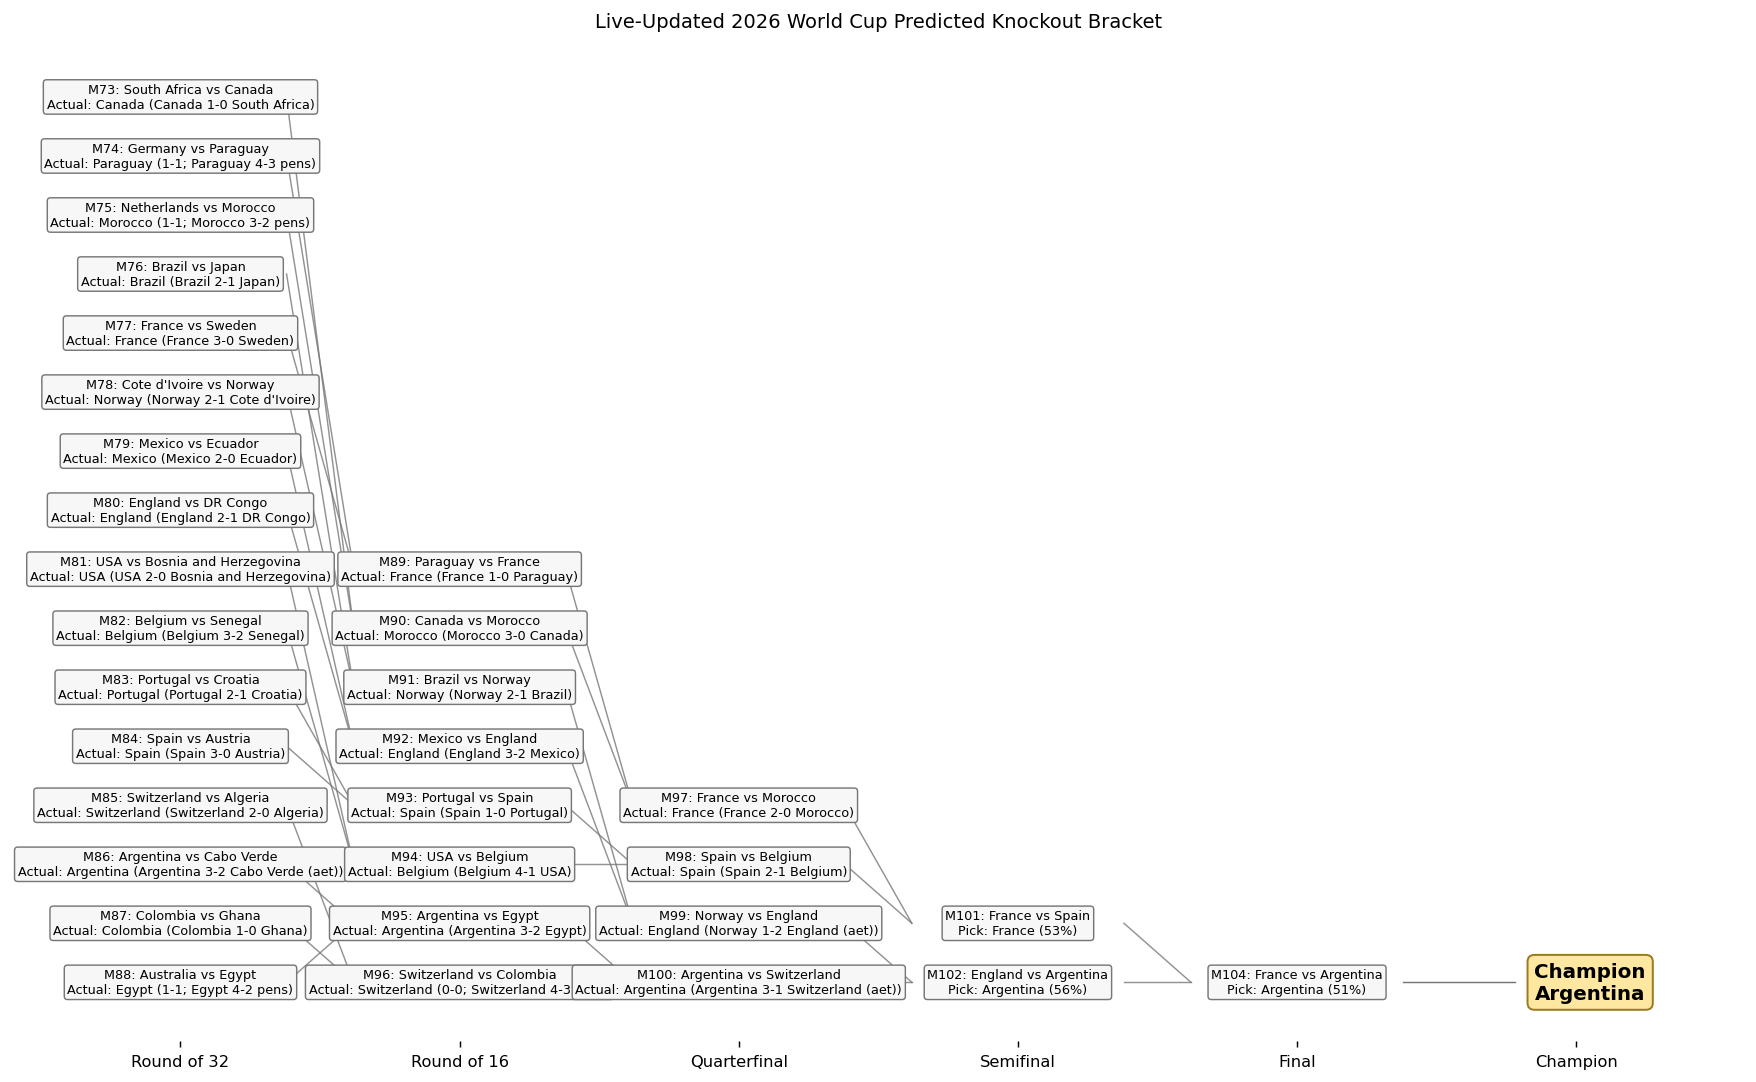

In [20]:
round_order = ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Final"]
round_x = {name: i for i, name in enumerate(round_order)}
y_positions = {}
for round_name in round_order:
    matches = live_knockout_table[live_knockout_table["round"] == round_name]["match"].tolist()
    n = len(matches)
    for i, match in enumerate(matches):
        y_positions[match] = n - i

parents = {
    89: [74, 77], 90: [73, 75], 91: [76, 78], 92: [79, 80],
    93: [83, 84], 94: [81, 82], 95: [86, 88], 96: [85, 87],
    97: [89, 90], 98: [93, 94], 99: [91, 92], 100: [95, 96],
    101: [97, 98], 102: [99, 100], 104: [101, 102],
}

fig, ax = plt.subplots(figsize=(13.8, 8.4))
for _, row in live_knockout_table[live_knockout_table["round"].isin(round_order)].iterrows():
    x = round_x[row["round"]]
    y = y_positions[row["match"]]
    if row.get("status", "projected") == "actual":
        label = f"M{int(row['match'])}: {row['team_a']} vs {row['team_b']}\nActual: {row['winner']} ({row['result_note']})"
    else:
        label = f"M{int(row['match'])}: {row['team_a']} vs {row['team_b']}\nPick: {row['winner']} ({row['winner_probability'] * 100:.0f}%)"
    ax.text(x, y, label, ha="center", va="center", fontsize=7.1,
            bbox=dict(boxstyle="round,pad=0.25", fc="#f7f7f7", ec="#777777", lw=0.8))

for child, parent_matches in parents.items():
    child_row = live_knockout[child]
    child_x = round_x[child_row["round"]]
    child_y = y_positions[child]
    for parent in parent_matches:
        parent_row = live_knockout[parent]
        parent_x = round_x[parent_row["round"]]
        parent_y = y_positions[parent]
        ax.plot([parent_x + 0.38, child_x - 0.38], [parent_y, child_y], color="#777777", lw=0.8, alpha=0.8)

champion = live_knockout[104]["winner"]
ax.text(5.05, y_positions[104], f"Champion\n{champion}", ha="center", va="center", fontsize=11, weight="bold",
        bbox=dict(boxstyle="round,pad=0.35", fc="#fde7a1", ec="#9a7b20", lw=1.1))
ax.plot([4.38, 4.78], [y_positions[104], y_positions[104]], color="#777777", lw=0.8)

ax.set_xlim(-0.6, 5.6)
ax.set_ylim(0, 17)
ax.set_xticks(list(round_x.values()) + [5])
ax.set_xticklabels(round_order + ["Champion"])
ax.set_yticks([])
ax.set_title("Live-Updated 2026 World Cup Predicted Knockout Bracket")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
live_summary = pd.DataFrame([
    {"result": "Champion", "team": live_knockout[104]["winner"]},
    {"result": "Runner-up", "team": live_knockout[104]["loser"]},
    {"result": "Third place", "team": live_knockout[103]["winner"]},
    {"result": "Fourth place", "team": live_knockout[103]["loser"]},
])
display(live_summary)

norway_row = live_standings[live_standings["team"] == "Norway"].iloc[0]
print(
    f"Norway live projection: Group {norway_row['group']} position {int(norway_row['projected_group_position'])}, "
    f"{norway_row['projected_total_pts']:.2f} projected points, {norway_row['projected_total_gd']:.2f} projected GD."
)
norway_ko = live_knockout_table[
    (live_knockout_table["team_a"] == "Norway") | (live_knockout_table["team_b"] == "Norway")
].head(1)
if not norway_ko.empty:
    r = norway_ko.iloc[0]
    opponent = r["team_b"] if r["team_a"] == "Norway" else r["team_a"]
    print(
        f"Norway's current model path starts in Match {int(r['match'])} ({r['round']}): "
        f"Norway vs {opponent}, via slot {r['slot']}."
    )
else:
    print("Norway is not projected into the live-updated knockout bracket.")

,result,team
0,Champion,Argentina
1,Runner-up,France
2,Third place,Spain
3,Fourth place,England


Norway live projection: Group I position 2, 6.00 projected points, 1.00 projected GD.
Norway's current model path starts in Match 78 (Round of 32): Norway vs Cote d'Ivoire, via slot 2E vs 2I.


## Player Performance vs Transfermarkt Value

This section compares star-player market value against World Cup performance so far.

Data structure:

- **X-axis:** Transfermarkt market value, in EUR millions.
- **Y-axis:** weighted average post-match rating.
- **Rating formula:** if minutes are available for every rated match, use `sum(rating * minutes) / sum(minutes)`; otherwise use a simple average.
- **Team selector:** use the widget when available, or call `plot_player_value_vs_performance(["Argentina", "France"])` manually.
- **Quadrant grid:** default thresholds are **EUR 75m** Transfermarkt value and **7.0** post-match rating.

Source caveats:

- Transfermarkt profile pages expose current player market values, but values move over time. The table below is a seeded snapshot in EUR millions and includes update URLs.
- SofaScore is the primary rating source. The project stores direct ratings and minutes for all 100 completed matches through M100, fetched with the reproducible browser-like curl collector.
- Google lineup extracts remain an audit/fallback source only. A tracked player with any direct SofaScore rows is plotted exclusively from those direct rows, so proxy or Google values do not contaminate that player's tournament average.
- Rows marked `team_proxy` are included only to keep all selected star players visible. The default chart now uses `include_team_proxy=False`, so players without exact ratings are omitted unless you explicitly include proxy rows.

References:

- Transfermarkt player profiles and market values: https://www.transfermarkt.com/
- Sofascore World Cup tournament/match pages and rating system: https://www.sofascore.com/football/tournament/world/world-championship/16

Imported 338 direct SofaScore rows for 78 tracked players.
Imported 231 Google lineup rating rows from data\google\google_lineup_player_ratings.csv.


,star_players,exact_player_ratings,team_proxy_ratings,missing_rating,value_source,rating_source
0,96,82,14,0,"Transfermarkt public profile/search pages, EUR millions",Direct SofaScore; Google/event rows only for tracked players without direct rows


,team,player,transfermarkt_value_eur_m,world_cup_rating,team_proxy_rating,plot_rating_basis,rated_matches,rating_sources,transfermarkt_search_url
80,Algeria,Amine Gouiri,30,6.77,7.61,exact_player_rating,4.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Amine+Gouiri
79,Algeria,Ismael Bennacer,15,NaN,7.61,team_proxy,NaN,NaN,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Ismael+Bennacer
78,Algeria,Riyad Mahrez,8,7.51,7.61,exact_player_rating,4.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Riyad+Mahrez
73,Argentina,Lautaro Martinez,95,6.60,7.47,exact_player_rating,6.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Lautaro+Martinez
74,Argentina,Julian Alvarez,90,6.77,7.47,exact_player_rating,6.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Julian+Alvarez
72,Argentina,Lionel Messi,18,9.32,7.47,exact_player_rating,6.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Lionel+Messi
31,Australia,Harry Souttar,8,7.00,7.60,exact_player_rating,4.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Harry+Souttar
30,Australia,Mathew Ryan,3,NaN,7.60,team_proxy,NaN,NaN,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Mathew+Ryan
32,Australia,Jackson Irvine,3,7.50,7.60,exact_player_rating,4.0,SofaScore direct,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Jackson+Irvine
77,Austria,Christoph Baumgartner,22,NaN,7.31,team_proxy,NaN,NaN,https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Christoph+Baumgartner


All-star-player plot using exact player ratings only. Toggle include_team_proxy=True to show proxy rows.


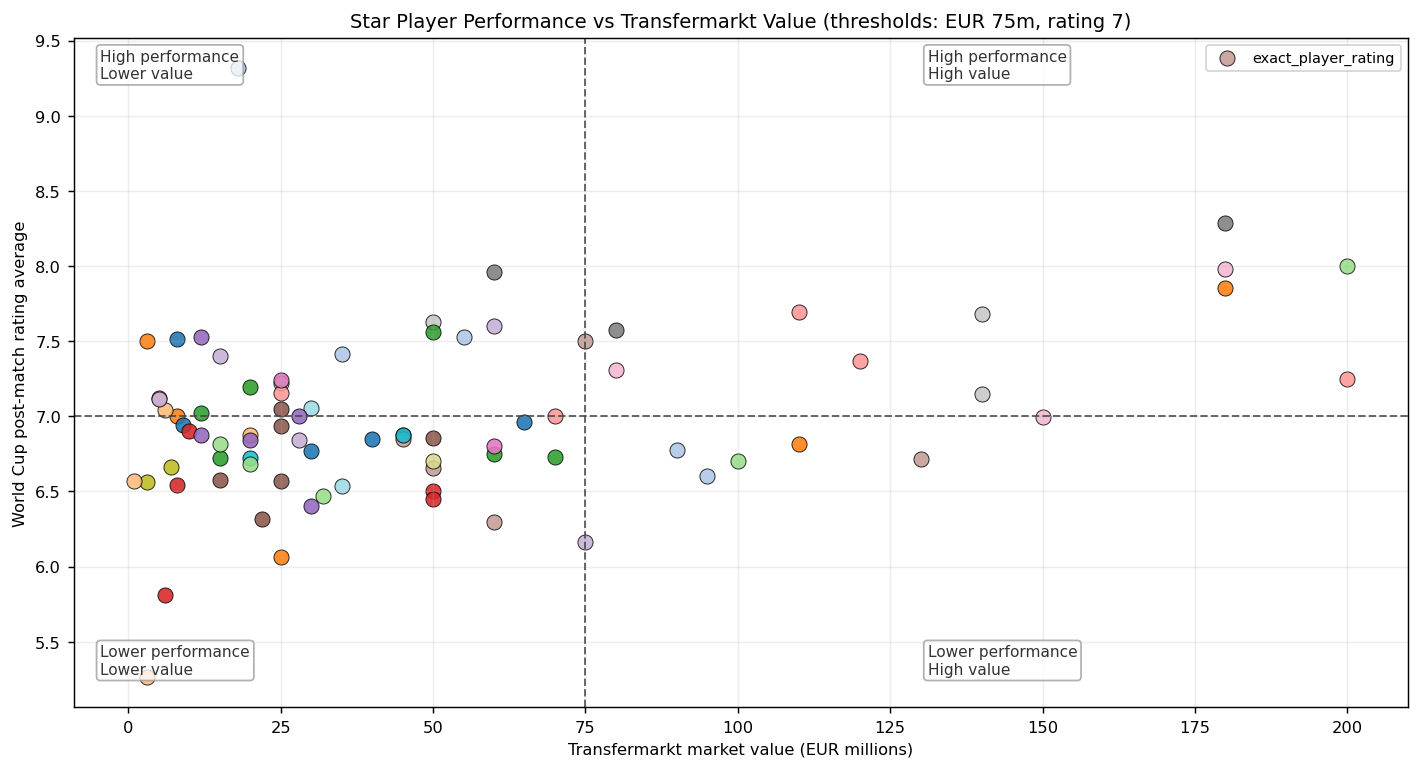

Quadrant counts:


,quadrant,players
0,Lower performance (< 7) / Lower value (< EUR 75m),40
1,High performance (>= 7) / Lower value (< EUR 75m),23
2,High performance (>= 7) / High value (>= EUR 75m),12
3,Lower performance (< 7) / High value (>= EUR 75m),7


Default selected-team plot. Change the team list below or use the widget if available.


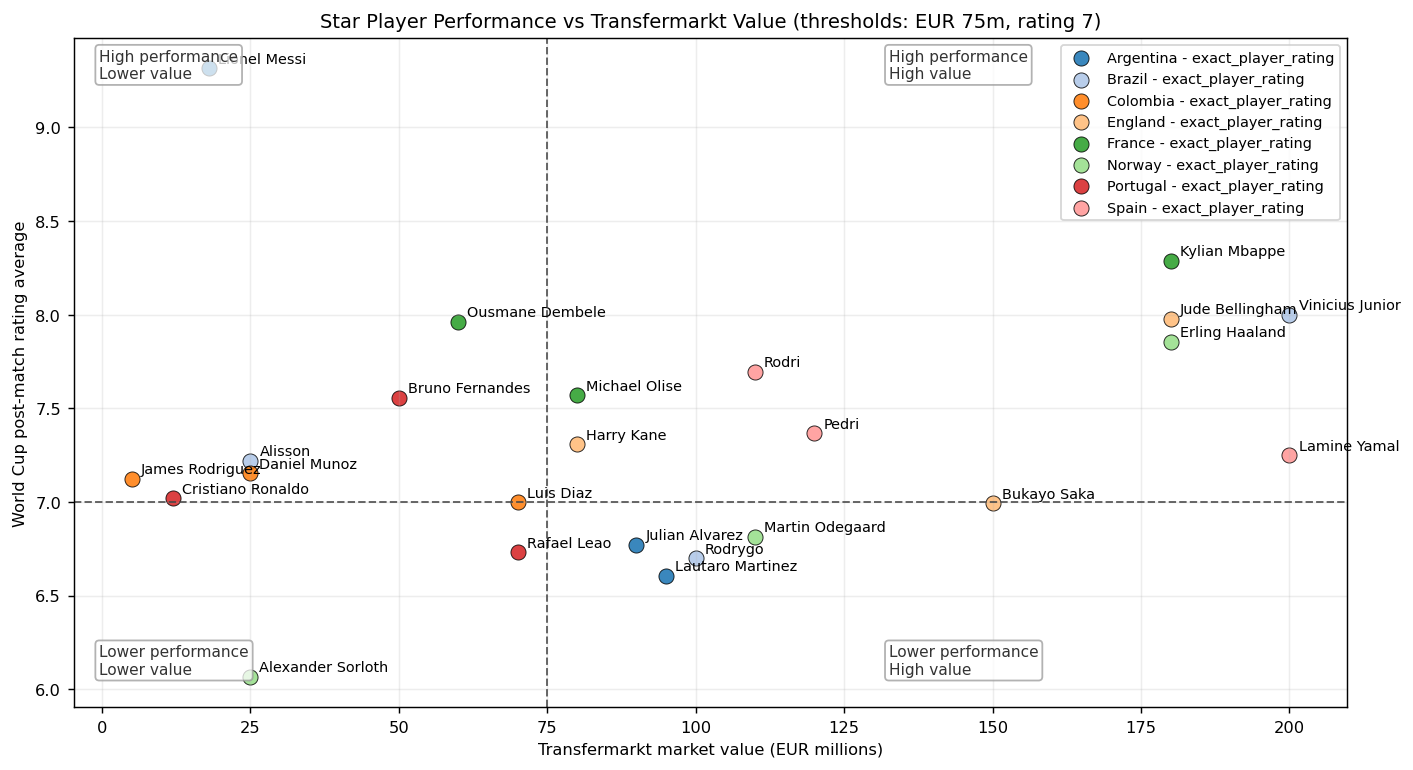

Quadrant counts:


,quadrant,players
0,High performance (>= 7) / High value (>= EUR 75m),9
1,High performance (>= 7) / Lower value (< EUR 75m),7
2,Lower performance (< 7) / High value (>= EUR 75m),5
3,Lower performance (< 7) / Lower value (< EUR 75m),3


Interactive player-value widgets skipped for batch execution.


In [22]:
import re
import unicodedata
import urllib.parse
from pathlib import Path

transfermarkt_values_data = [
    # team, player, market_value_eur_m
    ("Mexico", "Santiago Gimenez", 35), ("Mexico", "Edson Alvarez", 30), ("Mexico", "Hirving Lozano", 10),
    ("Korea Republic", "Son Heung-min", 20), ("Korea Republic", "Kim Min-jae", 45), ("Korea Republic", "Lee Kang-in", 30),
    ("Czechia", "Patrik Schick", 22), ("Czechia", "Tomas Soucek", 25), ("Czechia", "Adam Hlozek", 15),
    ("Switzerland", "Granit Xhaka", 12), ("Switzerland", "Manuel Akanji", 28), ("Switzerland", "Breel Embolo", 12),
    ("Canada", "Alphonso Davies", 50), ("Canada", "Jonathan David", 45), ("Canada", "Tajon Buchanan", 8),
    ("Brazil", "Vinicius Junior", 200), ("Brazil", "Rodrygo", 100), ("Brazil", "Alisson", 25),
    ("Morocco", "Achraf Hakimi", 65), ("Morocco", "Yassine Bounou", 9), ("Morocco", "Brahim Diaz", 40),
    ("Scotland", "Andy Robertson", 20), ("Scotland", "Scott McTominay", 32), ("Scotland", "John McGinn", 15),
    ("USA", "Christian Pulisic", 50), ("USA", "Weston McKennie", 25), ("USA", "Antonee Robinson", 25),
    ("Turkiye", "Hakan Calhanoglu", 15), ("Turkiye", "Arda Guler", 60), ("Turkiye", "Kenan Yildiz", 50),
    ("Australia", "Mathew Ryan", 3), ("Australia", "Harry Souttar", 8), ("Australia", "Jackson Irvine", 3),
    ("Germany", "Jamal Musiala", 140), ("Germany", "Florian Wirtz", 140), ("Germany", "Joshua Kimmich", 50),
    ("Ecuador", "Moises Caicedo", 75), ("Ecuador", "Piero Hincapie", 50), ("Ecuador", "Willian Pacho", 45),
    ("Cote d'Ivoire", "Simon Adingra", 30), ("Cote d'Ivoire", "Franck Kessie", 20), ("Cote d'Ivoire", "Sebastien Haller", 10),
    ("Netherlands", "Virgil van Dijk", 35), ("Netherlands", "Cody Gakpo", 55), ("Netherlands", "Xavi Simons", 70),
    ("Japan", "Takefusa Kubo", 50), ("Japan", "Kaoru Mitoma", 45), ("Japan", "Wataru Endo", 13),
    ("Belgium", "Kevin De Bruyne", 20), ("Belgium", "Jeremy Doku", 60), ("Belgium", "Romelu Lukaku", 15),
    ("Iran", "Mehdi Taremi", 7), ("Iran", "Sardar Azmoun", 6), ("Iran", "Alireza Jahanbakhsh", 3),
    ("Egypt", "Mohamed Salah", 25), ("Egypt", "Omar Marmoush", 60), ("Egypt", "Mostafa Mohamed", 8),
    ("Spain", "Lamine Yamal", 200), ("Spain", "Pedri", 120), ("Spain", "Rodri", 110),
    ("Uruguay", "Federico Valverde", 130), ("Uruguay", "Darwin Nunez", 60), ("Uruguay", "Ronald Araujo", 60),
    ("France", "Kylian Mbappe", 180), ("France", "Ousmane Dembele", 60), ("France", "Michael Olise", 80),
    ("Senegal", "Sadio Mane", 10), ("Senegal", "Nicolas Jackson", 50), ("Senegal", "Kalidou Koulibaly", 6),
    ("Norway", "Erling Haaland", 180), ("Norway", "Martin Odegaard", 110), ("Norway", "Alexander Sorloth", 25),
    ("Argentina", "Lionel Messi", 18), ("Argentina", "Lautaro Martinez", 95), ("Argentina", "Julian Alvarez", 90),
    ("Austria", "David Alaba", 6), ("Austria", "Marcel Sabitzer", 20), ("Austria", "Christoph Baumgartner", 22),
    ("Algeria", "Riyad Mahrez", 8), ("Algeria", "Ismael Bennacer", 15), ("Algeria", "Amine Gouiri", 30),
    ("Portugal", "Cristiano Ronaldo", 12), ("Portugal", "Bruno Fernandes", 50), ("Portugal", "Rafael Leao", 70),
    ("Colombia", "Luis Diaz", 70), ("Colombia", "James Rodriguez", 5), ("Colombia", "Daniel Munoz", 25),
    ("England", "Harry Kane", 80), ("England", "Jude Bellingham", 180), ("England", "Bukayo Saka", 150),
    ("Croatia", "Luka Modric", 5), ("Croatia", "Josko Gvardiol", 75), ("Croatia", "Mateo Kovacic", 28),
    ("Panama", "Adalberto Carrasquilla", 4), ("Panama", "Michael Murillo", 3), ("Panama", "Jose Fajardo", 1),
]

star_player_values = pd.DataFrame(
    transfermarkt_values_data,
    columns=["team", "player", "transfermarkt_value_eur_m"],
)
star_player_values["transfermarkt_search_url"] = star_player_values["player"].map(
    lambda p: "https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query="
    + urllib.parse.quote_plus(p)
)

star_player_match_ratings_data = [
    # player, team, match, rating, minutes_played, rating_source, note
    ("Vinicius Junior", "Brazil", "Brazil matchday June 24", 9.3, np.nan, "Sofascore public article", "Player of the Day; Sofascore Rating 9.3."),
    ("Achraf Hakimi", "Morocco", "Morocco matchday June 24", 8.0, np.nan, "Sofascore qualitative proxy", "Sofascore article notes goal and assist; exact number not exposed in static page."),
    ("Gregor Kobel", "Switzerland", "Switzerland matchday June 24", 8.9, np.nan, "Sofascore public article", "Keeper clinic; 6 big saves and Sofascore Rating 8.9. Not in key-player table by default."),
    ("Kylian Mbappe", "France", "France 3-1 Senegal", 8.8, 90, "event proxy", "Two goals; became France all-time top scorer."),
    ("Kylian Mbappe", "France", "France 3-0 Iraq", 8.9, 90, "event proxy", "Two goals on 100th cap."),
    ("Ousmane Dembele", "France", "France 3-0 Iraq", 7.9, 70, "event proxy", "Scored and was rested."),
    ("Michael Olise", "France", "France 3-1 Senegal", 7.4, 80, "event proxy", "Assisted opener."),
    ("Michael Olise", "France", "France 3-0 Iraq", 7.5, 75, "event proxy", "Provided another assist."),
    ("Erling Haaland", "Norway", "Iraq 1-4 Norway", 8.7, 90, "event proxy", "Two goals on World Cup debut."),
    ("Erling Haaland", "Norway", "Norway 3-2 Senegal", 9.0, 90, "event proxy", "Second consecutive brace."),
    ("Martin Odegaard", "Norway", "Iraq 1-4 Norway", 7.5, 82, "event proxy", "Assisted Norway's third goal."),
    ("Martin Odegaard", "Norway", "Norway 3-2 Senegal", 7.8, 90, "event proxy", "Assisted Haaland opener."),
    ("Lionel Messi", "Argentina", "Argentina 3-0 Algeria", 9.4, 90, "event proxy", "Hat-trick in opener."),
    ("Lionel Messi", "Argentina", "Argentina 2-0 Austria", 9.0, 90, "event proxy", "Two goals and scoring record, offset slightly by missed penalty."),
    ("Cristiano Ronaldo", "Portugal", "Portugal 1-1 DR Congo", 4.5, 90, "event proxy + tactical critique", "Poor finishing and low pressing/running impact."),
    ("Cristiano Ronaldo", "Portugal", "Portugal 5-0 Uzbekistan", 6.8, 90, "event proxy + human tactical discount", "Brace discounted because it looked more opponent/error-driven than a high-quality current-form signal."),
    ("Rafael Leao", "Portugal", "Portugal 5-0 Uzbekistan", 7.8, 75, "event proxy", "Scored and stretched the defense."),
    ("Bruno Fernandes", "Portugal", "Portugal 5-0 Uzbekistan", 7.4, 90, "event proxy", "Improved midfield cooperation and chance creation."),
    ("Lamine Yamal", "Spain", "Spain 4-0 Saudi Arabia", 8.3, 78, "event proxy", "Scored and stretched the Saudi defense."),
    ("Pedri", "Spain", "Spain 0-0 Cabo Verde", 6.2, 90, "event proxy", "Spain held scoreless by underdog."),
    ("Rodri", "Spain", "Spain 4-0 Saudi Arabia", 7.7, 90, "event proxy", "Restored Spain's structure and control."),
    ("Mohamed Salah", "Egypt", "New Zealand 1-3 Egypt", 8.4, 90, "event proxy", "Scored in Egypt's first World Cup win in 92 years."),
    ("Luis Diaz", "Colombia", "Colombia 1-0 DR Congo", 7.6, 90, "event proxy", "Influential in Colombia's shot volume."),
    ("Daniel Munoz", "Colombia", "Colombia 1-0 DR Congo", 8.4, 90, "event proxy", "Scored the 76th-minute winner."),
    ("Harry Kane", "England", "England 4-2 Croatia", 9.0, 90, "Guardian player rating", "Goal and excellent all-round performance."),
    ("Jude Bellingham", "England", "England 4-2 Croatia", 8.0, 90, "event proxy", "Goal contribution in strong England attack."),
    ("Bukayo Saka", "England", "England 0-0 Ghana", 7.0, 45, "Guardian player rating", "Substitute impact added urgency."),
    ("Luka Modric", "Croatia", "England 4-2 Croatia", 7.0, 90, "Guardian player rating", "Guardian rated Modric 7."),
    ("Luka Modric", "Croatia", "Panama 0-1 Croatia", 7.3, 65, "event proxy", "Managed the second half on 200th cap."),
    ("Son Heung-min", "Korea Republic", "Korea Republic 2-1 Czechia", 7.2, np.nan, "event proxy", "Aging curve noted, but still central to Korea's attack."),
    ("Vinicius Junior", "Brazil", "Brazil 3-0 Scotland", 9.2, 88, "event proxy", "Two first-half goals in Brazil's group-winning performance."),
    ("Alisson", "Brazil", "Brazil 3-0 Scotland", 7.4, 90, "event proxy", "Clean sheet with Brazil rarely stretched."),
    ("Achraf Hakimi", "Morocco", "Morocco 4-2 Haiti", 8.7, 90, "event proxy", "Goal and assist; named Man of the Match in reports."),
    ("Christian Pulisic", "USA", "Turkiye 3-2 USA", 6.6, 35, "event proxy", "Returned in a rotated US defeat; useful minutes but not a full-form signal."),
    ("Moises Caicedo", "Ecuador", "Ecuador 2-1 Germany", 8.0, 90, "event proxy", "Led Ecuador's midfield intensity in a must-win upset."),
    ("Florian Wirtz", "Germany", "Ecuador 2-1 Germany", 7.2, 90, "event proxy", "Created the early Sané goal, though Germany faded after that."),
    ("Ousmane Dembele", "France", "France 4-1 Norway", 9.6, 82, "event proxy", "First-half hat-trick in France's group-clinching win."),
    ("Kylian Mbappe", "France", "France 4-1 Norway", 8.0, 90, "event proxy", "Incisive creator and gravity piece even without being the scorer."),
    ("Martin Odegaard", "Norway", "France 4-1 Norway", 6.1, 45, "event proxy", "Limited/rotated involvement in a heavy defeat."),
    ("Kevin De Bruyne", "Belgium", "Belgium 5-1 New Zealand", 8.2, 80, "event proxy", "Scored and helped Belgium finally break open Group G."),
    ("Romelu Lukaku", "Belgium", "Belgium 5-1 New Zealand", 7.7, 75, "event proxy", "Scored after quiet earlier group performances."),
    ("Mohamed Salah", "Egypt", "Egypt 1-1 Iran", 6.7, 58, "injury/availability proxy", "Requested substitution and iced his leg; coach suggested the issue was minor."),
    ("Lamine Yamal", "Spain", "Spain 1-0 Uruguay", 6.9, 78, "event proxy", "Spain progressed, but chance creation remained muted."),
    ("Pedri", "Spain", "Spain 1-0 Uruguay", 7.0, 90, "event proxy", "Helped Spain control phases without a dominant attacking display."),
    ("Rodri", "Spain", "Spain 1-0 Uruguay", 7.2, 90, "event proxy", "Control and game management in a narrow win."),
    ("Federico Valverde", "Uruguay", "Spain 1-0 Uruguay", 5.8, 90, "event proxy", "Frustrated in a dysfunctional, winless Uruguay exit."),
    ("Christian Pulisic", "USA", "USA 2-0 Australia", 5.7, np.nan, "injury proxy", "Availability concern tempers attacking outlook."),
    ("Lionel Messi", "Argentina", "Jordan 1-3 Argentina", 7.8, 35, "event proxy", "Scored off the bench as Argentina finished group play perfect."),
    ("Harry Kane", "England", "Panama 0-2 England", 7.8, 90, "event proxy", "Scored a record-setting header in a still-uneven team display."),
    ("Harry Kane", "England", "England 2-1 DR Congo", 9.4, 90, "human tactical read + event proxy", "Comprehensive striker play plus two late clutch goals."),
    ("Jude Bellingham", "England", "Panama 0-2 England", 8.2, 90, "event proxy", "Goal and assist to seal top spot in Group L."),
    ("Bukayo Saka", "England", "England 2-1 DR Congo", 7.4, 45, "event proxy", "Substitute impact helped shift second-half momentum."),
    ("Erling Haaland", "Norway", "Cote d'Ivoire 1-2 Norway", 8.9, 90, "event proxy", "Late winner against Cote d'Ivoire."),
    ("Martin Odegaard", "Norway", "Cote d'Ivoire 1-2 Norway", 7.3, 90, "event proxy", "Leadership and buildup role in a gritty knockout win."),
    ("Kylian Mbappe", "France", "France 3-0 Sweden", 9.2, 90, "event proxy", "Two goals in dominant Round of 32 win."),
    ("Michael Olise", "France", "France 3-0 Sweden", 8.7, 85, "event proxy", "Creative engine in France's front-four surge."),
    ("Ousmane Dembele", "France", "France 3-0 Sweden", 7.8, 70, "event proxy", "Part of France's high-ceiling attacking quartet."),
    ("Yassine Bounou", "Morocco", "Netherlands 1-1 Morocco", 9.0, 120, "event proxy", "Penalty-shootout hero as Morocco advanced."),
    ("Achraf Hakimi", "Morocco", "Netherlands 1-1 Morocco", 7.3, 120, "event proxy", "Two-way workload in Morocco's penalty win."),
    ("Vinicius Junior", "Brazil", "Brazil 2-1 Japan", 6.6, 90, "event proxy", "Quieter than the Scotland match as Brazil needed a late rescue."),
    ("Rodrygo", "Brazil", "Brazil 2-1 Japan", 6.7, 75, "event proxy", "Brazil attack improved after halftime but remained uneven."),
]

star_player_match_ratings = pd.DataFrame(
    star_player_match_ratings_data,
    columns=["player", "team", "match", "rating", "minutes_played", "rating_source", "note"],
)

def normalize_player_name(value):
    text = unicodedata.normalize("NFKD", str(value or ""))
    text = "".join(char for char in text if not unicodedata.combining(char))
    return re.sub(r"[^a-z0-9]+", " ", text.lower()).strip()

# Direct SofaScore import for every tracked star player. Direct rows supersede
# seeded event proxies and Google rows for the same player.
sofascore_star_rows = pd.DataFrame()
if sofascore_rating_path.exists():
    sofa_all_players = pd.read_csv(sofascore_rating_path)
    sofa_all_players["rating"] = pd.to_numeric(sofa_all_players["rating"], errors="coerce")
    sofa_all_players["minutes_played"] = pd.to_numeric(
        sofa_all_players["minutes_played"], errors="coerce"
    )
    sofa_all_players = sofa_all_players[sofa_all_players["rating"].notna()].copy()
    sofa_all_players["player_key"] = sofa_all_players["player"].map(normalize_player_name)
    tracked_players = star_player_values.copy()
    tracked_players["player_key"] = tracked_players["player"].map(normalize_player_name)
    sofascore_star_rows = sofa_all_players.merge(
        tracked_players[["team", "player", "player_key"]],
        on=["team", "player_key"],
        how="inner",
        suffixes=("_sofa", ""),
    )
    if sofascore_map_path.exists():
        sofa_star_labels = pd.read_csv(sofascore_map_path)[
            ["match_id", "label"]
        ].drop_duplicates("match_id")
        sofascore_star_rows = sofascore_star_rows.merge(
            sofa_star_labels, on="match_id", how="left"
        )
    sofascore_star_rows = sofascore_star_rows.assign(
        match=lambda d: d.get("label", d["match_id"]).fillna(d["match_id"]),
        rating_source="SofaScore direct",
        note="Direct post-match rating and minutes from the saved SofaScore lineup payload.",
    )[["player", "team", "match", "rating", "minutes_played", "rating_source", "note"]]
    star_player_match_ratings = pd.concat(
        [star_player_match_ratings, sofascore_star_rows], ignore_index=True
    )
    print(
        f"Imported {len(sofascore_star_rows)} direct SofaScore rows for "
        f"{sofascore_star_rows[['team', 'player']].drop_duplicates().shape[0]} tracked players."
    )

# Optional Google lineup rating import.
# Direct scraping of Google Search sports panels is not stable enough for reproducible notebook execution.
# If you can copy/export ratings from Google's lineup cards, save them as google_lineup_player_ratings.csv
# beside this notebook with the columns below; the notebook will append them as exact player ratings.
google_lineup_rating_columns = ["player", "team", "match", "rating", "minutes_played", "rating_source", "note"]
google_lineup_rating_path = GOOGLE_DATA_DIR / "google_lineup_player_ratings.csv"
google_lineup_rating_template = pd.DataFrame([
    {
        "player": "Harry Kane",
        "team": "England",
        "match": "England 2-1 DR Congo",
        "rating": 9.4,
        "minutes_played": 90,
        "rating_source": "Google lineup rating manual import",
        "note": "Example row; replace with copied Google lineup rating values.",
    }
], columns=google_lineup_rating_columns)

if google_lineup_rating_path.exists():
    google_lineup_ratings = pd.read_csv(google_lineup_rating_path)
    missing_google_cols = [c for c in google_lineup_rating_columns if c not in google_lineup_ratings.columns]
    if missing_google_cols:
        print(f"Google lineup rating import skipped; missing columns: {missing_google_cols}")
    else:
        google_lineup_ratings = google_lineup_ratings[google_lineup_rating_columns].copy()
        google_lineup_ratings["rating_source"] = google_lineup_ratings["rating_source"].fillna("Google lineup rating manual import")
        star_player_match_ratings = (
            pd.concat([star_player_match_ratings, google_lineup_ratings], ignore_index=True)
            .drop_duplicates(["player", "team", "match", "rating_source"], keep="last")
        )
        display_path = google_lineup_rating_path.relative_to(PROJECT_ROOT)
        print(f"Imported {len(google_lineup_ratings)} Google lineup rating rows from {display_path}.")
else:
    print("No google_lineup_player_ratings.csv file found. Use this template if you want to import Google lineup ratings manually:")
    display(google_lineup_rating_template)

# Optional Sofascore scraper.
# Set RUN_SOFASCORE_SCRAPER = True and add match/news URLs below to try to pull ratings that are visibly present
# in public page text. Sofascore's raw API returned 403 in this environment, so this is intentionally best-effort.
RUN_SOFASCORE_SCRAPER = False
sofascore_rating_pages = [
    "https://www.sofascore.com/news/team-of-the-day-world-cup-2026-june-24",
    # Add match pages here, for example:
    # "https://www.sofascore.com/football/match/mexico-czechia/oUbsGVb",
]

def scrape_visible_sofascore_ratings(urls, known_players=None, timeout=20):
    if known_players is None:
        known_players = sorted(set(star_player_values["player"]))
    rows = []
    try:
        import requests
    except Exception as exc:
        print(f"requests is unavailable, skipping Sofascore scrape: {exc}")
        return pd.DataFrame(columns=["player", "team", "match", "rating", "minutes_played", "rating_source", "note"])

    for url in urls:
        try:
            response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=timeout)
            if response.status_code != 200:
                print(f"Sofascore scrape skipped {url}: HTTP {response.status_code}")
                continue
            text = re.sub(r"<[^>]+>", " ", response.text)
            text = re.sub(r"\s+", " ", text)
            for player in known_players:
                start = 0
                while True:
                    idx = text.lower().find(player.lower(), start)
                    if idx == -1:
                        break
                    window = text[max(0, idx - 160): idx + len(player) + 220]
                    rating_match = (
                        re.search(r"Sofascore Rating\s*([0-9](?:\.[0-9])?)", window, flags=re.I)
                        or re.search(r"([0-9](?:\.[0-9])?)\s*Sofascore Rating", window, flags=re.I)
                    )
                    if rating_match:
                        rating = float(rating_match.group(1))
                        if 0 <= rating <= 10:
                            team_match = star_player_values.loc[star_player_values["player"].str.lower() == player.lower(), "team"]
                            rows.append({
                                "player": player,
                                "team": team_match.iloc[0] if not team_match.empty else np.nan,
                                "match": url,
                                "rating": rating,
                                "minutes_played": np.nan,
                                "rating_source": "Sofascore visible-page scrape",
                                "note": "Extracted from visible Sofascore page text near player name.",
                            })
                    start = idx + len(player)
        except Exception as exc:
            print(f"Sofascore scrape failed for {url}: {exc}")

    scraped = pd.DataFrame(rows)
    if scraped.empty:
        return pd.DataFrame(columns=["player", "team", "match", "rating", "minutes_played", "rating_source", "note"])
    return scraped.drop_duplicates(["player", "team", "match", "rating"]).reset_index(drop=True)

if RUN_SOFASCORE_SCRAPER:
    known_sofascore_players = sorted(
        set(star_player_values["player"])
        | {
            "Gregor Kobel", "Soufiane Rahimi", "Bilal El Khannouss", "Johan Manzambi",
            "Lewis Ferguson", "Gabriel", "Luis Chavez", "Achraf Hakimi", "Vinicius Junior",
        }
    )
    scraped_sofascore_ratings = scrape_visible_sofascore_ratings(
        sofascore_rating_pages,
        known_players=known_sofascore_players,
    )
    if not scraped_sofascore_ratings.empty:
        star_player_match_ratings = (
            pd.concat([star_player_match_ratings, scraped_sofascore_ratings], ignore_index=True)
            .drop_duplicates(["player", "team", "match", "rating_source"], keep="last")
        )
        display(scraped_sofascore_ratings)

star_player_match_ratings["player_source_key"] = (
    star_player_match_ratings["team"].astype(str)
    + "|"
    + star_player_match_ratings["player"].map(normalize_player_name)
)
direct_star_keys = set(
    star_player_match_ratings.loc[
        star_player_match_ratings["rating_source"].eq("SofaScore direct"),
        "player_source_key",
    ]
)
if direct_star_keys:
    star_player_match_ratings = star_player_match_ratings[
        star_player_match_ratings["rating_source"].eq("SofaScore direct")
        | ~star_player_match_ratings["player_source_key"].isin(direct_star_keys)
    ].copy()

def weighted_or_simple_rating(group):
    ratings = group["rating"].astype(float)
    minutes = pd.to_numeric(group["minutes_played"], errors="coerce")
    if minutes.notna().all() and minutes.gt(0).all():
        return np.average(ratings, weights=minutes)
    return ratings.mean()

exact_player_performance = (
    star_player_match_ratings
    .groupby(["team", "player"], as_index=False)
    .apply(lambda d: pd.Series({
        "world_cup_rating": weighted_or_simple_rating(d),
        "rated_matches": len(d),
        "total_minutes_in_rating": pd.to_numeric(d["minutes_played"], errors="coerce").sum(min_count=1),
        "rating_basis": "exact_player_rating",
        "rating_sources": "; ".join(sorted(d["rating_source"].unique())),
    }))
    .reset_index(drop=True)
)

team_rating_proxy = (
    player_form_signals
    .groupby("team", as_index=False)
    .apply(lambda d: pd.Series({
        "team_proxy_rating": np.average(d["rating_proxy"], weights=d["importance_weight"]),
        "team_proxy_sources": "; ".join(sorted(d["source_type"].unique())),
    }))
    .reset_index(drop=True)
)

star_value_performance = (
    star_player_values
    .merge(exact_player_performance, on=["team", "player"], how="left")
    .merge(team_rating_proxy, on="team", how="left")
)
star_value_performance["plot_rating_with_team_proxy"] = star_value_performance["world_cup_rating"].fillna(
    star_value_performance["team_proxy_rating"]
)
star_value_performance["plot_rating_basis"] = np.where(
    star_value_performance["world_cup_rating"].notna(),
    "exact_player_rating",
    np.where(star_value_performance["team_proxy_rating"].notna(), "team_proxy", "missing"),
)

DEFAULT_VALUE_THRESHOLD_EUR_M = 75
DEFAULT_RATING_THRESHOLD = 7.0

coverage_summary = pd.DataFrame([{
    "star_players": len(star_value_performance),
    "exact_player_ratings": int((star_value_performance["plot_rating_basis"] == "exact_player_rating").sum()),
    "team_proxy_ratings": int((star_value_performance["plot_rating_basis"] == "team_proxy").sum()),
    "missing_rating": int((star_value_performance["plot_rating_basis"] == "missing").sum()),
    "value_source": "Transfermarkt public profile/search pages, EUR millions",
    "rating_source": "Direct SofaScore; Google/event rows only for tracked players without direct rows",
}])
display(coverage_summary)

display(
    star_value_performance[[
        "team", "player", "transfermarkt_value_eur_m", "world_cup_rating",
        "team_proxy_rating", "plot_rating_basis", "rated_matches", "rating_sources",
        "transfermarkt_search_url"
    ]].sort_values(["team", "transfermarkt_value_eur_m"], ascending=[True, False]).round(2)
)

def prepare_player_value_performance(
    selected_teams=None,
    include_team_proxy=False,
    value_threshold_eur_m=DEFAULT_VALUE_THRESHOLD_EUR_M,
    rating_threshold=DEFAULT_RATING_THRESHOLD,
):
    if selected_teams is None or len(selected_teams) == 0:
        selected_teams = sorted(star_value_performance["team"].unique())
    selected_teams = list(selected_teams)
    df = star_value_performance[star_value_performance["team"].isin(selected_teams)].copy()
    if include_team_proxy:
        df["plot_rating"] = df["plot_rating_with_team_proxy"]
        df["rating_basis_for_plot"] = df["plot_rating_basis"]
    else:
        df["plot_rating"] = df["world_cup_rating"]
        df["rating_basis_for_plot"] = np.where(df["world_cup_rating"].notna(), "exact_player_rating", "missing")
    df = df[df["plot_rating"].notna()].copy()
    df["value_bucket"] = np.where(
        df["transfermarkt_value_eur_m"] >= value_threshold_eur_m,
        f"High value (>= EUR {value_threshold_eur_m:g}m)",
        f"Lower value (< EUR {value_threshold_eur_m:g}m)",
    )
    df["performance_bucket"] = np.where(
        df["plot_rating"] >= rating_threshold,
        f"High performance (>= {rating_threshold:g})",
        f"Lower performance (< {rating_threshold:g})",
    )
    df["value_performance_quadrant"] = df["performance_bucket"] + " / " + df["value_bucket"]
    return df

def plot_player_value_vs_performance(
    selected_teams=None,
    include_team_proxy=False,
    annotate=True,
    log_x=False,
    value_threshold_eur_m=DEFAULT_VALUE_THRESHOLD_EUR_M,
    rating_threshold=DEFAULT_RATING_THRESHOLD,
):
    df = prepare_player_value_performance(
        selected_teams,
        include_team_proxy=include_team_proxy,
        value_threshold_eur_m=value_threshold_eur_m,
        rating_threshold=rating_threshold,
    )
    if df.empty:
        print("No plottable player ratings for the selected teams.")
        return df

    teams_for_plot = sorted(df["team"].unique())
    cmap = plt.get_cmap("tab20")
    color_by_team = {team: cmap(i % 20) for i, team in enumerate(teams_for_plot)}
    marker_by_basis = {"exact_player_rating": "o", "team_proxy": "^", "missing": "x"}

    fig, ax = plt.subplots(figsize=(11, 6))
    for basis, basis_df in df.groupby("rating_basis_for_plot"):
        for team, sub in basis_df.groupby("team"):
            ax.scatter(
                sub["transfermarkt_value_eur_m"],
                sub["plot_rating"],
                s=70 if basis == "exact_player_rating" else 52,
                marker=marker_by_basis.get(basis, "x"),
                color=color_by_team[team],
                alpha=0.88 if basis == "exact_player_rating" else 0.46,
                edgecolor="black" if basis == "exact_player_rating" else "none",
                linewidth=0.5,
                label=f"{team} - {basis}" if len(teams_for_plot) <= 8 else basis,
            )
            if annotate:
                for _, row in sub.iterrows():
                    ax.annotate(
                        row["player"],
                        (row["transfermarkt_value_eur_m"], row["plot_rating"]),
                        xytext=(5, 3),
                        textcoords="offset points",
                        fontsize=8,
                    )

    if log_x:
        ax.set_xscale("log")
    ax.axvline(value_threshold_eur_m, color="#444444", linestyle="--", linewidth=1.1, alpha=0.8)
    ax.axhline(rating_threshold, color="#444444", linestyle="--", linewidth=1.1, alpha=0.8)
    quadrant_labels = [
        (0.02, 0.94, f"High performance\nLower value"),
        (0.64, 0.94, f"High performance\nHigh value"),
        (0.02, 0.05, f"Lower performance\nLower value"),
        (0.64, 0.05, f"Lower performance\nHigh value"),
    ]
    for x_text, y_text, label in quadrant_labels:
        ax.text(
            x_text,
            y_text,
            label,
            transform=ax.transAxes,
            fontsize=8.5,
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#999999", alpha=0.75),
        )
    ax.set_xlabel("Transfermarkt market value (EUR millions)")
    ax.set_ylabel("World Cup post-match rating average")
    ax.set_title(
        f"Star Player Performance vs Transfermarkt Value "
        f"(thresholds: EUR {value_threshold_eur_m:g}m, rating {rating_threshold:g})"
    )
    ax.grid(alpha=0.22)

    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    if len(dedup) <= 18:
        ax.legend(dedup.values(), dedup.keys(), fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()
    print("Quadrant counts:")
    display(
        df["value_performance_quadrant"]
        .value_counts()
        .rename_axis("quadrant")
        .reset_index(name="players")
    )
    return df.sort_values(["team", "plot_rating"], ascending=[True, False])

all_star_teams = sorted(star_player_values["team"].unique())
default_value_plot_teams = ["Argentina", "Brazil", "England", "France", "Norway", "Portugal", "Spain", "Colombia"]

print("All-star-player plot using exact player ratings only. Toggle include_team_proxy=True to show proxy rows.")
plot_player_value_vs_performance(all_star_teams, include_team_proxy=False, annotate=False)

print("Default selected-team plot. Change the team list below or use the widget if available.")
selected_value_plot = plot_player_value_vs_performance(default_value_plot_teams, include_team_proxy=False, annotate=True)

import os
if os.environ.get("WORLDCUP26_SKIP_WIDGETS") == "1":
    print("Interactive player-value widgets skipped for batch execution.")
else:
    try:
        import ipywidgets as widgets
        from IPython.display import display as ipy_display

        team_selector = widgets.SelectMultiple(
            options=all_star_teams,
            value=tuple(default_value_plot_teams),
            description="Teams",
            rows=10,
        )
        include_proxy_toggle = widgets.Checkbox(
            value=False,
            description="Include team proxy ratings",
        )
        annotate_toggle = widgets.Checkbox(
            value=True,
            description="Annotate players",
        )
        log_x_toggle = widgets.Checkbox(
            value=False,
            description="Log x-axis",
        )
        value_threshold_slider = widgets.FloatSlider(
            value=DEFAULT_VALUE_THRESHOLD_EUR_M,
            min=0,
            max=220,
            step=5,
            description="Value cut",
            continuous_update=False,
        )
        rating_threshold_slider = widgets.FloatSlider(
            value=DEFAULT_RATING_THRESHOLD,
            min=4.0,
            max=10.0,
            step=0.1,
            description="Rating cut",
            continuous_update=False,
        )

        def _interactive_player_value_plot(teams, include_team_proxy, annotate, log_x, value_threshold, rating_threshold):
            plot_player_value_vs_performance(
                list(teams),
                include_team_proxy=include_team_proxy,
                annotate=annotate,
                log_x=log_x,
                value_threshold_eur_m=value_threshold,
                rating_threshold=rating_threshold,
            )

        controls = widgets.VBox([
            team_selector,
            include_proxy_toggle,
            annotate_toggle,
            log_x_toggle,
            value_threshold_slider,
            rating_threshold_slider,
        ])
        output = widgets.interactive_output(
            _interactive_player_value_plot,
            {
                "teams": team_selector,
                "include_team_proxy": include_proxy_toggle,
                "annotate": annotate_toggle,
                "log_x": log_x_toggle,
                "value_threshold": value_threshold_slider,
                "rating_threshold": rating_threshold_slider,
            },
        )
        ipy_display(controls, output)
    except Exception as exc:
        print("ipywidgets is not available here. Use plot_player_value_vs_performance(['Argentina', 'France']) manually.")
        print(f"Widget setup note: {exc}")

## Prediction-Market Integration

Yes, Polymarket/Kalshi-style market prices can be used as another prediction input for both group-stage and knockout forecasts, but they should be handled as **market-implied priors**, not as raw truth.

Recommended structure:

```text
final_logit =
  model_weight   * model_logit
+ analyst_weight * analyst_logit
+ market_weight  * market_logit
```

For this run, the notebook keeps `market_weight = 0.10`. The old Kalshi **group-stage Winner?** rows are historical diagnostics because every group match has been played. The current July 12 layer uses complete markets from both venues:

- Polymarket and Kalshi trophy probabilities are normalized within the four-team semifinal field and averaged by team before creating a small team-rating delta.
- Polymarket and Kalshi final-qualifier probabilities, plus Kalshi's direct match-advance contracts, are normalized within each semifinal and averaged into a matchup prior.
- The direct matchup prior is blended on the log-odds scale at `0.10`; it does not overwrite the model.

Market-data cautions:

- Use midpoint or last traded price only after checking bid/ask spread and liquidity.
- Normalize multi-outcome markets so all outcomes sum to 1.
- Avoid stale or thin markets.
- Remove or account for fees/spread/vig where possible.
- Match the exact resolution rule: "to advance," "win in regulation," "qualify from group," and "lift trophy" are different markets.
- For U.S. users, regulatory access and account availability can differ between venues.

Implementation sources:

- Polymarket provides market-data/API docs, including market fetching and prices/orderbook concepts: https://docs.polymarket.com/
- Kalshi provides event-contract APIs with REST/WebSocket specs: https://docs.kalshi.com/

Market-prior weight: 0.1
Market fetch summary:


,source,fetched_rows,raw_rows_loaded,applied_rows,excluded_rows,note
0,Polymarket July 12,8,8,8,0,Four complete outright rows feed the team-rating prior; four complete final-qualifier rows feed semifinal matchup priors.
1,Kalshi July 12,12,12,12,0,Four complete outright rows plus complete final-qualifier and direct match-advance rows for both semifinals.
2,Kalshi June 23 group-stage snapshot,35,35,0,35,These historical group-stage rows are not applied now because all group-stage results are locked.


Current normalized prediction-market snapshot:


,source,market_type,matchup,team,probability,normalized_probability,yes_bid,yes_ask,volume,is_complete_distribution
14,Kalshi,final_qualifier,England vs Argentina,Argentina,0.4550,0.4550,0.450,0.460,1.863921e+06,True
15,Kalshi,final_qualifier,England vs Argentina,England,0.5450,0.5450,0.540,0.550,5.694837e+05,True
6,Polymarket,final_qualifier,England vs Argentina,Argentina,0.4535,0.4542,NaN,NaN,1.148082e+06,True
7,Polymarket,final_qualifier,England vs Argentina,England,0.5450,0.5458,NaN,NaN,6.807342e+05,True
13,Kalshi,final_qualifier,France vs Spain,France,0.5850,0.5969,0.580,0.590,1.655376e+06,True
12,Kalshi,final_qualifier,France vs Spain,Spain,0.3950,0.4031,0.390,0.400,4.229813e+05,True
5,Polymarket,final_qualifier,France vs Spain,France,0.6050,0.5990,NaN,NaN,1.393498e+06,True
4,Polymarket,final_qualifier,France vs Spain,Spain,0.4050,0.4010,NaN,NaN,3.191687e+05,True
17,Kalshi,match_advance,England vs Argentina,Argentina,0.4550,0.4550,0.450,0.460,1.447160e+06,True
16,Kalshi,match_advance,England vs Argentina,England,0.5450,0.5450,0.540,0.550,5.548773e+05,True


Cross-venue outright survivor priors applied to live ratings:


...

,team_a,team_b,market_outcome,market_prob,source,ticker,exclusion_reason
34,Algeria,Austria,Austria,0.36,Kalshi,KXWCGAME-26JUN27DZAAUT-AUT,"played result already locked; partial outcome set: missing Algeria, Draw"
13,Bosnia and Herzegovina,Qatar,Bosnia and Herzegovina,0.70,Kalshi,KXWCGAME-26JUN24BIHQAT-BIH,"played result already locked; partial outcome set: missing Draw, Qatar"
25,Cabo Verde,Saudi Arabia,Cabo Verde,0.42,Kalshi,KXWCGAME-26JUN26CPVKSA-CPV,"played result already locked; partial outcome set: missing Draw, Saudi Arabia"
3,Colombia,DR Congo,Colombia,0.64,Kalshi,KXWCGAME-26JUN23COLCOD-COL,"played result already locked; partial outcome set: missing DR Congo, Draw"
32,Colombia,Portugal,Portugal,0.47,Kalshi,KXWCGAME-26JUN27COLPOR-POR,"played result already locked; partial outcome set: missing Colombia, Draw"
33,Croatia,Ghana,Croatia,0.58,Kalshi,KXWCGAME-26JUN27CROGHA-CRO,"played result already locked; partial outcome set: missing Draw, Ghana"
20,Curacao,Cote d'Ivoire,Cote d'Ivoire,0.85,Kalshi,KXWCGAME-26JUN25CUWCIV-CIV,"played result already locked; partial outcome set: missing Curacao, Draw"
7,Czechia,Mexico,Mexico,0.52,Kalshi,KXWCGAME-26JUN24CZEMEX-MEX,"played result already locked; partial outcome set: missing Czechia, Draw"
31,DR Congo,Uzbekistan,DR Congo,0.48,Kalshi,KXWCGAME-26JUN27CODUZB-COD,"played result already locked; partial outcome set: missing Draw, Uzbekistan"
14,Ecuador,Germany,Germany,0.53,Kalshi,KXWCGAME-26JUN25ECUGER-GER,"played result already locked; partial outcome set: missing Draw, Ecuador"


Market effect on projected group standings:


,group,team,projected_group_position_no_market,projected_group_position_market,projected_total_pts_no_market,projected_total_pts_market,projected_pts_delta,projected_total_gd_no_market,projected_total_gd_market,position_changed


No-market third-place group set: BDEFIJKL
Market-integrated third-place group set: BDEFIJKL
No-market champion: Argentina
Market-integrated champion: Argentina
Market-integrated knockout rebuild from group-stage market priors:


,round,match,date,weekday,local_kickoff,location,slot,team_a,team_b,status,result_note,winner,winner_probability
0,Round of 32,73,2026-06-28,Sunday,12:00 p.m. UTC-7,"SoFi Stadium, Inglewood, CA",2A vs 2B,South Africa,Canada,actual,Canada 1-0 South Africa,Canada,96.2%
1,Round of 32,74,2026-06-29,Monday,4:30 p.m. UTC-4,"Gillette Stadium, Foxborough, MA",1E vs 3D,Germany,Paraguay,actual,1-1; Paraguay 4-3 pens,Paraguay,3.1%
2,Round of 32,75,2026-06-29,Monday,7:00 p.m. UTC-6,"Estadio BBVA, Guadalupe, NL",1F vs 2C,Netherlands,Morocco,actual,1-1; Morocco 3-2 pens,Morocco,52.2%
3,Round of 32,76,2026-06-29,Monday,12:00 p.m. UTC-5,"NRG Stadium, Houston, TX",1C vs 2F,Brazil,Japan,actual,Brazil 2-1 Japan,Brazil,80.8%
4,Round of 32,77,2026-06-30,Tuesday,5:00 p.m. UTC-4,"MetLife Stadium, East Rutherford, NJ",1I vs 3F,France,Sweden,actual,France 3-0 Sweden,France,98.4%
5,Round of 32,78,2026-06-30,Tuesday,12:00 p.m. UTC-5,"AT&T Stadium, Arlington, TX",2E vs 2I,Cote d'Ivoire,Norway,actual,Norway 2-1 Cote d'Ivoire,Norway,59.4%
6,Round of 32,79,2026-06-30,Tuesday,7:00 p.m. UTC-6,"Estadio Azteca, Mexico City, MX",1A vs 3E,Mexico,Ecuador,actual,Mexico 2-0 Ecuador,Mexico,81.8%
7,Round of 32,80,2026-07-01,Wednesday,12:00 p.m. UTC-4,"Mercedes-Benz Stadium, Atlanta, GA",1L vs 3K,England,DR Congo,actual,England 2-1 DR Congo,England,99.2%
8,Round of 32,81,2026-07-01,Wednesday,5:00 p.m. UTC-7,"Levi's Stadium, Santa Clara, CA",1D vs 3B,USA,Bosnia and Herzegovina,actual,USA 2-0 Bosnia and Herzegovina,USA,99.5%
9,Round of 32,82,2026-07-01,Wednesday,1:00 p.m. UTC-7,"Lumen Field, Seattle, WA",1G vs 3I,Belgium,Senegal,actual,Belgium 3-2 Senegal,Belgium,68.3%


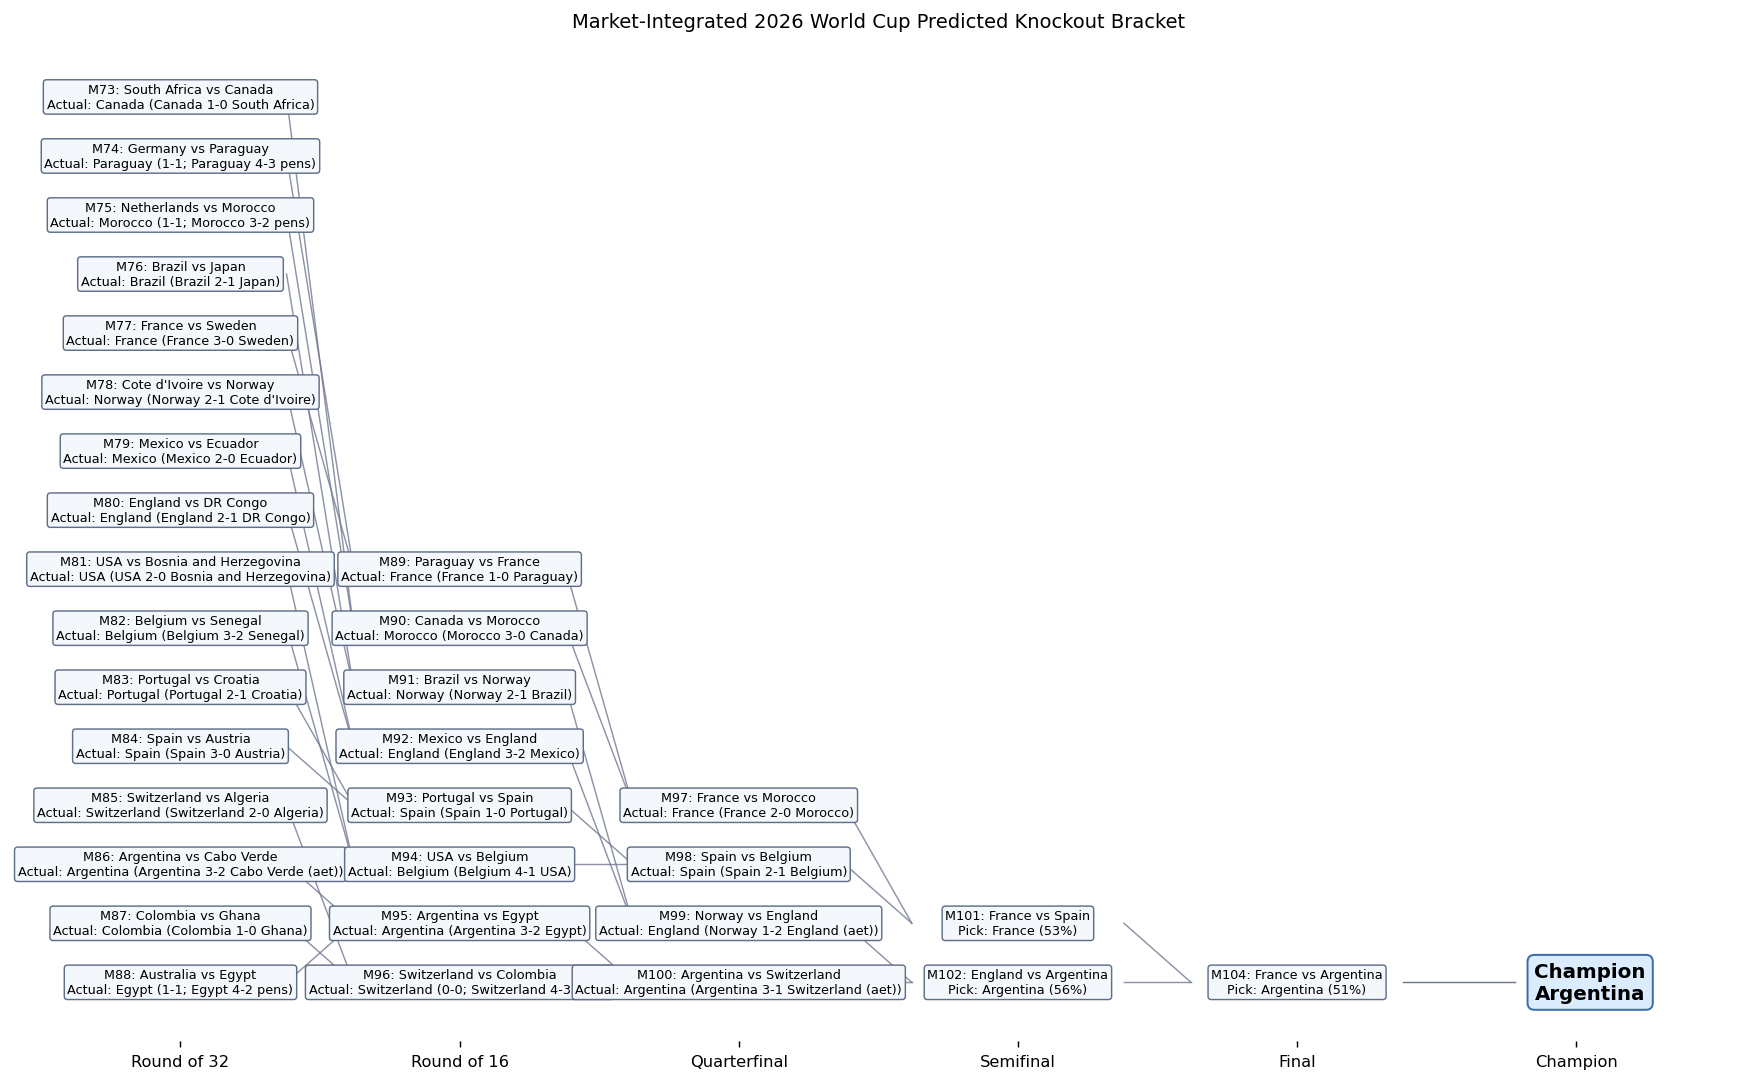

Knockout differences caused by group-stage market priors:


,round,match,slot,team_a_no_market,team_b_no_market,winner_no_market,team_a_market,team_b_market,winner_market,winner_probability_delta_pp,matchup_changed,winner_changed


In [23]:
# Market-prior snapshot and diagnostics.
print("Market-prior weight:", market_weight_default)
print("Market fetch summary:")
display(market_fetch_summary)

print("Current normalized prediction-market snapshot:")
display(market_snapshot[[
    "source", "market_type", "matchup", "team", "probability",
    "normalized_probability", "yes_bid", "yes_ask", "volume",
    "is_complete_distribution",
]].sort_values(["market_type", "matchup", "source", "team"]).round(4))

print("Cross-venue outright survivor priors applied to live ratings:")
display(outright_market_priors.round(4))

print("Cross-venue semifinal advance priors:")
display(semifinal_market_priors.round(4))

print("Rating deltas from current outright markets:")
display(
    teams_live_adjusted[
        teams_live_adjusted["team"].isin(current_knockout_survivors)
    ][[
        "team", "pre_market_updated_rating", "market_title_prob",
        "market_normalized_survivor_prob", "outright_market_rating_delta",
        "updated_rating"
    ]].sort_values("market_normalized_survivor_prob", ascending=False).round(4)
)

print("Outcome coverage by fetched match:")
display(market_group_prior_coverage.sort_values(
    ["is_forecast_applied", "is_full_distribution", "match_key"],
    ascending=[False, False, True],
))

market_display_columns = [
    "team_a", "team_b", "market_outcome", "market_prob", "market_weight", "source", "ticker", "quality_note"
]
if market_group_priors.empty:
    applied_market_matches = pd.DataFrame(columns=market_display_columns + ["match_key"])
else:
    applied_market_matches = (
        market_group_priors
        .assign(match_key=lambda d: d.apply(lambda r: " vs ".join(sorted([r["team_a"], r["team_b"]])), axis=1))
        .sort_values(["team_a", "team_b", "market_outcome"])
    )
print("Market rows actually applied to remaining group-stage forecasts:")
display(applied_market_matches[market_display_columns].round(3))

print("Market rows excluded from forecasts:")
display(market_group_priors_excluded[[
    "team_a", "team_b", "market_outcome", "market_prob", "source", "ticker", "exclusion_reason"
]].sort_values(["team_a", "team_b", "market_outcome"]).round(3))

market_standing_effect = (
    live_standings_no_market[[
        "group", "team", "projected_group_position", "projected_total_pts",
        "projected_total_gd", "updated_rating"
    ]]
    .merge(
        live_standings[[
            "group", "team", "projected_group_position", "projected_total_pts",
            "projected_total_gd", "updated_rating"
        ]],
        on=["group", "team"],
        suffixes=("_no_market", "_market"),
    )
)
market_standing_effect["projected_pts_delta"] = (
    market_standing_effect["projected_total_pts_market"]
    - market_standing_effect["projected_total_pts_no_market"]
)
market_standing_effect["projected_gd_delta"] = (
    market_standing_effect["projected_total_gd_market"]
    - market_standing_effect["projected_total_gd_no_market"]
)
market_standing_effect["position_changed"] = (
    market_standing_effect["projected_group_position_market"]
    != market_standing_effect["projected_group_position_no_market"]
)

print("Market effect on projected group standings:")
display(
    market_standing_effect[
        (market_standing_effect["projected_pts_delta"].abs() > 0.001)
        | market_standing_effect["position_changed"]
    ][[
        "group", "team", "projected_group_position_no_market", "projected_group_position_market",
        "projected_total_pts_no_market", "projected_total_pts_market", "projected_pts_delta",
        "projected_total_gd_no_market", "projected_total_gd_market", "position_changed"
    ]].sort_values(["group", "projected_group_position_market"]).round(3)
)

def build_knockout_from_standings_snapshot(standings, scenario_label):
    winners = standings[standings["projected_group_position"] == 1].set_index("group")["team"].to_dict()
    runners_up = standings[standings["projected_group_position"] == 2].set_index("group")["team"].to_dict()
    best_thirds = (
        standings[standings["projected_group_position"] == 3]
        .sort_values(["projected_total_pts", "projected_total_gd", "updated_rating"], ascending=False)
        .head(8)
        .copy()
    )
    third_qualifiers = best_thirds.set_index("group")["team"].to_dict()
    third_groups = "".join(sorted(third_qualifiers))
    if third_groups not in third_mapping_lookup:
        warning = f"No embedded Annex C mapping for projected third-place set {third_groups}."
        return pd.DataFrame(), best_thirds, third_groups, warning
    third_map = third_mapping_lookup[third_groups]

    r32_pairs = OrderedDict([
        (73, (runners_up["A"], runners_up["B"], "2A vs 2B")),
        (74, (winners["E"], third_qualifiers[third_map["E"]], f"1E vs 3{third_map['E']}")),
        (75, (winners["F"], runners_up["C"], "1F vs 2C")),
        (76, (winners["C"], runners_up["F"], "1C vs 2F")),
        (77, (winners["I"], third_qualifiers[third_map["I"]], f"1I vs 3{third_map['I']}")),
        (78, (runners_up["E"], runners_up["I"], "2E vs 2I")),
        (79, (winners["A"], third_qualifiers[third_map["A"]], f"1A vs 3{third_map['A']}")),
        (80, (winners["L"], third_qualifiers[third_map["L"]], f"1L vs 3{third_map['L']}")),
        (81, (winners["D"], third_qualifiers[third_map["D"]], f"1D vs 3{third_map['D']}")),
        (82, (winners["G"], third_qualifiers[third_map["G"]], f"1G vs 3{third_map['G']}")),
        (83, (runners_up["K"], runners_up["L"], "2K vs 2L")),
        (84, (winners["H"], runners_up["J"], "1H vs 2J")),
        (85, (winners["B"], third_qualifiers[third_map["B"]], f"1B vs 3{third_map['B']}")),
        (86, (winners["J"], runners_up["H"], "1J vs 2H")),
        (87, (winners["K"], third_qualifiers[third_map["K"]], f"1K vs 3{third_map['K']}")),
        (88, (runners_up["D"], runners_up["G"], "2D vs 2G")),
    ])

    knockout = {}
    for match, (a, b, slot) in r32_pairs.items():
        knockout[match] = knockout_result_live(match, "Round of 32", a, b, slot)

    def W(match):
        return knockout[match]["winner"]

    for match, (a, b, slot) in OrderedDict([
        (89, (W(74), W(77), "W74 vs W77")),
        (90, (W(73), W(75), "W73 vs W75")),
        (91, (W(76), W(78), "W76 vs W78")),
        (92, (W(79), W(80), "W79 vs W80")),
        (93, (W(83), W(84), "W83 vs W84")),
        (94, (W(81), W(82), "W81 vs W82")),
        (95, (W(86), W(88), "W86 vs W88")),
        (96, (W(85), W(87), "W85 vs W87")),
    ]).items():
        knockout[match] = knockout_result_live(match, "Round of 16", a, b, slot)

    for match, (a, b, slot) in OrderedDict([
        (97, (W(89), W(90), "W89 vs W90")),
        (98, (W(93), W(94), "W93 vs W94")),
        (99, (W(91), W(92), "W91 vs W92")),
        (100, (W(95), W(96), "W95 vs W96")),
    ]).items():
        knockout[match] = knockout_result_live(match, "Quarterfinal", a, b, slot)

    for match, (a, b, slot) in OrderedDict([
        (101, (W(97), W(98), "W97 vs W98")),
        (102, (W(99), W(100), "W99 vs W100")),
    ]).items():
        knockout[match] = knockout_result_live(match, "Semifinal", a, b, slot)

    knockout[103] = knockout_result_live(
        103, "Third-place Match", knockout[101]["loser"], knockout[102]["loser"], "L101 vs L102"
    )
    knockout[104] = knockout_result_live(104, "Final", W(101), W(102), "W101 vs W102")

    table = (
        pd.DataFrame(knockout.values())
        .sort_values("match")
        .merge(knockout_schedule, on="match", how="left")
    )
    table.insert(0, "scenario", scenario_label)
    return table, best_thirds, third_groups, ""

market_ko_table, market_ko_thirds, market_ko_third_groups, market_ko_warning = build_knockout_from_standings_snapshot(
    live_standings,
    "Market-integrated group setup",
)
nomarket_ko_table, nomarket_ko_thirds, nomarket_ko_third_groups, nomarket_ko_warning = build_knockout_from_standings_snapshot(
    live_standings_no_market,
    "No-market group setup",
)

if market_ko_warning:
    print(market_ko_warning)
if nomarket_ko_warning:
    print(nomarket_ko_warning)

if not market_ko_table.empty and not nomarket_ko_table.empty:
    print(f"No-market third-place group set: {nomarket_ko_third_groups}")
    print(f"Market-integrated third-place group set: {market_ko_third_groups}")
    print(f"No-market champion: {nomarket_ko_table.loc[nomarket_ko_table['match'] == 104, 'winner'].iloc[0]}")
    print(f"Market-integrated champion: {market_ko_table.loc[market_ko_table['match'] == 104, 'winner'].iloc[0]}")

    market_ko_view = market_ko_table[[
        "round", "match", "date", "weekday", "local_kickoff", "location",
        "slot", "team_a", "team_b", "status", "result_note", "winner", "winner_probability"
    ]].copy()
    market_ko_view["winner_probability"] = (
        100 * market_ko_view["winner_probability"]
    ).round(1).astype(str) + "%"
    print("Market-integrated knockout rebuild from group-stage market priors:")
    display(market_ko_view)

    market_round_order = ["Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Final"]
    market_round_x = {name: i for i, name in enumerate(market_round_order)}
    market_y_positions = {}
    for round_name in market_round_order:
        matches = market_ko_table[market_ko_table["round"] == round_name]["match"].tolist()
        n = len(matches)
        for i, match in enumerate(matches):
            market_y_positions[match] = n - i

    market_parents = {
        89: [74, 77], 90: [73, 75], 91: [76, 78], 92: [79, 80],
        93: [83, 84], 94: [81, 82], 95: [86, 88], 96: [85, 87],
        97: [89, 90], 98: [93, 94], 99: [91, 92], 100: [95, 96],
        101: [97, 98], 102: [99, 100], 104: [101, 102],
    }

    market_ko_by_match = market_ko_table.set_index("match").to_dict("index")
    fig, ax = plt.subplots(figsize=(13.8, 8.4))
    for _, row in market_ko_table[market_ko_table["round"].isin(market_round_order)].iterrows():
        x = market_round_x[row["round"]]
        y = market_y_positions[row["match"]]
        if row.get("status", "projected") == "actual":
            label = f"M{int(row['match'])}: {row['team_a']} vs {row['team_b']}\nActual: {row['winner']} ({row['result_note']})"
        else:
            label = f"M{int(row['match'])}: {row['team_a']} vs {row['team_b']}\nPick: {row['winner']} ({row['winner_probability'] * 100:.0f}%)"
        ax.text(
            x, y, label, ha="center", va="center", fontsize=7.1,
            bbox=dict(boxstyle="round,pad=0.25", fc="#f4f7fb", ec="#5f6f89", lw=0.8),
        )

    for child, parent_matches in market_parents.items():
        if child not in market_y_positions:
            continue
        child_row = market_ko_by_match[child]
        child_x = market_round_x[child_row["round"]]
        child_y = market_y_positions[child]
        for parent in parent_matches:
            if parent not in market_y_positions:
                continue
            parent_row = market_ko_by_match[parent]
            parent_x = market_round_x[parent_row["round"]]
            parent_y = market_y_positions[parent]
            ax.plot([parent_x + 0.38, child_x - 0.38], [parent_y, child_y], color="#6f7890", lw=0.8, alpha=0.8)

    market_champion = market_ko_table.loc[market_ko_table["match"] == 104, "winner"].iloc[0]
    ax.text(
        5.05, market_y_positions[104], f"Champion\n{market_champion}",
        ha="center", va="center", fontsize=11, weight="bold",
        bbox=dict(boxstyle="round,pad=0.35", fc="#dcecff", ec="#3b6ea8", lw=1.1),
    )
    ax.plot([4.38, 4.78], [market_y_positions[104], market_y_positions[104]], color="#6f7890", lw=0.8)
    ax.set_xlim(-0.6, 5.6)
    ax.set_ylim(0, 17)
    ax.set_xticks(list(market_round_x.values()) + [5])
    ax.set_xticklabels(market_round_order + ["Champion"])
    ax.set_yticks([])
    ax.set_title("Market-Integrated 2026 World Cup Predicted Knockout Bracket")
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

    ko_comparison = nomarket_ko_table.merge(
        market_ko_table,
        on=["match", "round", "slot"],
        suffixes=("_no_market", "_market"),
    )
    ko_comparison["matchup_changed"] = (
        (ko_comparison["team_a_no_market"] != ko_comparison["team_a_market"])
        | (ko_comparison["team_b_no_market"] != ko_comparison["team_b_market"])
    )
    ko_comparison["winner_changed"] = ko_comparison["winner_no_market"] != ko_comparison["winner_market"]
    ko_comparison["winner_probability_delta_pp"] = 100 * (
        ko_comparison["winner_probability_market"] - ko_comparison["winner_probability_no_market"]
    )
    changed_ko = ko_comparison[
        ko_comparison["matchup_changed"]
        | ko_comparison["winner_changed"]
        | (ko_comparison["winner_probability_delta_pp"].abs() >= 0.1)
    ][[
        "round", "match", "slot", "team_a_no_market", "team_b_no_market",
        "winner_no_market", "team_a_market", "team_b_market", "winner_market",
        "winner_probability_delta_pp", "matchup_changed", "winner_changed"
    ]].copy()
    print("Knockout differences caused by group-stage market priors:")
    display(changed_ko.round(2))

def normalize_binary_market_prob(yes_bid=None, yes_ask=None, yes_last=None):
    """Return a conservative market-implied probability for a binary YES contract."""
    if yes_bid is not None and yes_ask is not None:
        spread = abs(float(yes_ask) - float(yes_bid))
        midpoint = (float(yes_bid) + float(yes_ask)) / 2
        return midpoint, spread
    if yes_last is not None:
        return float(yes_last), np.nan
    return np.nan, np.nan

def normalize_multi_outcome_prices(price_by_team):
    """Normalize mutually exclusive outcome prices so they sum to one."""
    s = pd.Series(price_by_team, dtype=float)
    total = s.sum()
    if total <= 0:
        return s * np.nan
    return s / total

## Ticket-Focused Match Recommendations

This section recommends matches to watch using the live-updated bracket projection and your stated priorities:

1. Argentina and Norway matches
2. France matches
3. Spain matches
4. All others

Ticket-price caveat: I checked public ticket-pricing reports, but I do **not** have reliable seat-map inventory exposed inside the notebook. FIFA is using variable/demand-based pricing, and public reporting says prices can move materially. For planning, I use a **good-seat target**: lower sideline / near-midfield / strong central view, generally aiming for **USD 3,000-8,000 per seat** where feasible.

Public ticket benchmarks used:

- FIFA/press reporting says tickets started at **$60** and top final tickets initially reached **$6,730**, with dynamic/variable pricing.
- Later reporting said final tickets rose to approximately **$10,990** for top tier, with Category 2 around **$7,380** and Category 3 around **$5,785**.
- FIFA's 2026 category structure reportedly maps lower levels generally to Category 1, suite levels to Category 2, and upper tiers to Categories 3/4. That means a “near-midfield lower bowl” seat may price above the preferred range for the final, while Category 2/3 may fit the range but may not be true lower-midfield.

Weather note: the remaining-match rows use public forecasts checked on **July 12**. Forecasts can still change, especially for thunderstorms; retractable-roof venues reduce the spectator risk substantially if the roof is closed.

In [24]:
recommendation_data = [
    # match, round, date, local_time, stadium, city, projected matchup, teams of interest, price range,
    # weather, recommendation reason
    (97, "Quarterfinal", "2026-07-09", "16:00", "Gillette Stadium", "Foxborough, MA",
     "France vs Morocco", "France",
     "$4,000-$7,000 target range for good seats",
     "Warm, humid New England summer; average July high near low 80s F; open-air stadium.",
     "France priority plus a strong Morocco test. Excellent sporting value before semifinal/final pricing becomes painful."),
    (98, "Quarterfinal", "2026-07-10", "12:00", "SoFi Stadium", "Inglewood, CA",
     "Spain vs Belgium", "Spain",
     "$4,500-$7,000 target range for good seats",
     "Mild/dry, likely comfortable; roof canopy helps. Noon start is less punishing than Texas/Miami.",
     "Best Spain-focused value: quarterfinal stakes, comfortable venue, and likely inside the preferred good-seat band."),
    (99, "Quarterfinal", "2026-07-11", "17:00", "Hard Rock Stadium", "Miami Gardens, FL",
     "Norway vs England", "Norway",
     "$4,000-$7,500 target range; Haaland/England demand can push central lower seats higher",
     "Hot, humid, thunderstorm/rainy-season risk; late afternoon kickoff helps only a little.",
     "Top Norway-priority match now: Haaland/Odegaard/Nusa transition threat against England's improved collaborative attack."),
    (100, "Quarterfinal", "2026-07-11", "20:00", "Arrowhead Stadium / Kansas City Stadium", "Kansas City, MO",
     "Argentina vs Switzerland", "Argentina",
     "$4,500-$7,500 target range for good sideline seats; premium midfield may exceed this",
     "Hot/humid summer evening, roughly low 80s F at kickoff with thunderstorm risk.",
     "Best upcoming Argentina value if they remain alive: quarterfinal stakes, weekend date, and still more reachable than semifinal/final."),
    (101, "Semifinal", "2026-07-14", "14:00", "AT&T Stadium / Dallas Stadium", "Arlington, TX",
     "France vs Spain", "France, Spain",
     "$6,000-$8,000 target range for good seats; premium lower-midfield may exceed budget",
     "July 12 forecast: roughly 86-90 F with a material thunderstorm chance outside; the enclosed, air-conditioned venue sharply reduces spectator risk.",
     "Elite semifinal quality and the clearest France/Spain priority matchup, with a climate-controlled venue."),
    (102, "Semifinal", "2026-07-15", "15:00", "Mercedes-Benz Stadium / Atlanta Stadium", "Atlanta, GA",
     "England vs Argentina", "Argentina",
     "$6,000-$8,000 target for good seats; true lower-midfield could exceed budget",
     "July 12 forecast: around 94 F with broken clouds and low rain risk outside; the retractable-roof venue is a major comfort advantage.",
     "Highest-priority remaining match: Argentina against an England side with Bellingham and Kane-level clutch threats."),
    (103, "Third-place Match", "2026-07-18", "17:00", "Hard Rock Stadium", "Miami Gardens, FL",
     "Semifinal losers", "Other",
     "$3,000-$6,000 target range; usually more attainable than the final",
     "Current extended forecast: mainly sunny and very hot, roughly upper 80s to mid-90s F; open-air heat remains the main concern.",
     "Often the best value for seeing two elite teams with less final-level price pressure, especially on a Saturday."),
    (104, "Final", "2026-07-19", "15:00", "MetLife Stadium / New York New Jersey Stadium", "East Rutherford, NJ",
     "Projected final", "Argentina, France",
     "$5,785-$7,380 public Cat. 3/Cat. 2 benchmark; true prime midfield reported near/above $10,990",
     "July 12 extended forecast: about 84/73 F, humid with a feels-like near 95 F and roughly 50% risk of late thunderstorms; open-air venue.",
     "The best football event if budget is flexible. Within $3k-$8k is plausible only away from the very best midfield/lower seats."),
]

recommendations = pd.DataFrame(
    recommendation_data,
    columns=[
        "match", "round", "date", "local_time", "stadium", "city", "possible_matchup",
        "priority_team", "good_seat_price_estimate_usd", "projected_weather", "reason",
    ],
)
recommendations = recommendations[recommendations["match"] >= 101].copy()

ko_matchup_map = {
    int(row["match"]): f"{row['team_a']} vs {row['team_b']}"
    for _, row in live_knockout_table.iterrows()
}
recommendations["possible_matchup"] = recommendations["match"].map(ko_matchup_map).fillna(recommendations["possible_matchup"])

def priority_from_matchup(matchup):
    has_argentina = "Argentina" in matchup
    has_norway = "Norway" in matchup
    has_france = "France" in matchup
    has_spain = "Spain" in matchup
    labels = []
    if has_argentina:
        labels.append("Argentina")
    if has_norway:
        labels.append("Norway")
    if not labels and has_france:
        labels.append("France")
    if not labels and has_spain:
        labels.append("Spain")
    if labels and has_france and "France" not in labels:
        labels.append("France")
    if labels and has_spain and "Spain" not in labels:
        labels.append("Spain")
    return ", ".join(labels) if labels else "Other"

recommendations["priority_team"] = recommendations["possible_matchup"].map(priority_from_matchup)

priority_scores = {"Argentina": 5, "Norway": 5, "Argentina, France": 5, "France": 4, "France, Spain": 4, "Spain": 3}
priority_scores.update({
    "Argentina, Spain": 5,
    "Argentina, Norway": 5,
    "Norway, France": 5,
    "Norway, Spain": 5,
    "Other": 1,
})
round_scores = {"Final": 5, "Semifinal": 4.5, "Quarterfinal": 4, "Third-place Match": 3.2, "Round of 16": 3, "Round of 32": 2}
matchup_scores = {
    97: 4.4, 98: 4.5, 99: 4.8, 100: 4.9,
    101: 4.9, 102: 5.0, 103: 3.8, 104: 5.0,
}
price_fit_scores = {
    97: 4.0, 98: 4.2, 99: 4.0, 100: 4.3,
    101: 3.7, 102: 3.9, 103: 4.4, 104: 2.8,
}
weather_scores = {
    97: 3.3, 98: 4.9, 99: 2.5, 100: 2.8,
    101: 4.1, 102: 4.3, 103: 2.6, 104: 2.7,
}

recommendations["weekday"] = pd.to_datetime(recommendations["date"]).dt.day_name()
weekday_scores = {
    "Saturday": 5.0,
    "Sunday": 5.0,
    "Friday": 4.0,
    "Thursday": 2.7,
    "Monday": 2.5,
    "Tuesday": 2.0,
    "Wednesday": 2.0,
}
recommendations["priority_score"] = recommendations["priority_team"].map(priority_scores)
recommendations["round_score"] = recommendations["round"].map(round_scores)
recommendations["matchup_score"] = recommendations["match"].map(matchup_scores)
recommendations["price_fit_score"] = recommendations["match"].map(price_fit_scores)
recommendations["weather_score"] = recommendations["match"].map(weather_scores)
recommendations["weekday_score"] = recommendations["weekday"].map(weekday_scores)
recommendations["recommendation_score"] = (
    # Updated preference hierarchy:
    # 1. Matchup quality / team interest, 2. price fit, 3. date/weather convenience.
    0.36 * recommendations["matchup_score"]
    + 0.24 * recommendations["price_fit_score"]
    + 0.18 * recommendations["priority_score"]
    + 0.08 * recommendations["round_score"]
    + 0.07 * recommendations["weather_score"]
    + 0.07 * recommendations["weekday_score"]
)

recommendations_ranked = recommendations.sort_values("recommendation_score", ascending=False).reset_index(drop=True)
recommendations_ranked["rank"] = recommendations_ranked.index + 1
display(recommendations_ranked[[
    "rank", "match", "round", "date", "weekday", "local_time", "city", "stadium",
    "possible_matchup", "priority_team", "good_seat_price_estimate_usd",
    "projected_weather", "reason", "matchup_score", "price_fit_score", "weekday_score", "weather_score", "recommendation_score",
]].round(2))

,rank,match,round,date,weekday,local_time,city,stadium,possible_matchup,priority_team,good_seat_price_estimate_usd,projected_weather,reason,matchup_score,price_fit_score,weekday_score,weather_score,recommendation_score
0,1,102,Semifinal,2026-07-15,Wednesday,15:00,"Atlanta, GA",Mercedes-Benz Stadium / Atlanta Stadium,England vs Argentina,Argentina,"$6,000-$8,000 target for good seats; true lower-midfield could exceed budget",July 12 forecast: around 94 F with broken clouds and low rain risk outside; the retractable-roof venue is a major comfort advantage.,Highest-priority remaining match: Argentina against an England side with Bellingham and Kane-level clutch threats.,5.0,3.9,2.0,4.3,4.44
1,2,104,Final,2026-07-19,Sunday,15:00,"East Rutherford, NJ",MetLife Stadium / New York New Jersey Stadium,France vs Argentina,"Argentina, France","$5,785-$7,380 public Cat. 3/Cat. 2 benchmark; true prime midfield reported near/above $10,990","July 12 extended forecast: about 84/73 F, humid with a feels-like near 95 F and roughly 50% risk of late thunderstorms; open-air venue.",The best football event if budget is flexible. Within $3k-$8k is plausible only away from the very best midfield/lower seats.,5.0,2.8,5.0,2.7,4.31
2,3,101,Semifinal,2026-07-14,Tuesday,14:00,"Arlington, TX",AT&T Stadium / Dallas Stadium,France vs Spain,"France, Spain","$6,000-$8,000 target range for good seats; premium lower-midfield may exceed budget","July 12 forecast: roughly 86-90 F with a material thunderstorm chance outside; the enclosed, air-conditioned venue sharply reduces spect...","Elite semifinal quality and the clearest France/Spain priority matchup, with a climate-controlled venue.",4.9,3.7,2.0,4.1,4.16
3,4,103,Third-place Match,2026-07-18,Saturday,17:00,"Miami Gardens, FL",Hard Rock Stadium,Spain vs England,Spain,"$3,000-$6,000 target range; usually more attainable than the final","Current extended forecast: mainly sunny and very hot, roughly upper 80s to mid-90s F; open-air heat remains the main concern.","Often the best value for seeing two elite teams with less final-level price pressure, especially on a Saturday.",3.8,4.4,5.0,2.6,3.75


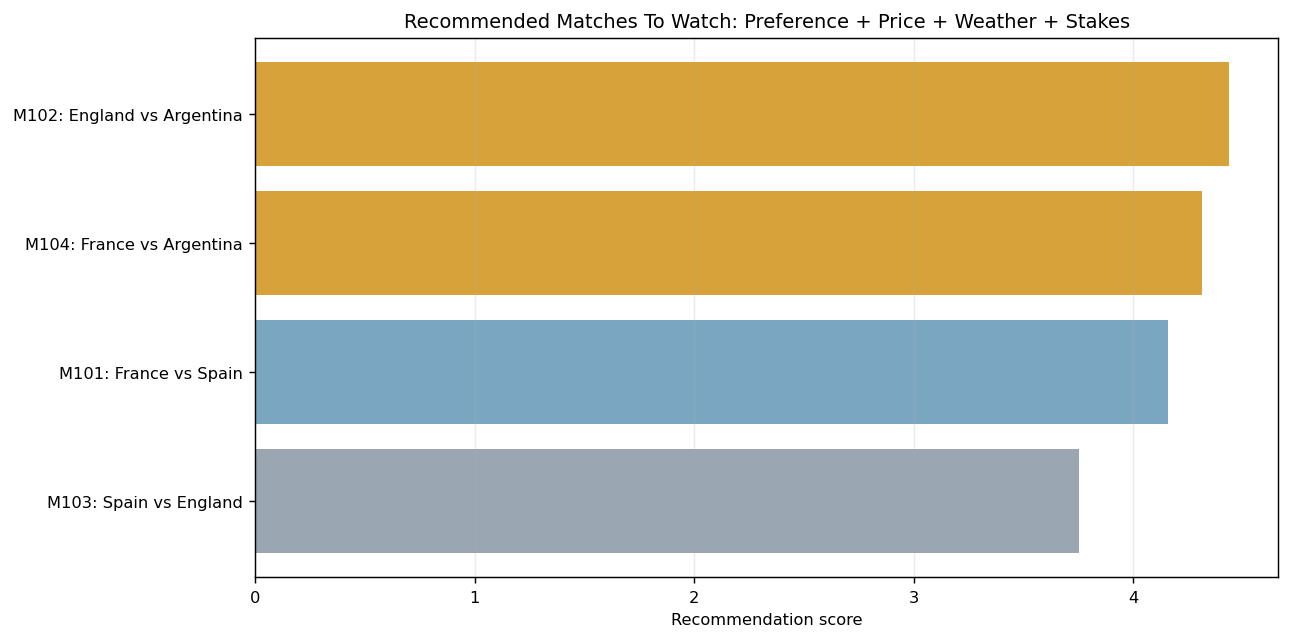

Top 5 practical recommendation order:
1. Match 102 (Semifinal, Wednesday): England vs Argentina — Atlanta, GA — $6,000-$8,000 target for good seats; true lower-midfield could exceed budget
2. Match 104 (Final, Sunday): France vs Argentina — East Rutherford, NJ — $5,785-$7,380 public Cat. 3/Cat. 2 benchmark; true prime midfield reported near/above $10,990
3. Match 101 (Semifinal, Tuesday): France vs Spain — Arlington, TX — $6,000-$8,000 target range for good seats; premium lower-midfield may exceed budget
4. Match 103 (Third-place Match, Saturday): Spain vs England — Miami Gardens, FL — $3,000-$6,000 target range; usually more attainable than the final


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = recommendations_ranked.sort_values("recommendation_score")
labels = [f"M{m}: {mu}" for m, mu in zip(plot_df["match"], plot_df["possible_matchup"])]
colors = [
    "#d8a23a" if "Argentina" in team or "Norway" in team else "#7aa6c2" if "France" in team else "#9aa6b2"
    for team in plot_df["priority_team"]
]
ax.barh(labels, plot_df["recommendation_score"], color=colors)
ax.set_xlabel("Recommendation score")
ax.set_title("Recommended Matches To Watch: Preference + Price + Weather + Stakes")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("Top 5 practical recommendation order:")
for _, row in recommendations_ranked.head(5).iterrows():
    print(f"{int(row['rank'])}. Match {int(row['match'])} ({row['round']}, {row['weekday']}): {row['possible_matchup']} — {row['city']} — {row['good_seat_price_estimate_usd']}")

<!-- LIVE_UPDATE_20260617_END -->